# 06. Klasyczny EDA do pracy magisterskiej

**Cel.** Klasyczna, opisowa analiza eksploracyjna zamrożonej próby supervised ML: charakterystyka próby, jakość danych, rozkłady 17 cech, braki danych, współliniowość, stabilność w czasie oraz obserwacje skrajne.

**Twarda granica temporalna.** Notebook korzysta wyłącznie z train/development z lat **2011–2020**. Nie wczytuje, nie podsumowuje, nie wizualizuje ani nie wykorzystuje wartości z lat 2021–2024. Każdy wejściowy DataFrame przechodzi kontrolę `max(feature_year) <= 2020`; naruszenie natychmiast przerywa wykonanie.

**Aktualny stan metodologii.** Źródłem prawdy jest overlay `supervised_ml_pipeline v1.3.0`, skorygowany raw `X_t v1.1.0` i target-application `v1.2.0`. Zestaw 17 cech oraz polityka głównej próby są zamrożone.

**Charakter analizy.** EDA odpowiada na pytanie „jak wyglądają dane?”. Nie służy do selekcji ani eliminacji cech, strojenia preprocessingu, poprawiania wyniku modelu ani formułowania wniosków przyczynowych. Statystyki podstawowe są liczone na surowych wartościach — bez winsoryzacji, imputacji i skalowania. Jedyny wyjątek stanowi jawnie oznaczona techniczna imputacja medianą na potrzeby diagnostyki VIF; nie modyfikuje ona pipeline'u.

**Reprodukowalność.** Notebook używa ścieżek względnych, istniejących definicji bloków cech z `src.modeling.preprocessing`, weryfikuje hashe wejść i nie modyfikuje plików źródłowych. Tabele i wykresy zapisuje w `reports/classical_eda_for_thesis/`.


In [1]:
from __future__ import annotations

from pathlib import Path
import csv
import hashlib
import json
import math
import re
import sys
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import rankdata
import yaml
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

YEAR_MIN = 2011
YEAR_MAX = 2020
RANDOM_SEED = 20260818
SAVE_OUTPUTS = True
SHOW_FIGURES = True
FIGURE_DPI = 300


def project_root(start: Path | None = None) -> Path:
    """Locate the repository without using an absolute local path."""
    start = (start or Path.cwd()).resolve()
    marker = Path("configs/supervised_ml_pipeline_v1_3_0_timezone_fix.yaml")
    for candidate in (start, *start.parents):
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(
        "Nie znaleziono katalogu głównego repozytorium. Uruchom notebook z repo "
        "qnn-financial-statement-analysis lub jego podkatalogu."
    )


ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling.preprocessing import (  # noqa: E402
    FEATURE_BLOCKS,
    PreprocessingPolicy,
    features_for_blocks,
)

FEATURES = list(features_for_blocks(("L", "D", "R")))
VALUE_COLUMNS = [f"{feature}_value" for feature in FEATURES]
FEATURE_TO_BLOCK = {
    feature: block
    for block, block_features in FEATURE_BLOCKS.items()
    for feature in block_features
}

if len(FEATURES) != 17 or len(set(FEATURES)) != 17:
    raise RuntimeError(f"Oczekiwano dokładnie 17 unikalnych cech, otrzymano: {FEATURES!r}")

OUTPUT_ROOT = ROOT / "reports/classical_eda_for_thesis"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
if SAVE_OUTPUTS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "savefig.dpi": FIGURE_DPI,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)


def slugify(value: str) -> str:
    normalized = re.sub(r"[^a-zA-Z0-9._-]+", "_", value.strip())
    return normalized.strip("_").lower()


def save_table(frame: pd.DataFrame | pd.Series, filename: str, *, index: bool = True) -> Path | None:
    """Save an analysis table without rounding the underlying values."""
    if not SAVE_OUTPUTS:
        return None
    path = TABLE_DIR / filename
    if isinstance(frame, pd.Series):
        frame.to_frame().to_csv(path, index=index)
    else:
        frame.to_csv(path, index=index)
    return path


def finalize_figure(fig: plt.Figure, filename: str) -> Path | None:
    """Apply a consistent layout, save at thesis quality and optionally display."""
    fig.tight_layout()
    path = None
    if SAVE_OUTPUTS:
        path = FIGURE_DIR / filename
        fig.savefig(path, bbox_inches="tight", dpi=FIGURE_DPI)
    if SHOW_FIGURES:
        plt.show()
    plt.close(fig)
    return path


def show_table(title: str, frame: pd.DataFrame | pd.Series, digits: int = 4) -> None:
    display(Markdown(f"#### {title}"))
    if isinstance(frame, pd.Series):
        display(frame.to_frame().round(digits))
    else:
        display(frame.round(digits))


print(f"Repozytorium: {ROOT}")
print(f"Zamrożone cechy ({len(FEATURES)}): {FEATURES}")
print(f"Katalog wyników: {OUTPUT_ROOT.relative_to(ROOT)}")


Repozytorium: /Users/oskarstachowski/qnn-financial-statement-analysis
Zamrożone cechy (17): ['log_assets_t', 'roa_t', 'ocf_to_assets_t', 'current_ratio_t', 'liabilities_to_assets_t', 'working_capital_to_assets_t', 'accruals_to_assets_t', 'asset_growth_1y', 'delta_roa_1y', 'delta_ocf_to_assets_1y', 'current_ratio_change_1y', 'delta_liabilities_to_assets_1y', 'log1p_revenues_t', 'profit_margin_t', 'ocf_margin_t', 'asset_turnover_t', 'revenue_growth_1y']
Katalog wyników: reports/classical_eda_for_thesis


## Wejścia i kontrola granicy temporalnej

Ta sekcja ładuje wyłącznie aktualne artefakty train-only wskazane przez overlay `v1.3.0`. Nie istnieje fallback do wcześniejszych artefaktów, katalogu `LEGACY` ani danych z późniejszych okresów. Przed jakąkolwiek analizą wykonywane są: kontrola obecności plików, kontrola hashy, kontrola schematu, kontrola jednoznaczności klucza i twarda kontrola lat.


In [2]:
def read_yaml(path: Path) -> dict:
    return yaml.safe_load(path.read_text(encoding="utf-8"))


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def csv_header(path: Path) -> list[str]:
    with path.open("r", encoding="utf-8", newline="") as stream:
        return next(csv.reader(stream))


def fingerprint_csv(path: Path) -> dict:
    """Streaming SHA-256, row count, column count and file size."""
    digest = hashlib.sha256()
    line_count = 0
    byte_count = 0
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
            byte_count += len(chunk)
            line_count += chunk.count(b"\n")
    return {
        "sha256": digest.hexdigest(),
        "rows": max(line_count - 1, 0),
        "columns": len(csv_header(path)),
        "MiB": byte_count / 1024**2,
    }


def membership_sha256(values: pd.Series) -> str:
    """Repository-standard fingerprint: sorted IDs, UTF-8, one LF per ID."""
    normalized = values.astype("string")
    if normalized.isna().any() or normalized.duplicated().any():
        raise RuntimeError("Membership fingerprint wymaga kompletnych i unikalnych ID.")
    payload = "".join(f"{value}\n" for value in sorted(normalized.astype(str)))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def assert_required_columns(path: Path, required: list[str]) -> list[str]:
    header = csv_header(path)
    missing = [column for column in required if column not in header]
    if missing:
        raise KeyError(f"Plik {path.relative_to(ROOT)} nie zawiera wymaganych kolumn: {missing}")
    return header


def assert_year_scope(frame: pd.DataFrame, name: str) -> pd.Series:
    """Fail closed before any descriptive operation can use a later year."""
    if "feature_year" not in frame:
        raise KeyError(f"{name}: brak kolumny feature_year.")
    years = pd.to_numeric(frame["feature_year"], errors="raise")
    if years.isna().any():
        raise RuntimeError(f"{name}: feature_year zawiera NaN.")
    min_year = int(years.min())
    max_year = int(years.max())
    if min_year < YEAR_MIN or max_year > YEAR_MAX:
        raise RuntimeError(
            f"PRZERWANO: {name} zawiera lata {min_year}–{max_year}; "
            f"dozwolony zakres EDA to wyłącznie {YEAR_MIN}–{YEAR_MAX}."
        )
    # Jawna kontrola wymagana przez specyfikację EDA.
    assert int(years.max()) <= 2020
    return years.astype(int)


BASE_CONFIG_PATH = ROOT / "configs/supervised_ml_pipeline_v1.yaml"
CURRENT_CONFIG_PATH = ROOT / "configs/supervised_ml_pipeline_v1_3_0_timezone_fix.yaml"
X_MANIFEST_PATH = ROOT / "data/reports/x_t_pit_v1_1_0_train_build_manifest.json"
TIMEZONE_REPORT_PATH = ROOT / "data/reports/timezone_pit_fix_v1_0_0.json"

for required_path in (BASE_CONFIG_PATH, CURRENT_CONFIG_PATH, X_MANIFEST_PATH, TIMEZONE_REPORT_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(f"Brak wymaganego pliku repozytorium: {required_path}")

base_config = read_yaml(BASE_CONFIG_PATH)
current_config = read_yaml(CURRENT_CONFIG_PATH)
x_manifest = read_json(X_MANIFEST_PATH)
timezone_report = read_json(TIMEZONE_REPORT_PATH)

config_features = [
    feature
    for block in ("L", "D", "R")
    for feature in base_config["feature_blocks"][block]
]
if config_features != FEATURES:
    raise RuntimeError("Definicja 17 cech w configu i src.modeling.preprocessing nie jest zgodna.")

current_upstream = current_config["upstream_inputs"]
PATHS = {
    "x_t": ROOT / current_upstream["raw_x_t"]["artifact"],
    "target_application": ROOT / current_upstream["target"]["artifact"],
}
EXPECTED = {
    "x_t": {
        "sha256": current_upstream["raw_x_t"]["sha256"],
        "rows": int(x_manifest["raw_train_artifact_rows"]),
        "columns": int(x_manifest["raw_train_artifact_columns"]),
    },
    "target_application": {
        "sha256": current_upstream["target"]["sha256"],
        "rows": int(timezone_report["artifacts"]["target_application_train"]["rows"]),
        "columns": None,  # Exact SHA-256 freezes the full schema and content.
    },
}

for name, path in PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(
            f"Brak aktualnego artefaktu {name}: {path.relative_to(ROOT)}. "
            "Notebook celowo nie przechodzi na starszy plik ani dane zastępcze."
        )

fingerprints = {name: fingerprint_csv(path) for name, path in PATHS.items()}
for name, actual in fingerprints.items():
    expected = EXPECTED[name]
    if actual["sha256"] != expected["sha256"]:
        raise RuntimeError(f"Niezgodny SHA-256 dla {name}: {actual['sha256']}")
    if actual["rows"] != expected["rows"]:
        raise RuntimeError(
            f"Niezgodna liczba wierszy dla {name}: {actual['rows']} != {expected['rows']}"
        )
    if expected["columns"] is not None and actual["columns"] != expected["columns"]:
        raise RuntimeError(
            f"Niezgodna liczba kolumn dla {name}: "
            f"{actual['columns']} != {expected['columns']}"
        )

X_REQUIRED = [
    "research_universe_company_year_id",
    "cik10",
    "feature_year",
    "split",
    "membership_status",
    "x_t_status",
    "x_t_status_reason",
    "research_sector",
    "historical_sic",
    "economic_group_id",
    "registrant_role_resolved",
    "xbrl_submission_available",
    "statement_scope_xbrl_available",
    "statement_scope_xbrl_status",
    "current_t_assets_value",
] + VALUE_COLUMNS
X_OPTIONAL = [
    "feature_available_count",
    "L_available_count",
    "D_available_count",
    "R_available_count",
]
TARGET_REQUIRED = [
    "research_universe_company_year_id",
    "feature_year",
    "split",
    "membership_status",
    "target_status",
    "target_candidate_v2_pit_b",
    "target_available",
    "target_application_reason",
]

x_header = assert_required_columns(PATHS["x_t"], X_REQUIRED)
target_header = assert_required_columns(PATHS["target_application"], TARGET_REQUIRED)
x_columns = X_REQUIRED + [column for column in X_OPTIONAL if column in x_header]

x_frame = pd.read_csv(
    PATHS["x_t"],
    usecols=x_columns,
    dtype={
        "research_universe_company_year_id": "string",
        "cik10": "string",
    },
    low_memory=False,
)
target_frame = pd.read_csv(
    PATHS["target_application"],
    usecols=TARGET_REQUIRED,
    dtype={"research_universe_company_year_id": "string"},
    low_memory=False,
)

x_frame["feature_year"] = assert_year_scope(x_frame, "raw X_t v1.1.0 train")
target_frame["feature_year"] = assert_year_scope(
    target_frame, "target-application v1.2.0 train"
)

if x_frame["research_universe_company_year_id"].duplicated().any():
    raise RuntimeError("Raw X_t ma zduplikowany klucz research_universe_company_year_id.")
if target_frame["research_universe_company_year_id"].duplicated().any():
    raise RuntimeError("Target-application ma zduplikowany klucz research_universe_company_year_id.")

for column in VALUE_COLUMNS + ["current_t_assets_value"]:
    x_frame[column] = pd.to_numeric(x_frame[column], errors="raise")
target_frame["target_candidate_v2_pit_b"] = pd.to_numeric(
    target_frame["target_candidate_v2_pit_b"], errors="raise"
)

target_for_merge = target_frame.rename(
    columns={
        "feature_year": "target_feature_year",
        "split": "target_split",
        "membership_status": "target_membership_status",
        "target_available": "target_available_flag",
    }
)
merged_train = x_frame.merge(
    target_for_merge,
    on="research_universe_company_year_id",
    how="left",
    validate="one_to_one",
)

if merged_train["target_feature_year"].isna().any():
    raise RuntimeError("Nie każdy wiersz X_t ma odpowiadający wiersz target-application.")
if not merged_train["feature_year"].eq(merged_train["target_feature_year"]).all():
    raise RuntimeError("Niezgodność feature_year pomiędzy X_t i target-application.")
if not merged_train["split"].eq(merged_train["target_split"]).all():
    raise RuntimeError("Niezgodność split pomiędzy X_t i target-application.")
if not merged_train["membership_status"].eq(
    merged_train["target_membership_status"]
).all():
    raise RuntimeError("Niezgodność membership_status pomiędzy wejściami.")

sample_policy = base_config["supervised_sample"]
allowed_x_statuses = set(sample_policy["allowed_x_t_statuses"])
expected_n = int(current_config["supervised_sample"]["train_n"])
expected_positive_n = int(current_config["supervised_sample"]["class_balance"]["positive_n"])
expected_negative_n = int(current_config["supervised_sample"]["class_balance"]["negative_n"])
expected_membership_hash = current_config["supervised_sample"]["membership_sha256"]

merged_train["gate_train_membership"] = (
    merged_train["split"].eq("train")
    & merged_train["membership_status"].eq(sample_policy["required_membership_status"])
)
merged_train["gate_target_available"] = merged_train["target_status"].eq(
    sample_policy["required_target_status"]
)
merged_train["gate_x_status"] = merged_train["x_t_status"].isin(allowed_x_statuses)
merged_train["main_selected"] = (
    merged_train["gate_train_membership"]
    & merged_train["gate_target_available"]
    & merged_train["gate_x_status"]
)

stage_masks = [
    ("Aktualny raw X_t train-only", pd.Series(True, index=merged_train.index)),
    ("Po wymogu split=train i membership=eligible", merged_train["gate_train_membership"]),
    (
        "Po wymogu dostępnego targetu",
        merged_train["gate_train_membership"] & merged_train["gate_target_available"],
    ),
    (
        "Po wymogu zaakceptowanego X_t status",
        merged_train["gate_train_membership"]
        & merged_train["gate_target_available"]
        & merged_train["gate_x_status"],
    ),
]
selection_rows = []
previous_n = None
for stage, mask in stage_masks:
    n = int(mask.sum())
    selection_rows.append(
        {
            "etap": stage,
            "n": n,
            "pominiete_wobec_poprzedniego_etapu": 0 if previous_n is None else previous_n - n,
            "udzial_w_raw_pct": 100.0 * n / len(merged_train),
        }
    )
    previous_n = n
selection_flow = pd.DataFrame(selection_rows).set_index("etap")

analysis_frame = merged_train.loc[merged_train["main_selected"]].copy()
analysis_frame = analysis_frame.rename(
    columns={
        **{f"{feature}_value": feature for feature in FEATURES},
        "target_candidate_v2_pit_b": "target",
    }
)
analysis_frame["target"] = pd.to_numeric(analysis_frame["target"], errors="raise").astype(int)
analysis_frame["company_id"] = (
    analysis_frame["cik10"].astype("string").str.replace(r"\.0$", "", regex=True).str.zfill(10)
)
analysis_frame["xbrl_status"] = (
    analysis_frame["statement_scope_xbrl_status"].astype("string").fillna("brak_statusu")
)


def normalize_boolean_status(value: object) -> str:
    if pd.isna(value):
        return "brak_statusu"
    normalized = str(value).strip().lower()
    if normalized in {"true", "1", "1.0", "yes", "y"}:
        return "dostępny"
    if normalized in {"false", "0", "0.0", "no", "n"}:
        return "niedostępny"
    return str(value)


analysis_frame["xbrl_availability"] = analysis_frame[
    "statement_scope_xbrl_available"
].map(normalize_boolean_status)


def assign_yearly_size_quartile(frame: pd.DataFrame) -> pd.Series:
    label_missing = "Brak lub niedodatnie aktywa"
    result = pd.Series(label_missing, index=frame.index, dtype="string")
    assets = pd.to_numeric(frame["current_t_assets_value"], errors="raise")
    finite_positive = pd.Series(
        np.isfinite(assets.to_numpy(dtype=float)) & assets.gt(0).to_numpy(),
        index=frame.index,
    )
    for _, indexes in frame.groupby("feature_year", sort=True).groups.items():
        valid_indexes = [index for index in indexes if finite_positive.loc[index]]
        if not valid_indexes:
            continue
        ranks = assets.loc[valid_indexes].rank(method="average", pct=True)
        quartiles = pd.cut(
            ranks,
            bins=[0.0, 0.25, 0.50, 0.75, 1.0],
            labels=["Q1 – najmniejsze", "Q2", "Q3", "Q4 – największe"],
            include_lowest=True,
        )
        result.loc[valid_indexes] = quartiles.astype("string")
    return result


analysis_frame["size_quartile"] = assign_yearly_size_quartile(analysis_frame)
analysis_frame["available_feature_count_eda"] = analysis_frame[FEATURES].notna().sum(axis=1)
analysis_frame["finite_feature_count_eda"] = np.isfinite(
    analysis_frame[FEATURES].to_numpy(dtype=float)
).sum(axis=1)
analysis_frame = analysis_frame.sort_values(
    ["feature_year", "company_id", "research_universe_company_year_id"]
).reset_index(drop=True)

if len(analysis_frame) != expected_n:
    raise RuntimeError(f"Niezgodny N próby: {len(analysis_frame)} != {expected_n}")
if int(analysis_frame["target"].sum()) != expected_positive_n:
    raise RuntimeError("Niezgodna liczba obserwacji target=1.")
if int(analysis_frame["target"].eq(0).sum()) != expected_negative_n:
    raise RuntimeError("Niezgodna liczba obserwacji target=0.")
if not analysis_frame["target"].isin([0, 1]).all():
    raise RuntimeError("Target przyjmuje wartości inne niż 0/1.")
actual_membership_hash = membership_sha256(
    analysis_frame["research_universe_company_year_id"]
)
if actual_membership_hash != expected_membership_hash:
    raise RuntimeError(
        f"Niezgodny fingerprint membership: {actual_membership_hash} != {expected_membership_hash}"
    )
if int(analysis_frame["feature_year"].max()) > YEAR_MAX:
    raise RuntimeError("PRZERWANO: finalny DataFrame zawiera rok 2021 lub późniejszy.")
assert int(analysis_frame["feature_year"].max()) <= 2020

input_integrity = pd.DataFrame(
    [
        {
            "artefakt": name,
            "sciezka": str(PATHS[name].relative_to(ROOT)),
            "wiersze": actual["rows"],
            "kolumny": actual["columns"],
            "MiB": actual["MiB"],
            "sha256_ok": actual["sha256"] == EXPECTED[name]["sha256"],
            "rows_ok": actual["rows"] == EXPECTED[name]["rows"],
            "columns_ok": (
                True
                if EXPECTED[name]["columns"] is None
                else actual["columns"] == EXPECTED[name]["columns"]
            ),
        }
        for name, actual in fingerprints.items()
    ]
).set_index("artefakt")

scope_control = pd.DataFrame(
    {
        "wartosc": [
            int(analysis_frame["feature_year"].min()),
            int(analysis_frame["feature_year"].max()),
            len(analysis_frame),
            analysis_frame["research_universe_company_year_id"].nunique(),
            actual_membership_hash,
        ]
    },
    index=[
        "min(feature_year)",
        "max(feature_year)",
        "N finalnej próby",
        "unikalne klucze company-year",
        "membership SHA-256",
    ],
)

save_table(input_integrity, "00_input_integrity.csv")
save_table(selection_flow, "01_selection_flow.csv")
save_table(scope_control, "02_scope_control.csv")

show_table("Integralność aktualnych wejść", input_integrity)
show_table("Jawny przepływ do zamrożonej próby supervised", selection_flow)
show_table("Kontrola zakresu i membership", scope_control)
print(
    f"ZAKRES POTWIERDZONY: N={len(analysis_frame):,}, "
    f"lata={analysis_frame['feature_year'].min()}–{analysis_frame['feature_year'].max()}, "
    f"target=1: {analysis_frame['target'].sum():,}, target=0: "
    f"{analysis_frame['target'].eq(0).sum():,}."
)


#### Integralność aktualnych wejść

,sciezka,wiersze,kolumny,MiB,sha256_ok,rows_ok,columns_ok
artefakt,,,,,,,
x_t,data/processed/x_t_pit_v1_1_0_train.csv,47938,1072,565.9398,True,True,True
target_application,data/processed/research_universe_pit_v1_1_0_target_pit_b_v1_2_0_train.csv,47938,833,269.9807,True,True,True


#### Jawny przepływ do zamrożonej próby supervised

,n,pominiete_wobec_poprzedniego_etapu,udzial_w_raw_pct
etap,,,
Aktualny raw X_t train-only,47938,0,100.0000
Po wymogu split=train i membership=eligible,47938,0,100.0000
Po wymogu dostępnego targetu,19784,28154,41.2700
Po wymogu zaakceptowanego X_t status,19671,113,41.0343


#### Kontrola zakresu i membership

,wartosc
min(feature_year),2011
max(feature_year),2020
N finalnej próby,19671
unikalne klucze company-year,19671
membership SHA-256,864af3d9aac6ea239d993ea48cd819c2185f3249957d8b81f6d8d4c3c9f3d680


ZAKRES POTWIERDZONY: N=19,671, lata=2011–2020, target=1: 3,623, target=0: 16,048.


## 3.0. Kontrola jakości i integralności danych

Kontrole poniżej nie usuwają rekordów. Statystyki dla cech wykorzystują wszystkie obserwacje finalnej, zamrożonej próby. Wartości `NaN`, `+inf` i `-inf` są raportowane osobno; w obliczeniach, których matematycznie nie da się wykonać na wartościach nieskończonych, liczba pominiętych obserwacji jest jawna.


In [3]:
canonical_duplicate_mask = analysis_frame[
    "research_universe_company_year_id"
].duplicated(keep=False)
cik_year_duplicate_mask = analysis_frame.duplicated(
    subset=["company_id", "feature_year"], keep=False
)

feature_array = analysis_frame[FEATURES].to_numpy(dtype=float)
feature_quality_rows = []
for feature in FEATURES:
    series = pd.to_numeric(analysis_frame[feature], errors="raise")
    values = series.to_numpy(dtype=float)
    feature_quality_rows.append(
        {
            "blok": FEATURE_TO_BLOCK[feature],
            "cecha": feature,
            "dtype": str(series.dtype),
            "n_obserwacji": len(series),
            "n_dostepnych_non_na": int(series.notna().sum()),
            "n_nan": int(series.isna().sum()),
            "missingness_pct": 100.0 * series.isna().mean(),
            "n_finite": int(np.isfinite(values).sum()),
            "n_pos_inf": int(np.isposinf(values).sum()),
            "n_neg_inf": int(np.isneginf(values).sum()),
            "n_zer": int(np.equal(values, 0.0).sum()),
            "n_ujemnych": int(np.less(values, 0.0).sum()),
        }
    )
feature_quality = pd.DataFrame(feature_quality_rows).set_index("cecha")

sanity_overview = pd.DataFrame(
    {
        "wartosc": [
            len(analysis_frame),
            analysis_frame.shape[1],
            int(analysis_frame["feature_year"].min()),
            int(analysis_frame["feature_year"].max()),
            len(FEATURES),
            analysis_frame["company_id"].nunique(),
            analysis_frame["economic_group_id"].nunique(dropna=True),
            int(canonical_duplicate_mask.sum()),
            int(cik_year_duplicate_mask.sum()),
            sorted(analysis_frame["target"].unique().tolist()),
            int(analysis_frame["target"].isna().sum()),
            int(analysis_frame.isna().sum().sum()),
            int(analysis_frame[FEATURES].isna().sum().sum()),
            int(np.isposinf(feature_array).sum()),
            int(np.isneginf(feature_array).sum()),
        ]
    },
    index=[
        "liczba obserwacji",
        "liczba kolumn finalnego DataFrame",
        "minimalny rok",
        "maksymalny rok",
        "liczba zamrożonych cech",
        "liczba unikalnych CIK",
        "liczba unikalnych economic_group_id",
        "wiersze ze zduplikowanym kluczem kanonicznym",
        "wiersze ze zduplikowanym kluczem CIK × year",
        "unikalne wartości targetu",
        "NaN w target",
        "NaN w całym finalnym DataFrame",
        "NaN w 17 cechach",
        "+inf w 17 cechach",
        "-inf w 17 cechach",
    ],
)

columns_for_types = [
    "research_universe_company_year_id",
    "company_id",
    "feature_year",
    "target",
    "research_sector",
    "x_t_status",
    "xbrl_status",
    "current_t_assets_value",
] + FEATURES
dtype_table = pd.DataFrame(
    {"kolumna": columns_for_types, "dtype": [str(analysis_frame[c].dtype) for c in columns_for_types]}
).set_index("kolumna")

duplicate_rows = analysis_frame.loc[
    canonical_duplicate_mask | cik_year_duplicate_mask,
    [
        "research_universe_company_year_id",
        "company_id",
        "feature_year",
        "target",
        "economic_group_id",
    ],
].copy()

save_table(sanity_overview, "03_sanity_overview.csv")
save_table(dtype_table, "04_dtypes.csv")
save_table(feature_quality, "05_feature_quality_counts.csv")
save_table(duplicate_rows, "06_duplicate_rows.csv", index=False)

show_table("Zbiorcza kontrola sanity", sanity_overview)
show_table("Typy danych — klucze, metadane i 17 cech", dtype_table)
show_table("NaN, wartości nieskończone, zera i wartości ujemne według cechy", feature_quality)
if duplicate_rows.empty:
    display(Markdown("**Duplikaty:** nie wykryto duplikatów klucza kanonicznego ani `CIK × year`."))
else:
    show_table("Zidentyfikowane duplikaty — bez automatycznego usuwania", duplicate_rows)


#### Zbiorcza kontrola sanity

,wartosc
liczba obserwacji,19671
liczba kolumn finalnego DataFrame,53
minimalny rok,2011
maksymalny rok,2020
liczba zamrożonych cech,17
liczba unikalnych CIK,4426
liczba unikalnych economic_group_id,4418
wiersze ze zduplikowanym kluczem kanonicznym,0
wiersze ze zduplikowanym kluczem CIK × year,0
unikalne wartości targetu,"[0, 1]"


#### Typy danych — klucze, metadane i 17 cech

,dtype
kolumna,
research_universe_company_year_id,string
company_id,string
feature_year,int64
target,int64
research_sector,str
x_t_status,str
xbrl_status,string
current_t_assets_value,float64
log_assets_t,float64


#### NaN, wartości nieskończone, zera i wartości ujemne według cechy

,blok,dtype,n_obserwacji,n_dostepnych_non_na,n_nan,missingness_pct,n_finite,n_pos_inf,n_neg_inf,n_zer,n_ujemnych
cecha,,,,,,,,,,,
log_assets_t,L,float64,19671,19666,5,0.0254,19666,0,0,0,0
roa_t,L,float64,19671,19261,410,2.0843,19261,0,0,2,8346
ocf_to_assets_t,L,float64,19671,19376,295,1.4997,19376,0,0,1,5775
current_ratio_t,L,float64,19671,19596,75,0.3813,19596,0,0,0,0
liabilities_to_assets_t,L,float64,19671,19637,34,0.1728,19637,0,0,1,0
working_capital_to_assets_t,L,float64,19671,19594,77,0.3914,19594,0,0,1,3759
accruals_to_assets_t,L,float64,19671,19229,442,2.2470,19229,0,0,3,16218
asset_growth_1y,D,float64,19671,17555,2116,10.7570,17555,0,0,2,6487
delta_roa_1y,D,float64,19671,17107,2564,13.0344,17107,0,0,2,8790


**Duplikaty:** nie wykryto duplikatów klucza kanonicznego ani `CIK × year`.

## 3.1. Charakterystyka próby

Spółka jest identyfikowana przez `CIK` (`company_id`), zgodnie z kontrolą klucza `CIK × year`. `economic_group_id` jest raportowany pomocniczo, lecz nie jest predyktorem. Kwartyle wielkości są wyznaczane osobno w każdym roku na podstawie dodatniej, skończonej wartości aktywów `current_t_assets_value`; obserwacje bez poprawnej podstawy pozostają w próbie i otrzymują osobną kategorię.


In [4]:
def grouped_target_summary(frame: pd.DataFrame, group_column: str) -> pd.DataFrame:
    working = frame.copy()
    working["_group"] = working[group_column].astype("string").fillna("Brak danych")
    result = (
        working.groupby("_group", dropna=False, sort=True)
        .agg(
            n=("target", "size"),
            target_0_n=("target", lambda s: int(s.eq(0).sum())),
            target_1_n=("target", lambda s: int(s.eq(1).sum())),
            target_1_pct=("target", lambda s: 100.0 * s.mean()),
            unique_cik=("company_id", "nunique"),
        )
        .rename_axis(group_column)
    )
    result["udzial_proby_pct"] = 100.0 * result["n"] / len(frame)
    return result


year_summary = (
    analysis_frame.groupby("feature_year", sort=True)
    .agg(
        n=("target", "size"),
        unique_cik=("company_id", "nunique"),
        unique_economic_groups=("economic_group_id", "nunique"),
        target_0_n=("target", lambda s: int(s.eq(0).sum())),
        target_1_n=("target", lambda s: int(s.eq(1).sum())),
        target_1_pct=("target", lambda s: 100.0 * s.mean()),
    )
)
target_summary = (
    analysis_frame["target"]
    .value_counts(sort=False)
    .sort_index()
    .rename("n")
    .to_frame()
)
target_summary["udzial_pct"] = 100.0 * target_summary["n"] / len(analysis_frame)
target_summary.index = [f"target={int(value)}" for value in target_summary.index]

sector_summary = grouped_target_summary(analysis_frame, "research_sector")
size_summary = grouped_target_summary(analysis_frame, "size_quartile")
x_t_status_summary = grouped_target_summary(analysis_frame, "x_t_status")
xbrl_status_summary = grouped_target_summary(analysis_frame, "xbrl_status")
xbrl_availability_summary = grouped_target_summary(analysis_frame, "xbrl_availability")

company_panel = (
    analysis_frame.groupby("company_id", sort=True)
    .agg(
        observations=("target", "size"),
        observed_years=("feature_year", "nunique"),
        first_year=("feature_year", "min"),
        last_year=("feature_year", "max"),
        positive_observations=("target", "sum"),
    )
)
company_years_distribution = (
    company_panel["observed_years"]
    .value_counts()
    .sort_index()
    .rename("liczba_spolek")
    .to_frame()
)
company_years_distribution.index.name = "liczba_lat_obserwowanych"
company_observation_distribution = (
    company_panel["observations"]
    .value_counts()
    .sort_index()
    .rename("liczba_spolek")
    .to_frame()
)
company_observation_distribution.index.name = "liczba_obserwacji_na_spolke"

panel_overview = pd.DataFrame(
    {
        "wartosc": [
            len(company_panel),
            float(company_panel["observations"].mean()),
            float(company_panel["observations"].median()),
            int(company_panel["observations"].min()),
            int(company_panel["observations"].max()),
            int(company_panel["positive_observations"].ge(1).sum()),
            int(company_panel["positive_observations"].gt(1).sum()),
        ]
    },
    index=[
        "unikalne spółki (CIK)",
        "średnia liczba obserwacji na spółkę",
        "mediana liczby obserwacji na spółkę",
        "minimum obserwacji na spółkę",
        "maksimum obserwacji na spółkę",
        "spółki z co najmniej jednym target=1",
        "spółki z więcej niż jednym target=1",
    ],
)

for filename, table in {
    "07_sample_by_year.csv": year_summary,
    "08_target_distribution.csv": target_summary,
    "09_sample_by_sector.csv": sector_summary,
    "10_sample_by_size_quartile.csv": size_summary,
    "11_sample_by_x_t_status.csv": x_t_status_summary,
    "12_sample_by_xbrl_status.csv": xbrl_status_summary,
    "13_sample_by_xbrl_availability.csv": xbrl_availability_summary,
    "14_company_panel.csv": company_panel,
    "15_company_years_distribution.csv": company_years_distribution,
    "16_company_observation_distribution.csv": company_observation_distribution,
    "17_panel_overview.csv": panel_overview,
}.items():
    save_table(table, filename)

show_table("Próba według roku", year_summary)
show_table("Rozkład targetu ogółem", target_summary)
show_table("Próba i udział klasy pozytywnej według sektora", sector_summary)
show_table("Próba i udział klasy pozytywnej według kwartyla wielkości", size_summary)
show_table("Próba według statusu X_t", x_t_status_summary)
show_table("Próba według statusu XBRL", xbrl_status_summary)
show_table("Panelowy charakter próby — podsumowanie", panel_overview)
show_table("Liczba spółek obserwowanych przez 1, 2, 3, … lat", company_years_distribution)


#### Próba według roku

,n,unique_cik,unique_economic_groups,target_0_n,target_1_n,target_1_pct
feature_year,,,,,,
2011,1907,1907,1905,1550,357,18.7205
2012,2311,2311,2310,1943,368,15.9238
2013,2393,2393,2392,1969,424,17.7183
2014,2300,2300,2299,1812,488,21.2174
2015,2241,2241,2239,1735,506,22.5792
2016,2133,2133,2131,1782,351,16.4557
2017,1549,1549,1549,1292,257,16.5913
2018,1511,1511,1511,1184,327,21.6413
2019,1638,1638,1637,1312,326,19.9023


#### Rozkład targetu ogółem

,n,udzial_pct
target=0,16048,81.5820
target=1,3623,18.4180


#### Próba i udział klasy pozytywnej według sektora

...

,n,target_0_n,target_1_n,target_1_pct,unique_cik,udzial_proby_pct
xbrl_status,,,,,,
available,19671,16048,3623,18.4180,4426,100.0000


#### Panelowy charakter próby — podsumowanie

,wartosc
unikalne spółki (CIK),"4,426.0000"
średnia liczba obserwacji na spółkę,4.4444
mediana liczby obserwacji na spółkę,4.0000
minimum obserwacji na spółkę,1.0000
maksimum obserwacji na spółkę,10.0000
spółki z co najmniej jednym target=1,"2,252.0000"
spółki z więcej niż jednym target=1,902.0000


#### Liczba spółek obserwowanych przez 1, 2, 3, … lat

,liczba_spolek
liczba_lat_obserwowanych,
1,850
2,683
3,535
4,443
5,367
6,467
7,250
8,188
9,243


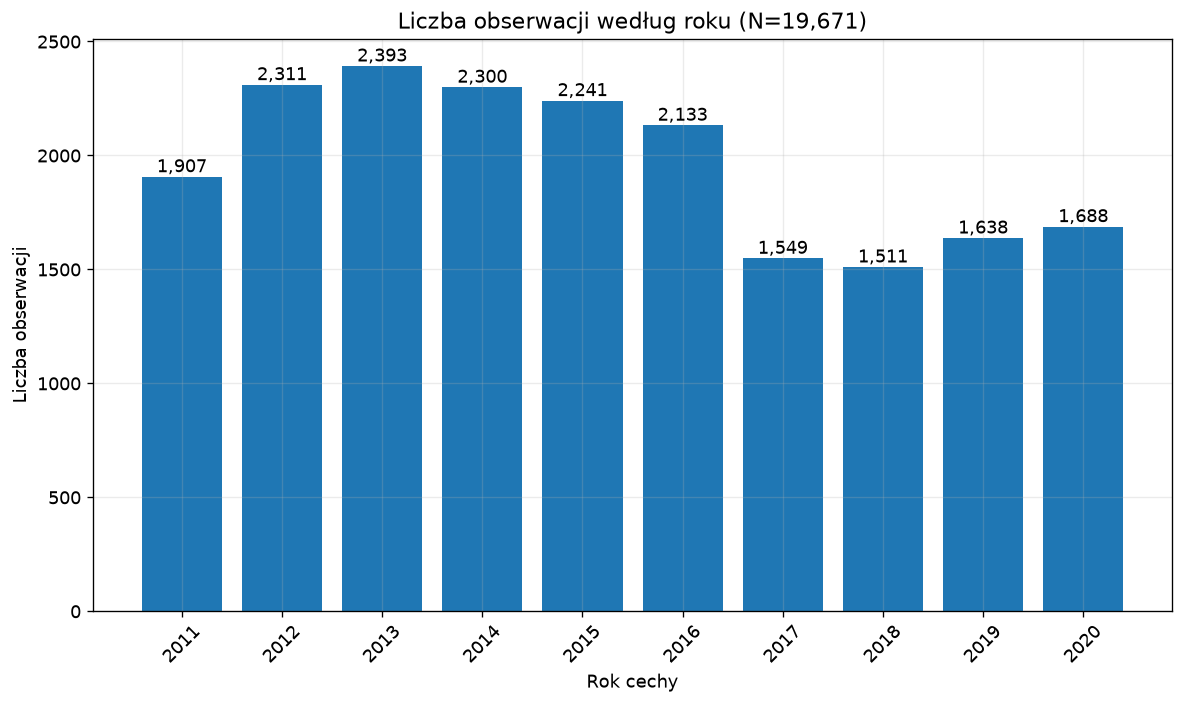

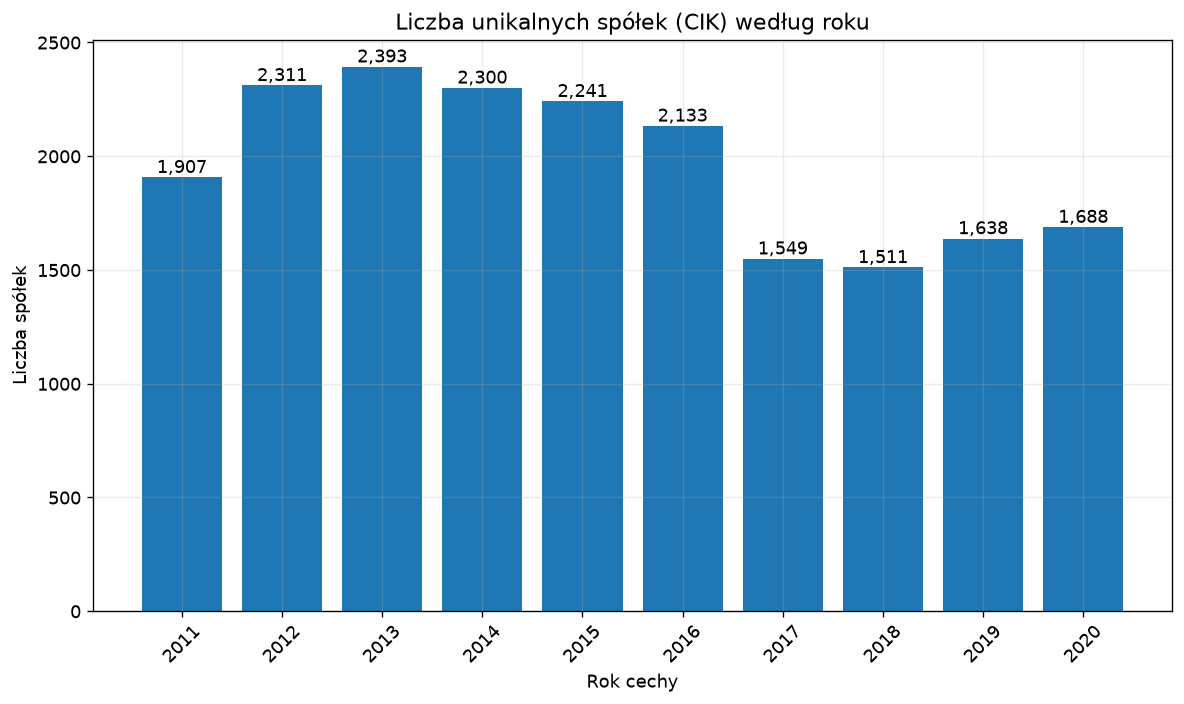

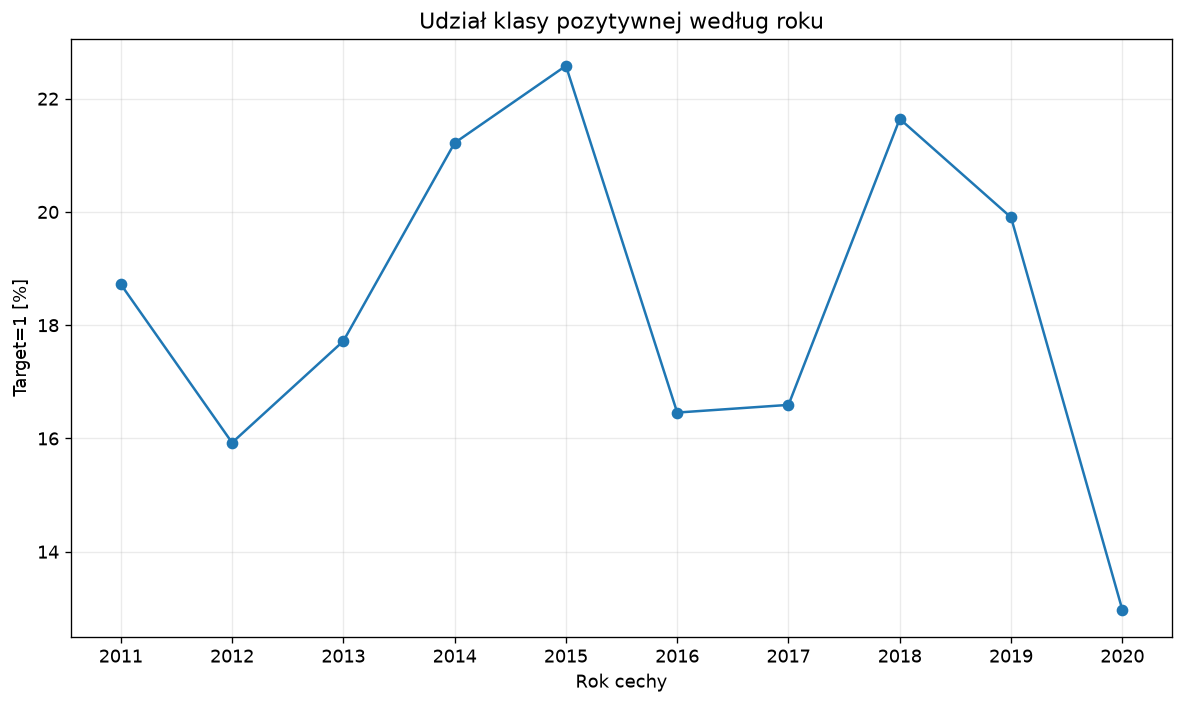

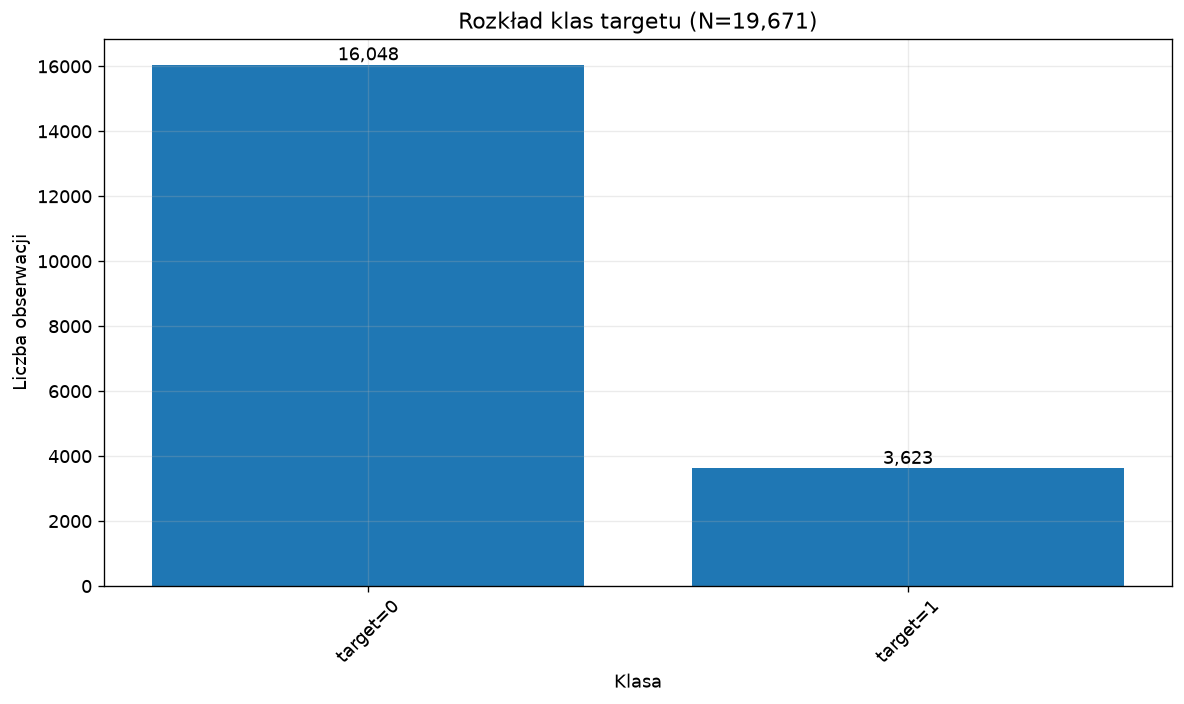

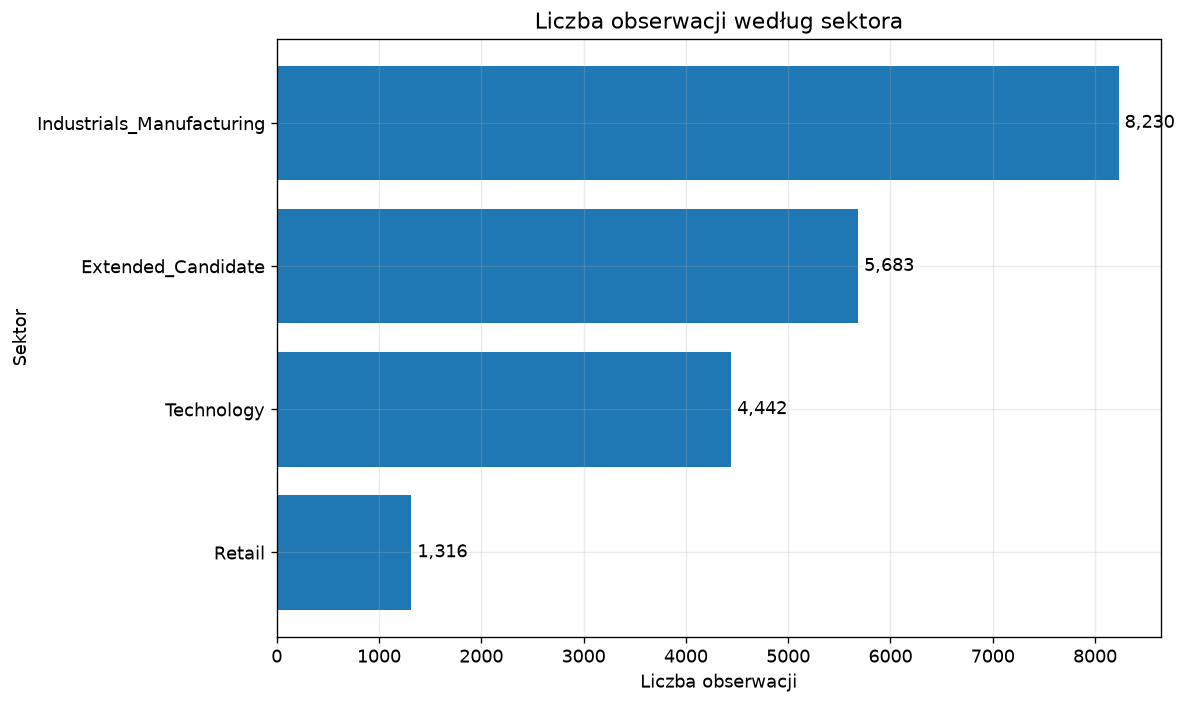

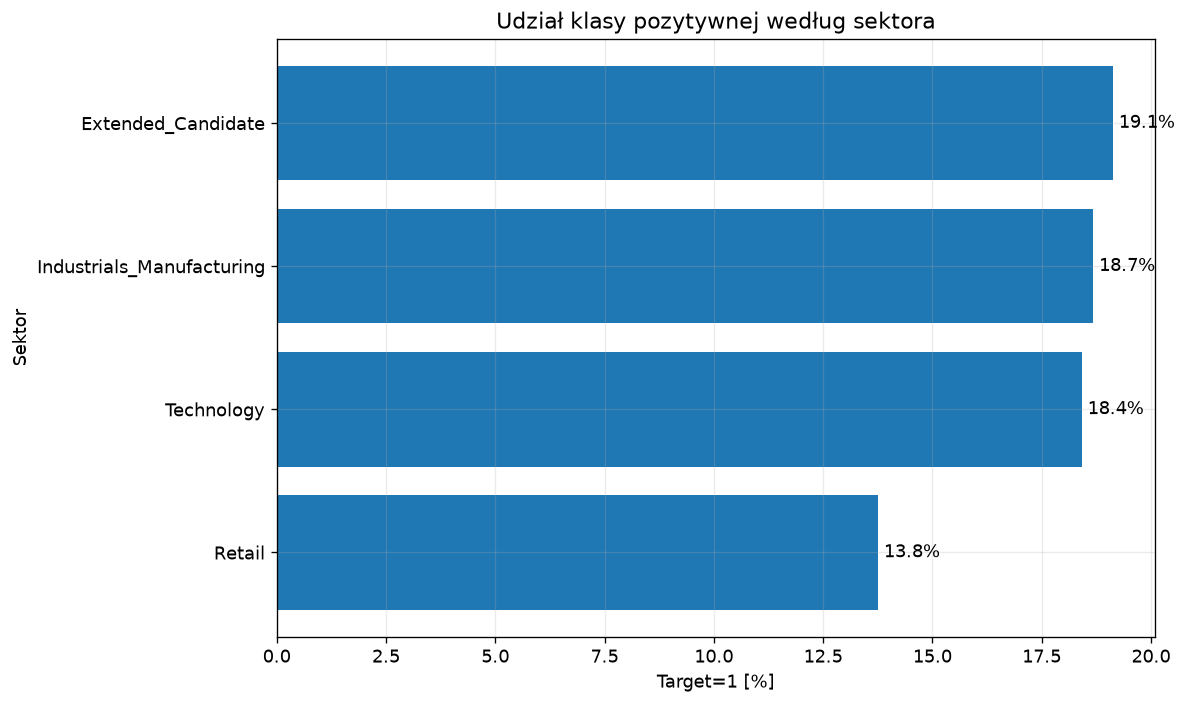

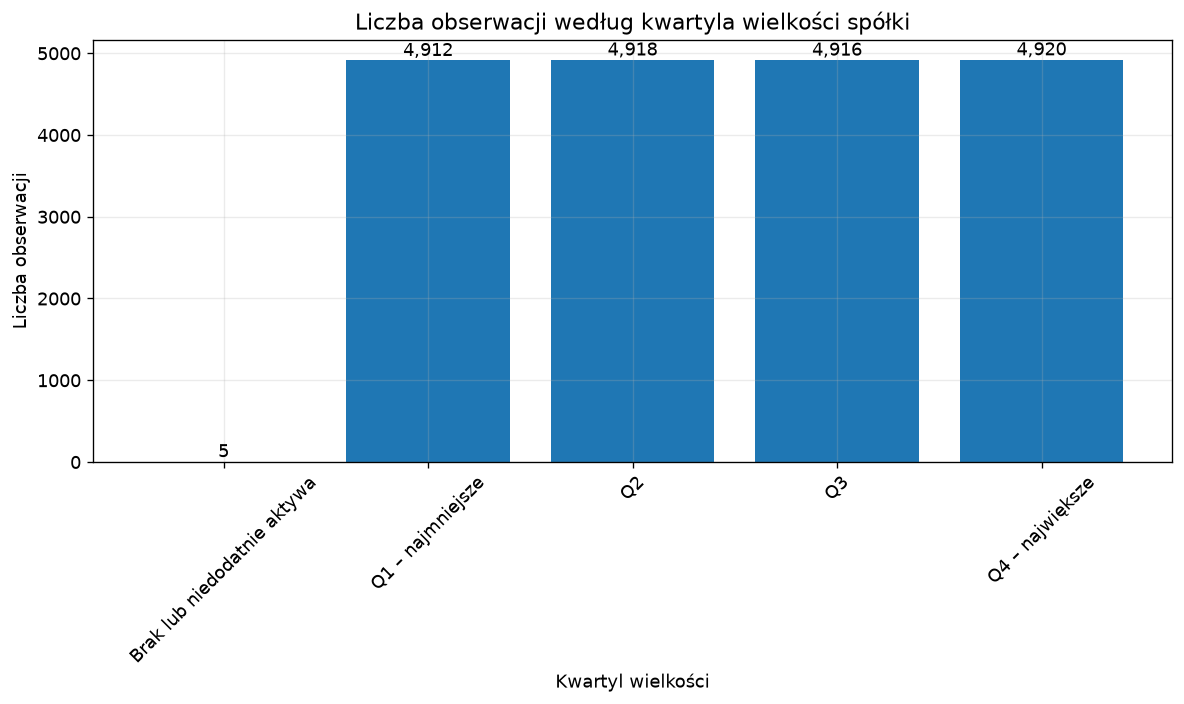

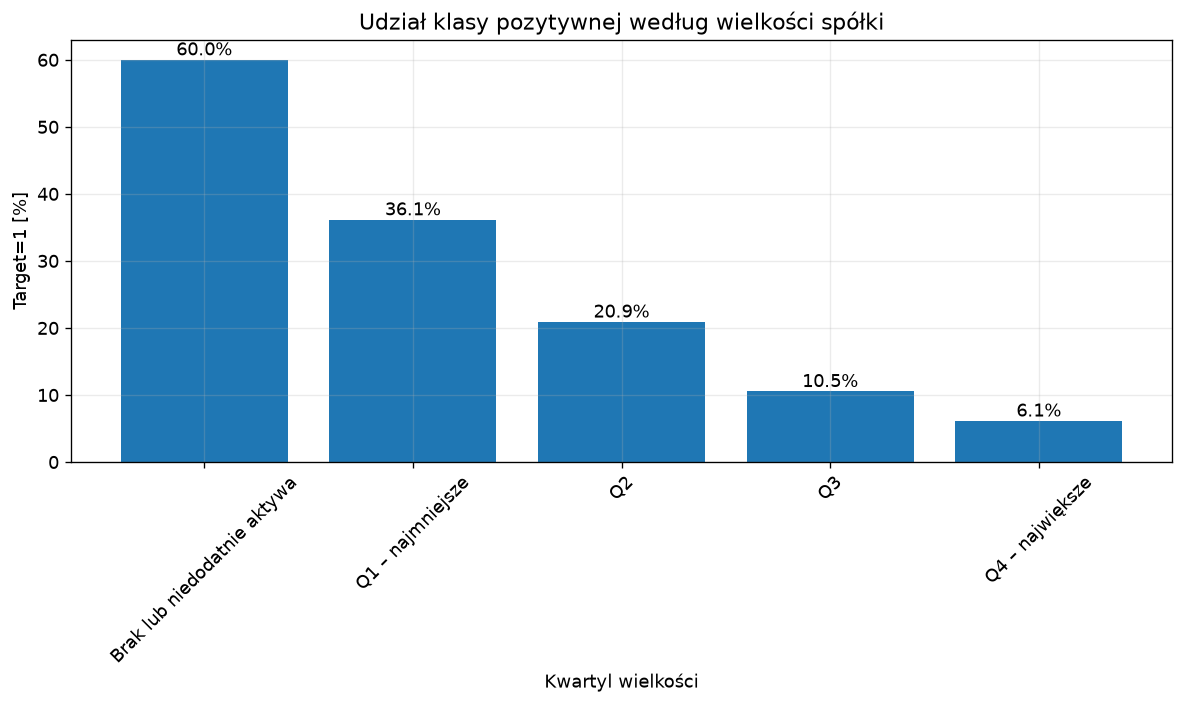

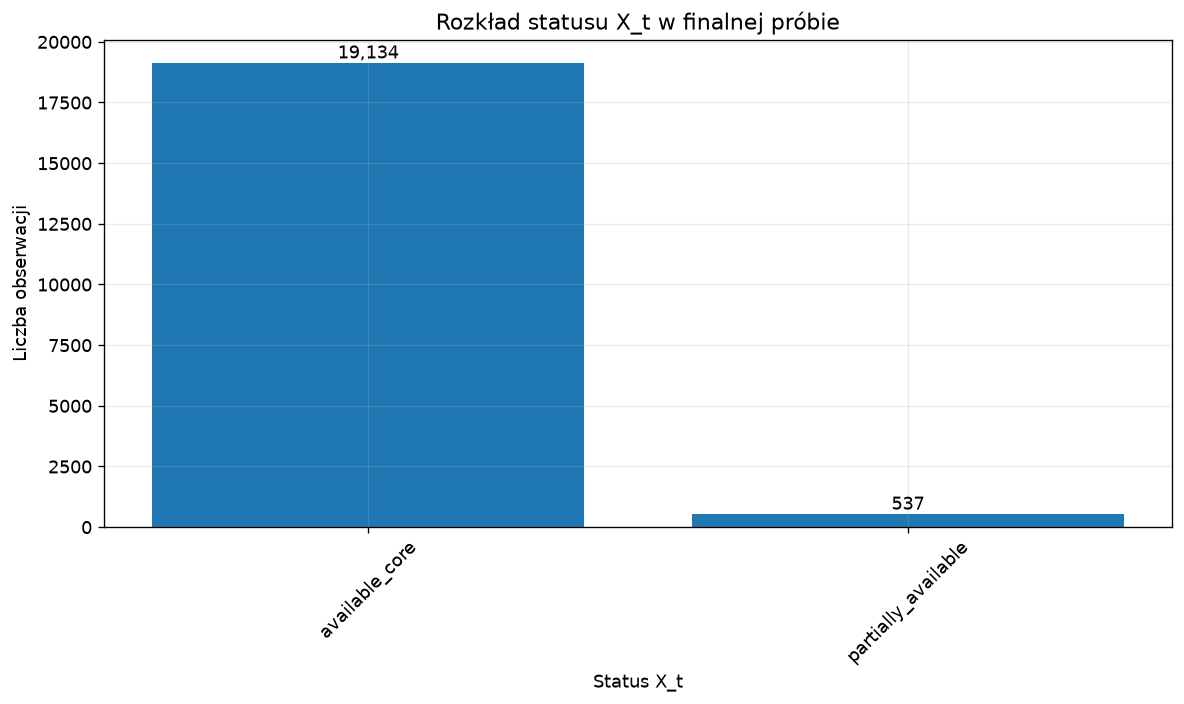

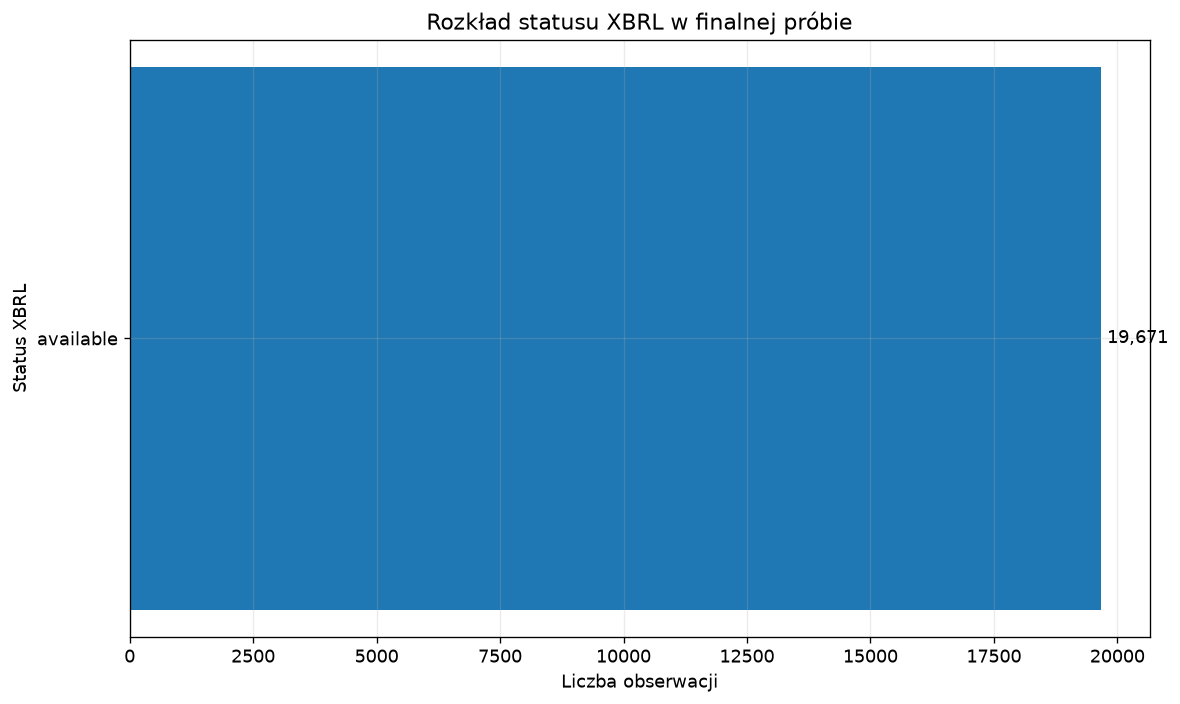

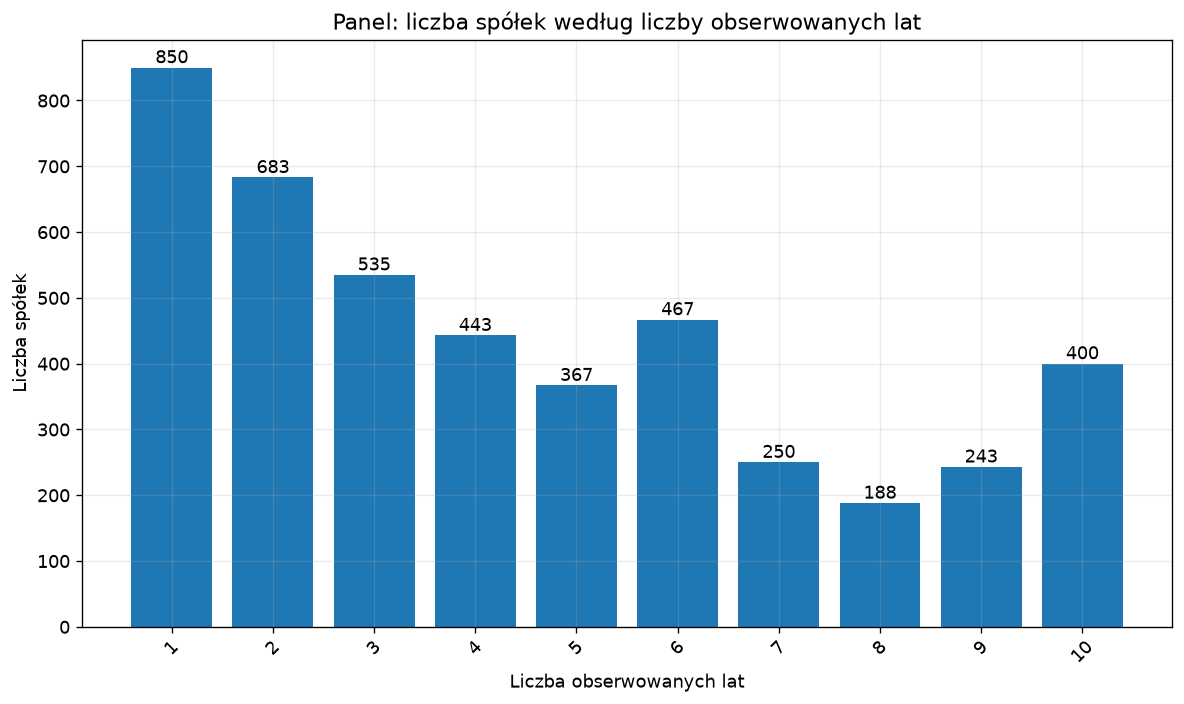

In [5]:
def bar_chart(
    data: pd.Series,
    *,
    title: str,
    x_label: str,
    y_label: str,
    filename: str,
    horizontal: bool = False,
    percent: bool = False,
) -> None:
    fig, ax = plt.subplots()
    labels = [str(label) for label in data.index]
    values = data.to_numpy(dtype=float)
    if horizontal:
        bars = ax.barh(labels, values)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        for bar in bars:
            value = bar.get_width()
            label = f"{value:.1f}%" if percent else f"{value:,.0f}"
            ax.text(value, bar.get_y() + bar.get_height() / 2, f" {label}", va="center")
    else:
        bars = ax.bar(labels, values)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.tick_params(axis="x", rotation=45)
        for bar in bars:
            value = bar.get_height()
            label = f"{value:.1f}%" if percent else f"{value:,.0f}"
            ax.text(bar.get_x() + bar.get_width() / 2, value, label, ha="center", va="bottom")
    ax.set_title(title)
    finalize_figure(fig, filename)


bar_chart(
    year_summary["n"],
    title=f"Liczba obserwacji według roku (N={len(analysis_frame):,})",
    x_label="Rok cechy",
    y_label="Liczba obserwacji",
    filename="01_observations_by_year.png",
)
bar_chart(
    year_summary["unique_cik"],
    title="Liczba unikalnych spółek (CIK) według roku",
    x_label="Rok cechy",
    y_label="Liczba spółek",
    filename="02_unique_companies_by_year.png",
)

fig, ax = plt.subplots()
ax.plot(year_summary.index, year_summary["target_1_pct"], marker="o")
ax.set_title("Udział klasy pozytywnej według roku")
ax.set_xlabel("Rok cechy")
ax.set_ylabel("Target=1 [%]")
ax.set_xticks(year_summary.index)
finalize_figure(fig, "03_positive_rate_by_year.png")

bar_chart(
    target_summary["n"],
    title=f"Rozkład klas targetu (N={len(analysis_frame):,})",
    x_label="Klasa",
    y_label="Liczba obserwacji",
    filename="04_target_distribution.png",
)
bar_chart(
    sector_summary["n"].sort_values(),
    title="Liczba obserwacji według sektora",
    x_label="Liczba obserwacji",
    y_label="Sektor",
    filename="05_observations_by_sector.png",
    horizontal=True,
)
bar_chart(
    sector_summary["target_1_pct"].sort_values(),
    title="Udział klasy pozytywnej według sektora",
    x_label="Target=1 [%]",
    y_label="Sektor",
    filename="06_positive_rate_by_sector.png",
    horizontal=True,
    percent=True,
)
bar_chart(
    size_summary["n"],
    title="Liczba obserwacji według kwartyla wielkości spółki",
    x_label="Kwartyl wielkości",
    y_label="Liczba obserwacji",
    filename="07_observations_by_size_quartile.png",
)
bar_chart(
    size_summary["target_1_pct"],
    title="Udział klasy pozytywnej według wielkości spółki",
    x_label="Kwartyl wielkości",
    y_label="Target=1 [%]",
    filename="08_positive_rate_by_size_quartile.png",
    percent=True,
)
bar_chart(
    x_t_status_summary["n"],
    title="Rozkład statusu X_t w finalnej próbie",
    x_label="Status X_t",
    y_label="Liczba obserwacji",
    filename="09_x_t_status_distribution.png",
)
bar_chart(
    xbrl_status_summary["n"].sort_values(),
    title="Rozkład statusu XBRL w finalnej próbie",
    x_label="Liczba obserwacji",
    y_label="Status XBRL",
    filename="10_xbrl_status_distribution.png",
    horizontal=True,
)
bar_chart(
    company_years_distribution["liczba_spolek"],
    title="Panel: liczba spółek według liczby obserwowanych lat",
    x_label="Liczba obserwowanych lat",
    y_label="Liczba spółek",
    filename="11_company_years_distribution.png",
)


## 3.2. Statystyki opisowe 17 zamrożonych cech

Dla każdej cechy raportowane są liczebności, missingness, miary położenia i zróżnicowania, kwantyle, zera, wartości ujemne oraz obserwacje poza granicami `1.5 × IQR`. Średnie, odchylenia i kwantyle są liczone na wartościach skończonych. `NaN`, `+inf` i `-inf` nie są usuwane z DataFrame — ich liczba jest jawnie wykazana jako pominięta w danej statystyce.


In [6]:
def finite_series(frame: pd.DataFrame, feature: str) -> pd.Series:
    series = pd.to_numeric(frame[feature], errors="raise")
    values = series.to_numpy(dtype=float)
    return pd.Series(values[np.isfinite(values)], name=feature)


def descriptive_row(frame: pd.DataFrame, feature: str) -> dict:
    raw = pd.to_numeric(frame[feature], errors="raise")
    raw_values = raw.to_numpy(dtype=float)
    finite = finite_series(frame, feature)
    row = {
        "blok": FEATURE_TO_BLOCK[feature],
        "cecha": feature,
        "n_obserwacji": len(raw),
        "n_dostepnych_non_na": int(raw.notna().sum()),
        "n_finite": len(finite),
        "n_pominietych_w_statystykach": int(len(raw) - len(finite)),
        "missingness_pct": 100.0 * raw.isna().mean(),
        "n_pos_inf": int(np.isposinf(raw_values).sum()),
        "n_neg_inf": int(np.isneginf(raw_values).sum()),
    }
    if finite.empty:
        row.update(
            {
                "mean": np.nan,
                "median": np.nan,
                "std_ddof1": np.nan,
                "IQR": np.nan,
                "P1": np.nan,
                "P5": np.nan,
                "P25": np.nan,
                "P75": np.nan,
                "P95": np.nan,
                "P99": np.nan,
                "min": np.nan,
                "max": np.nan,
                "n_zer": 0,
                "n_ujemnych": 0,
                "n_poza_1_5_IQR": 0,
                "poza_1_5_IQR_pct_finite": np.nan,
                "skewness": np.nan,
            }
        )
        return row

    quantiles = finite.quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99])
    q25 = float(quantiles.loc[0.25])
    q75 = float(quantiles.loc[0.75])
    iqr = q75 - q25
    lower = q25 - 1.5 * iqr
    upper = q75 + 1.5 * iqr
    outlier_mask = finite.lt(lower) | finite.gt(upper)
    row.update(
        {
            "mean": float(finite.mean()),
            "median": float(finite.median()),
            "std_ddof1": float(finite.std(ddof=1)) if len(finite) > 1 else np.nan,
            "IQR": iqr,
            "P1": float(quantiles.loc[0.01]),
            "P5": float(quantiles.loc[0.05]),
            "P25": q25,
            "P75": q75,
            "P95": float(quantiles.loc[0.95]),
            "P99": float(quantiles.loc[0.99]),
            "min": float(finite.min()),
            "max": float(finite.max()),
            "n_zer": int(finite.eq(0.0).sum()),
            "n_ujemnych": int(finite.lt(0.0).sum()),
            "n_poza_1_5_IQR": int(outlier_mask.sum()),
            "poza_1_5_IQR_pct_finite": 100.0 * outlier_mask.mean(),
            "skewness": float(finite.skew()) if len(finite) >= 3 else np.nan,
        }
    )
    return row


descriptive_stats = pd.DataFrame(
    [descriptive_row(analysis_frame, feature) for feature in FEATURES]
).set_index("cecha")
descriptive_stats = descriptive_stats.loc[FEATURES]

save_table(descriptive_stats, "18_descriptive_statistics_17_features.csv")
show_table("Zbiorcza tabela statystyk opisowych 17 cech", descriptive_stats)


#### Zbiorcza tabela statystyk opisowych 17 cech

,blok,n_obserwacji,n_dostepnych_non_na,n_finite,n_pominietych_w_statystykach,missingness_pct,n_pos_inf,n_neg_inf,mean,median,std_ddof1,IQR,P1,P5,P25,P75,P95,P99,min,max,n_zer,n_ujemnych,n_poza_1_5_IQR,poza_1_5_IQR_pct_finite,skewness
cecha,,,,,,,,,,,,,,,,,,,,,,,,,
log_assets_t,L,19671,19666,19666,5,0.0254,0,0,19.3508,19.7535,2.9532,3.8971,11.2391,13.8079,17.5629,21.4600,23.5392,24.9492,7.1601,26.8193,0,0,275,1.3984,-0.6301
roa_t,L,19671,19261,19261,410,2.0843,0,0,-1.6915,0.0183,83.2431,0.2121,-15.8371,-2.1982,-0.1435,0.0686,0.1671,0.3749,"-11,072.3464",300.9108,2,8346,2918,15.1498,-123.6704
ocf_to_assets_t,L,19671,19376,19376,295,1.4997,0,0,-0.2551,0.0668,6.8832,0.1590,-4.6909,-1.0142,-0.0388,0.1202,0.2222,0.3648,-717.1347,12.5559,1,5775,2785,14.3735,-89.7573
current_ratio_t,L,19671,19596,19596,75,0.3813,0,0,2.9059,1.9219,5.6906,1.9736,0.0200,0.2170,1.1877,3.1612,7.9483,17.3688,0.0001,345.4072,0,0,1624,8.2874,26.2943
liabilities_to_assets_t,L,19671,19637,19637,34,0.1728,0,0,2.3556,0.5379,86.9238,0.4152,0.0587,0.1246,0.3348,0.7500,2.4518,22.3837,0.0000,"11,913.4155",1,0,1588,8.0868,131.4818
working_capital_to_assets_t,L,19671,19594,19594,77,0.3914,0,0,-1.4651,0.2058,86.9156,0.3576,-18.2107,-1.1761,0.0430,0.4006,0.7229,0.8737,"-11,912.4155",7.3811,1,3759,1420,7.2471,-131.7812
accruals_to_assets_t,L,19671,19229,19229,442,2.2470,0,0,-1.4361,-0.0610,78.7944,0.1081,-11.2540,-1.0938,-0.1301,-0.0220,0.0866,0.4016,"-10,491.6591",308.2212,3,16218,2867,14.9098,-124.3482
asset_growth_1y,D,19671,17555,17555,2116,10.7570,0,0,6.2984,0.0469,342.3163,0.2521,-0.6930,-0.3505,-0.0503,0.2018,1.6161,9.0218,-0.9997,"29,528.5400",2,6487,2656,15.1296,75.0741
delta_roa_1y,D,19671,17107,17107,2564,13.0344,0,0,1.8479,-0.0014,217.9968,0.0930,-8.3551,-0.7022,-0.0519,0.0410,0.7172,9.7736,"-11,044.2018","22,773.9422",2,8790,4084,23.8733,67.3547


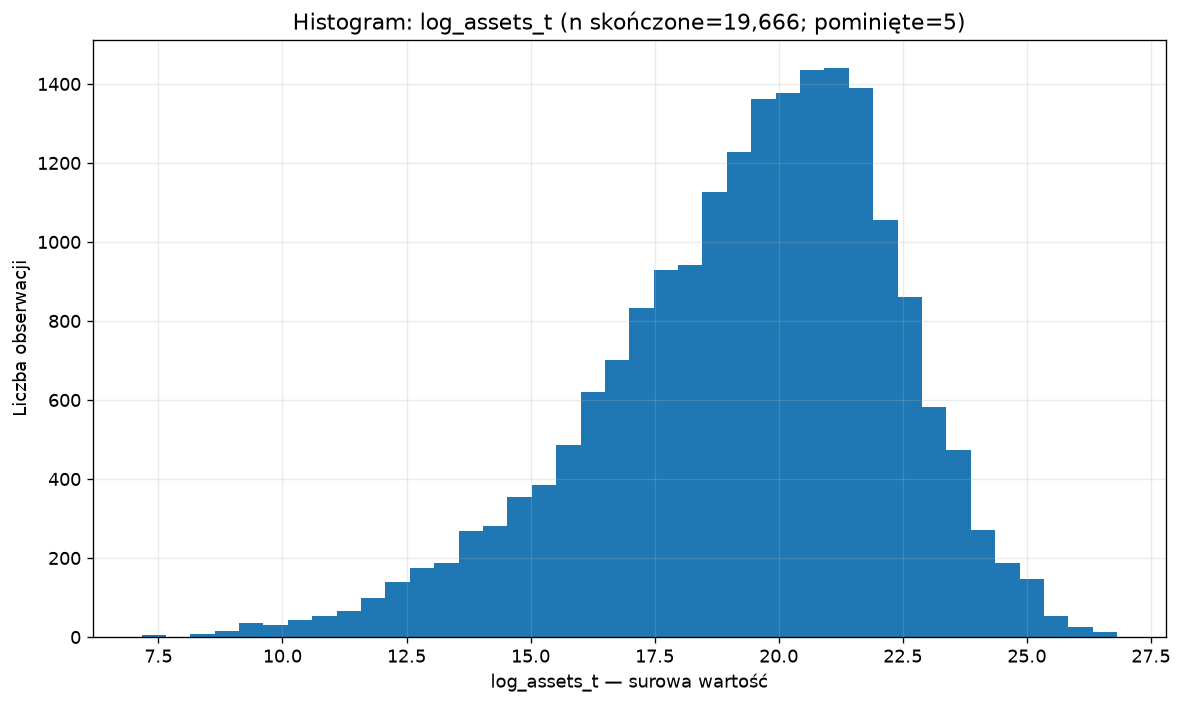

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


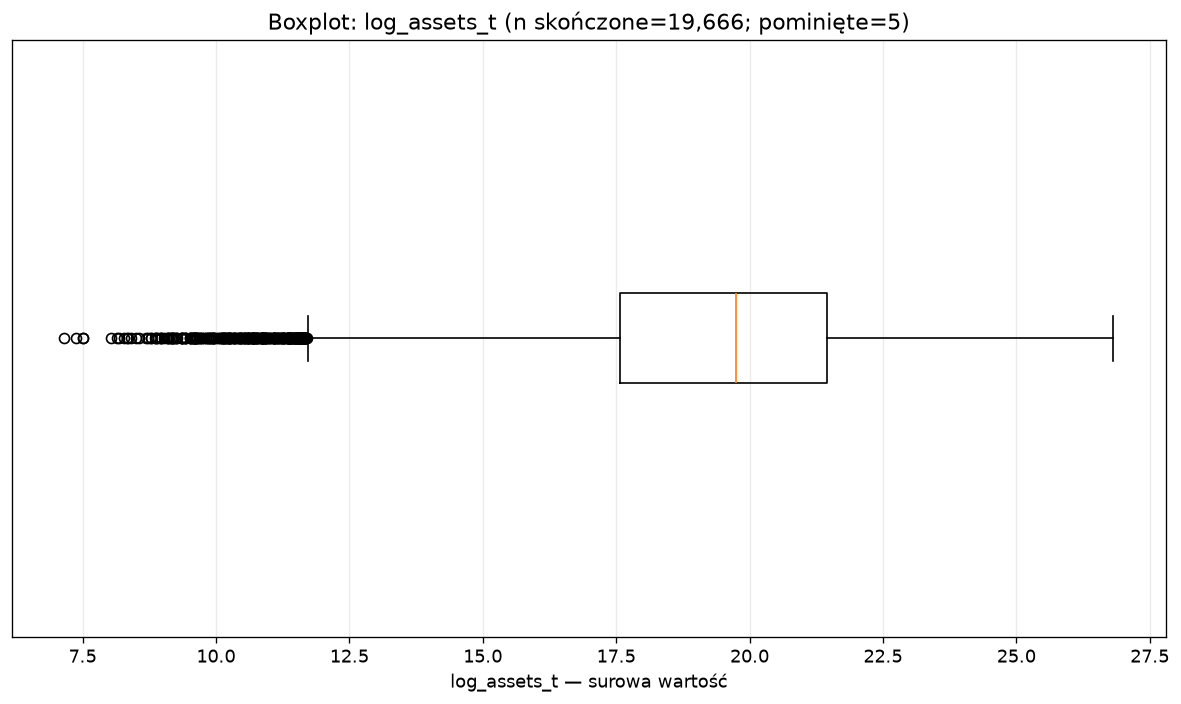

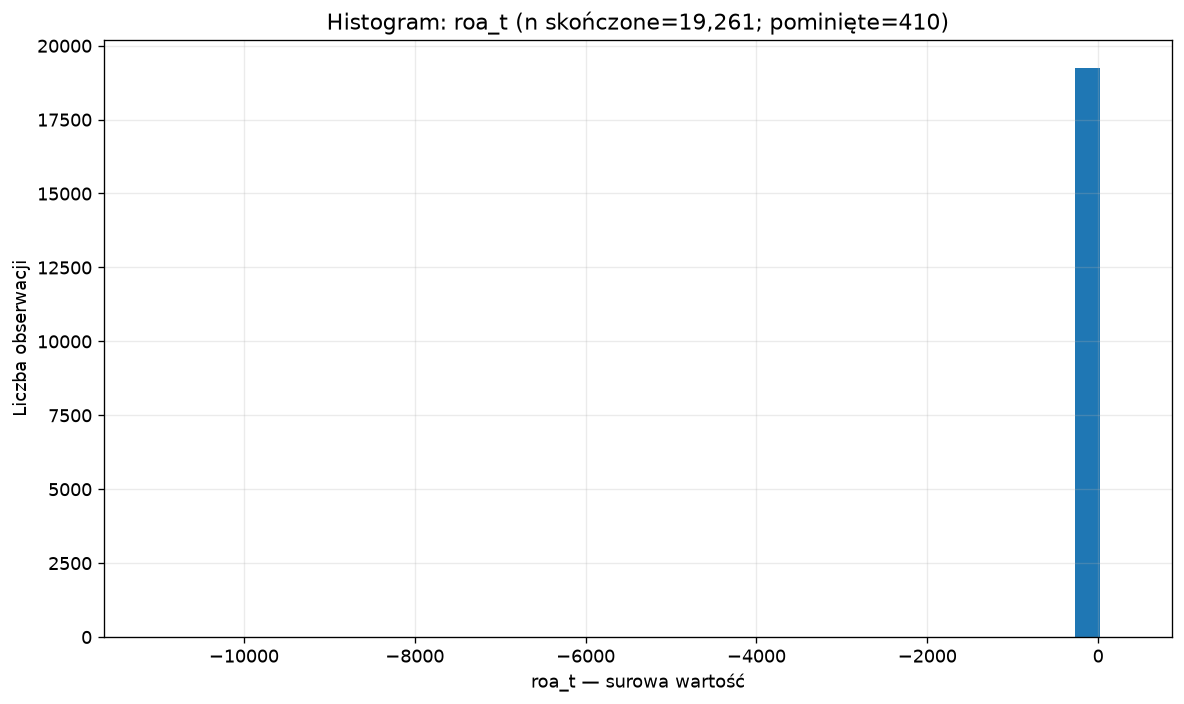

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


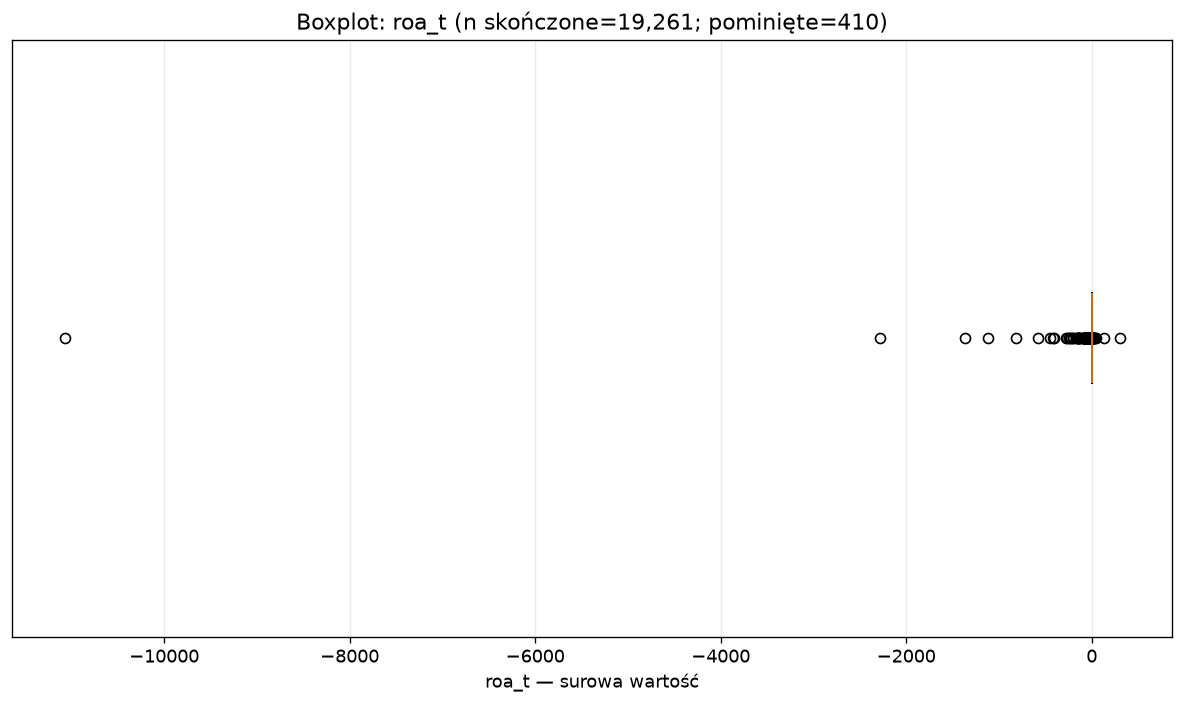

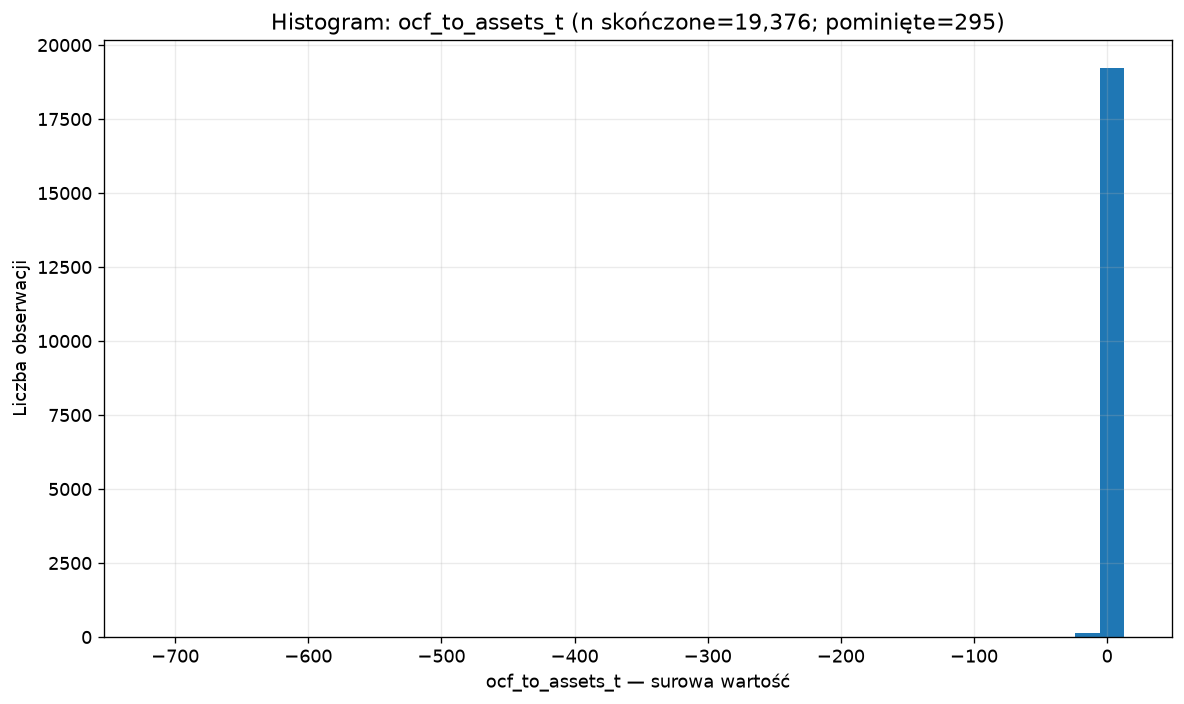

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


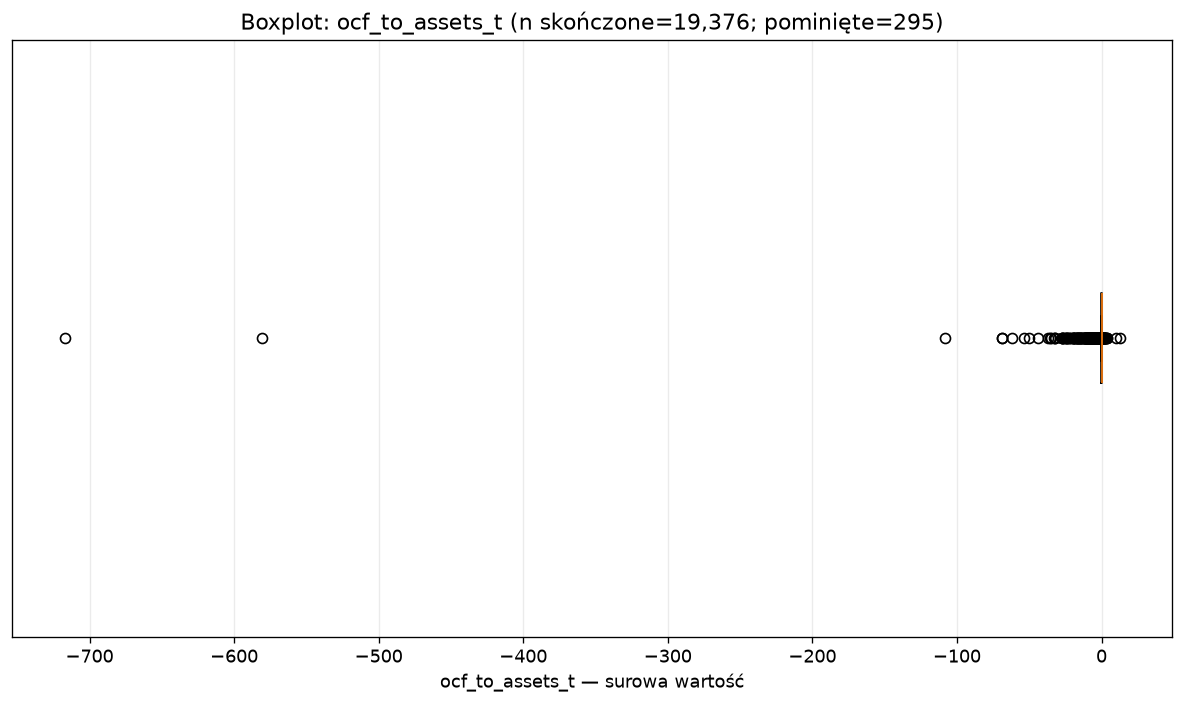

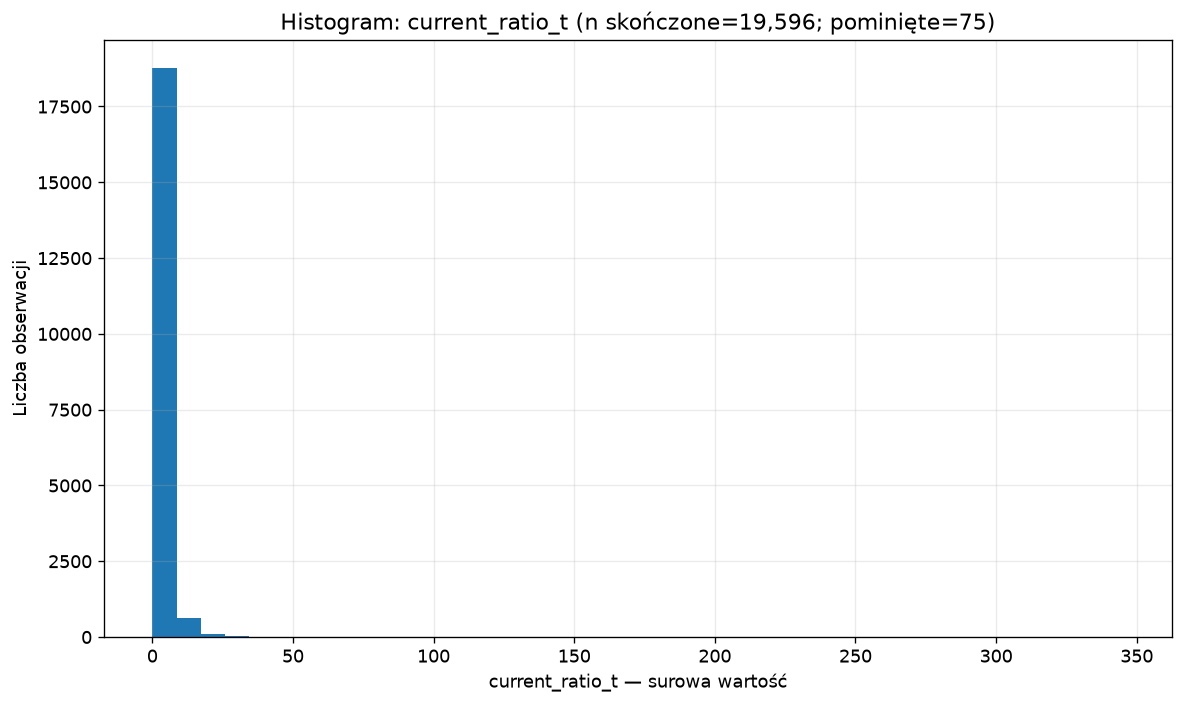

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


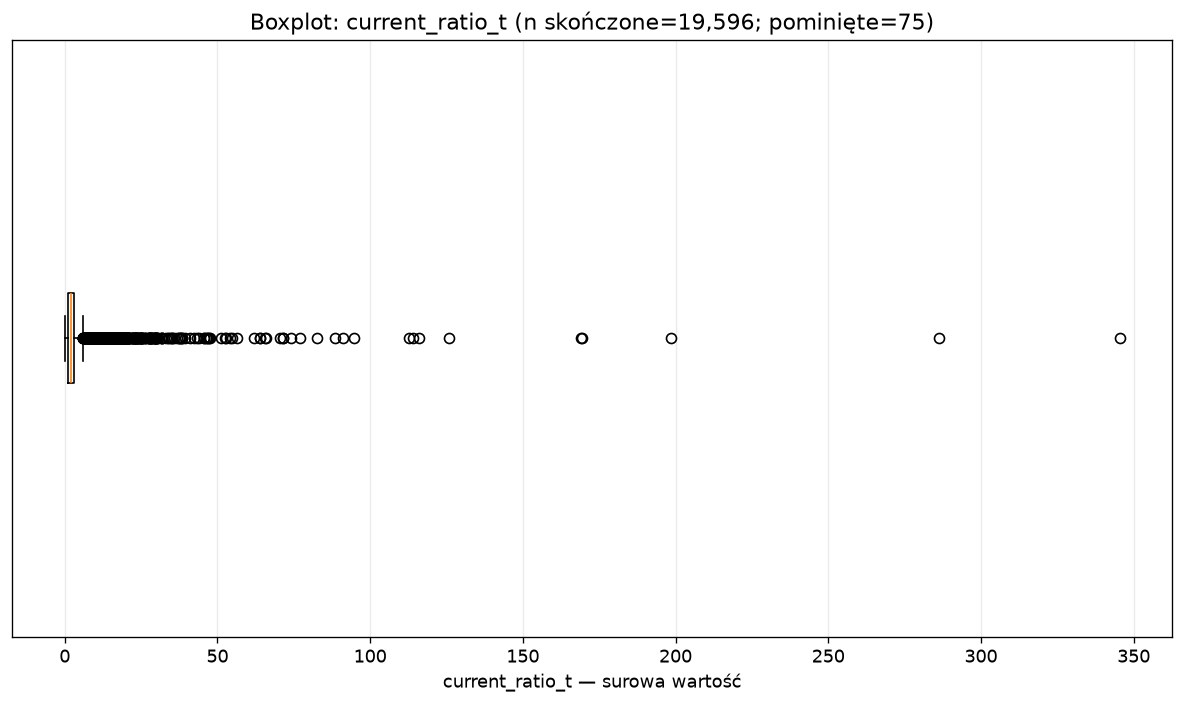

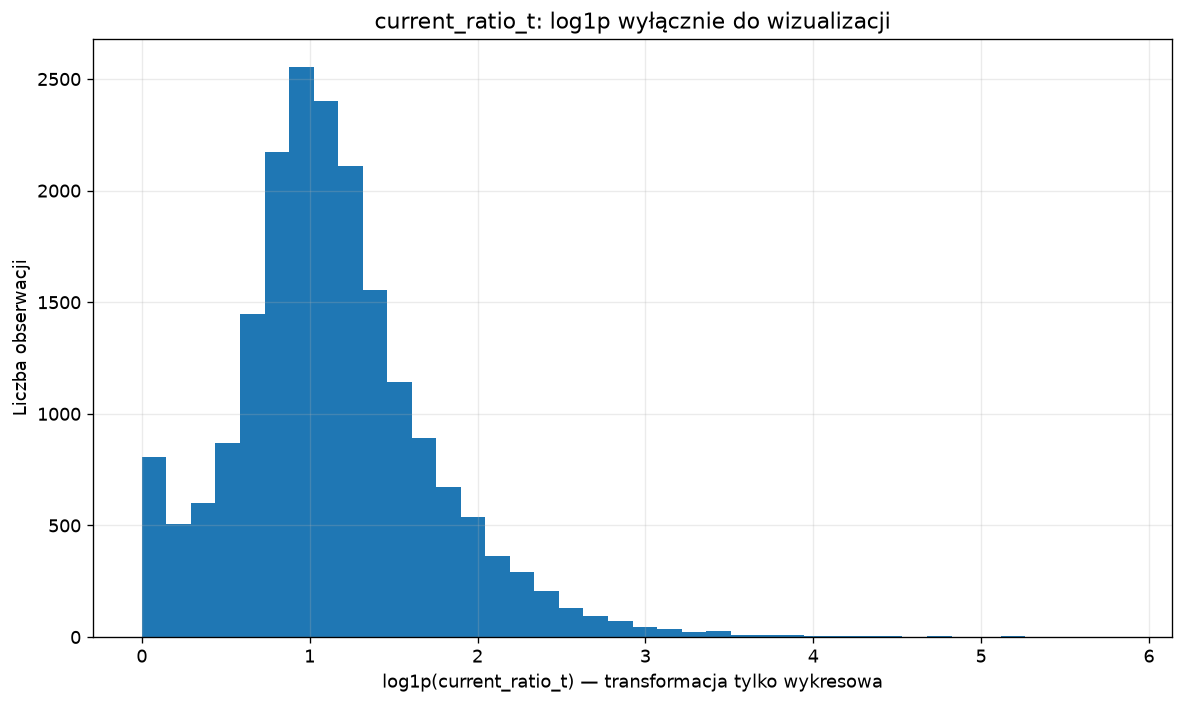

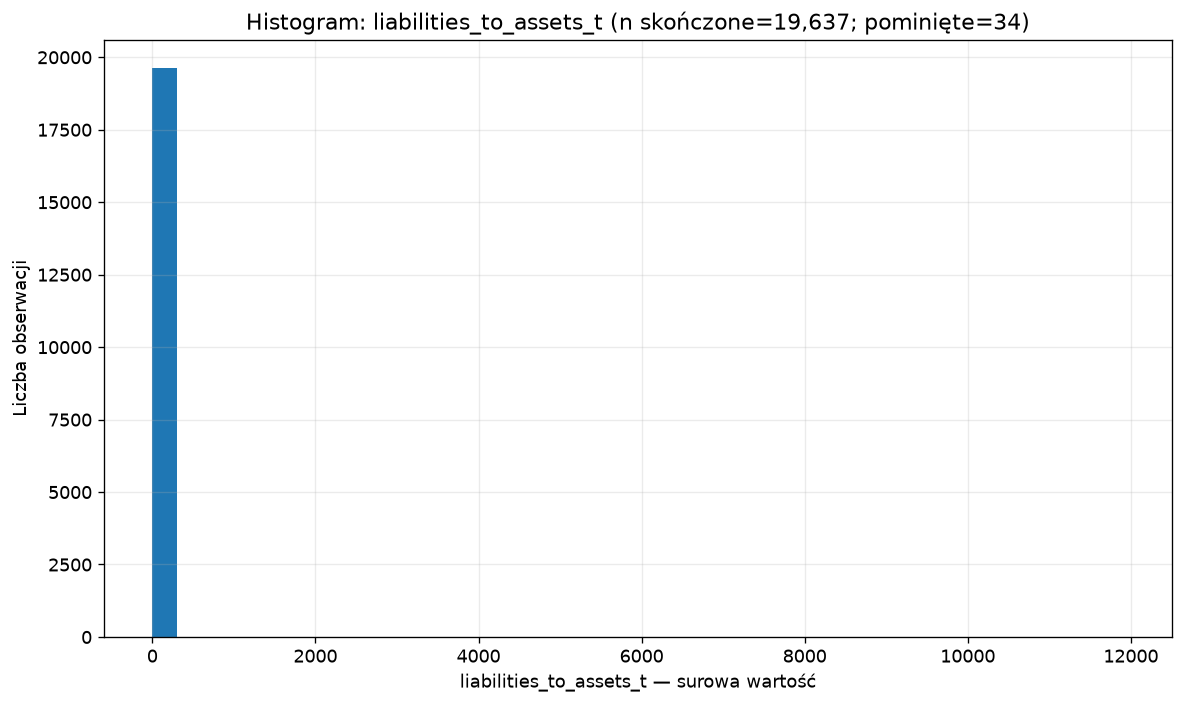

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


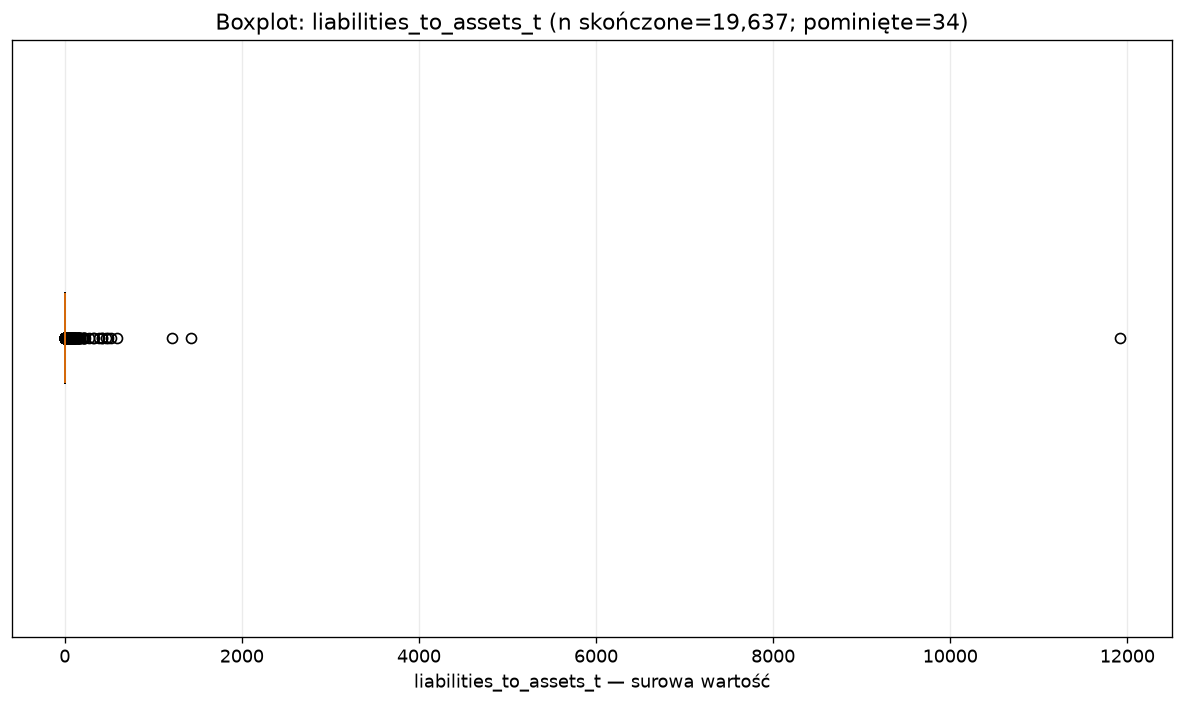

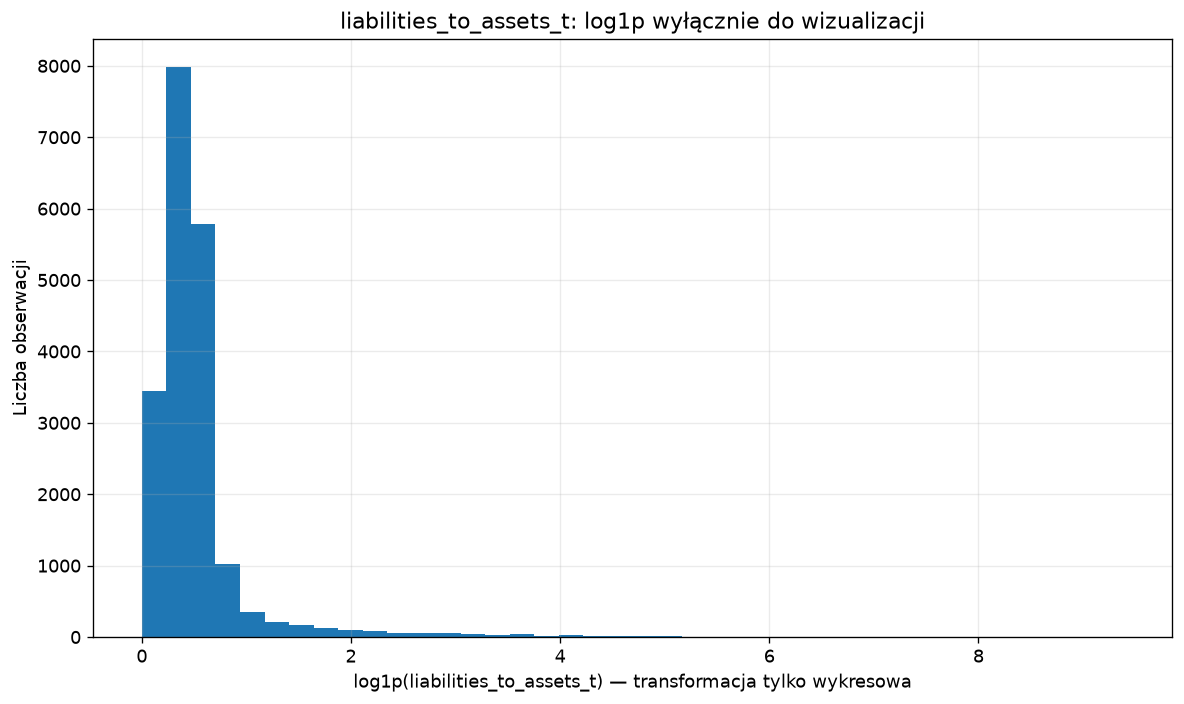

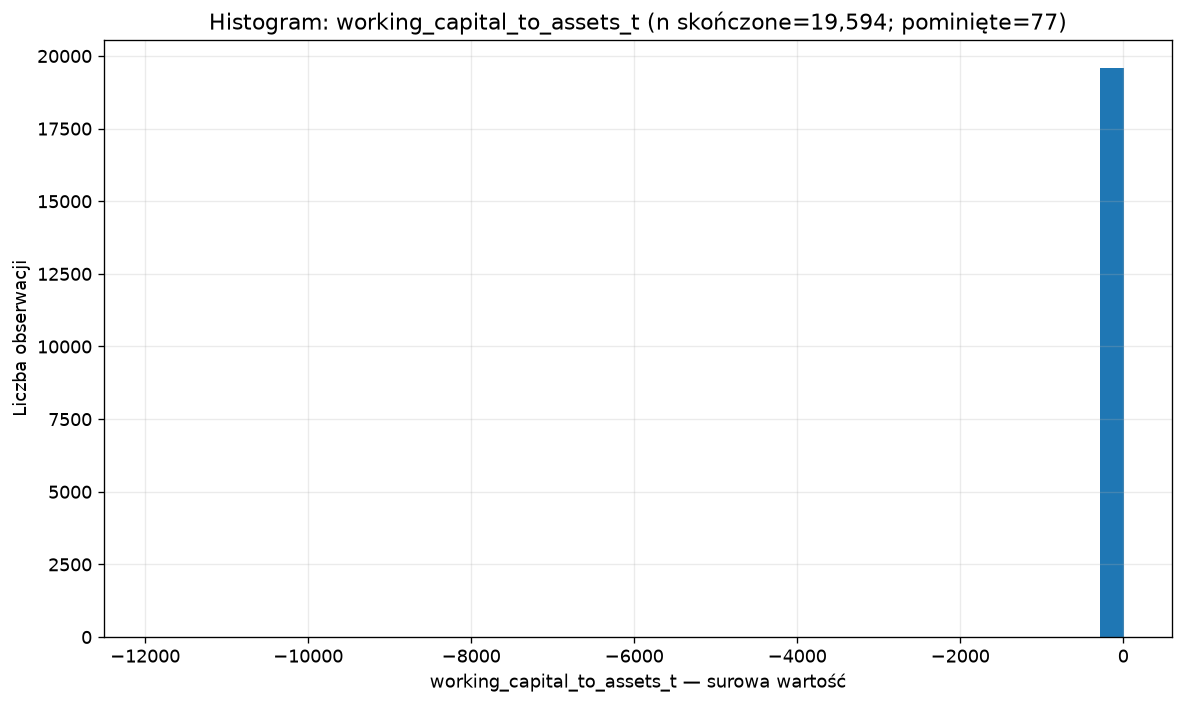

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


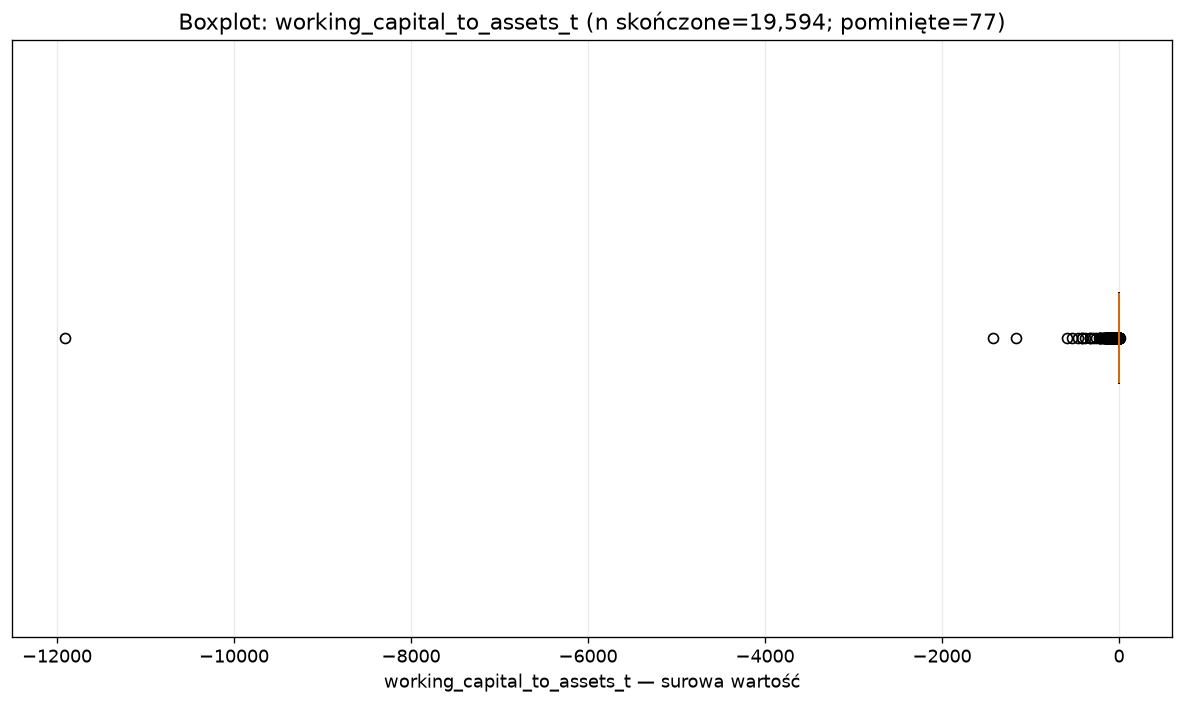

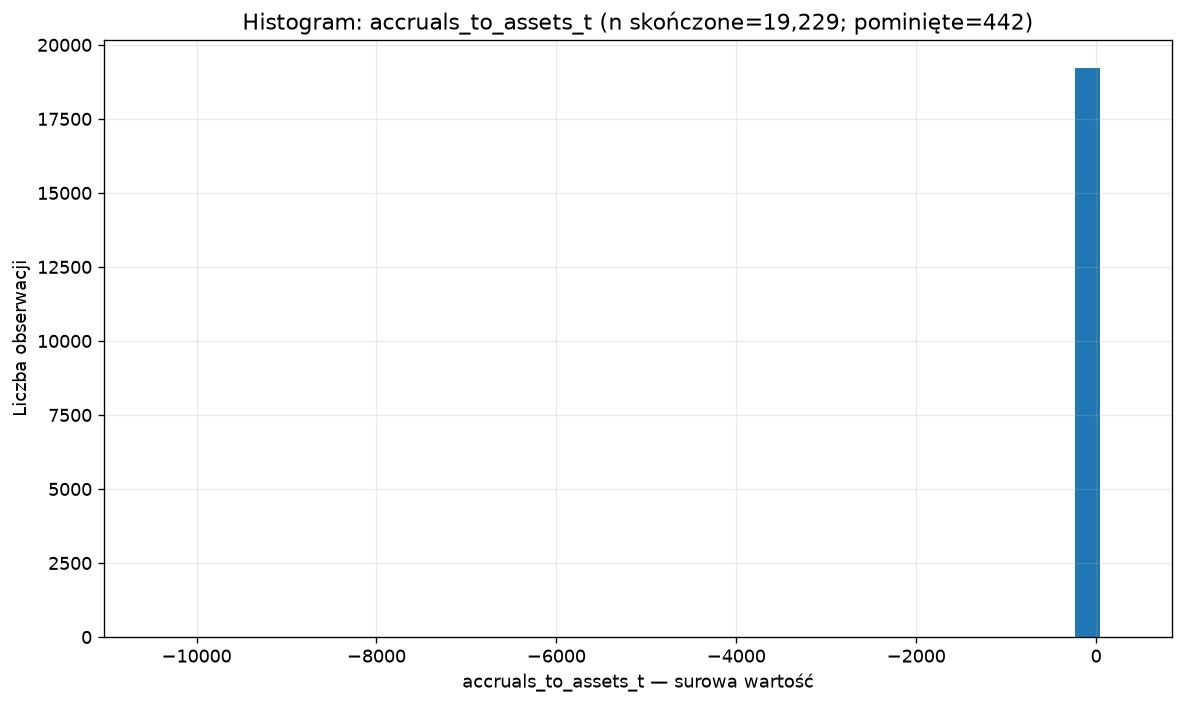

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


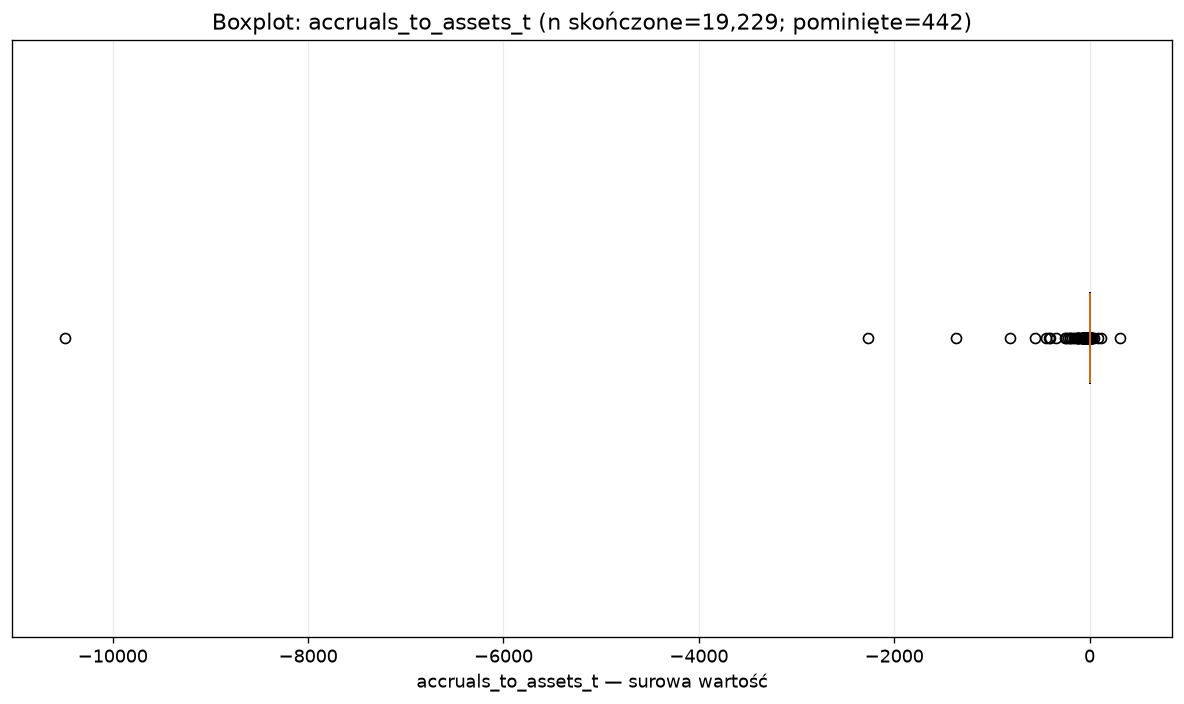

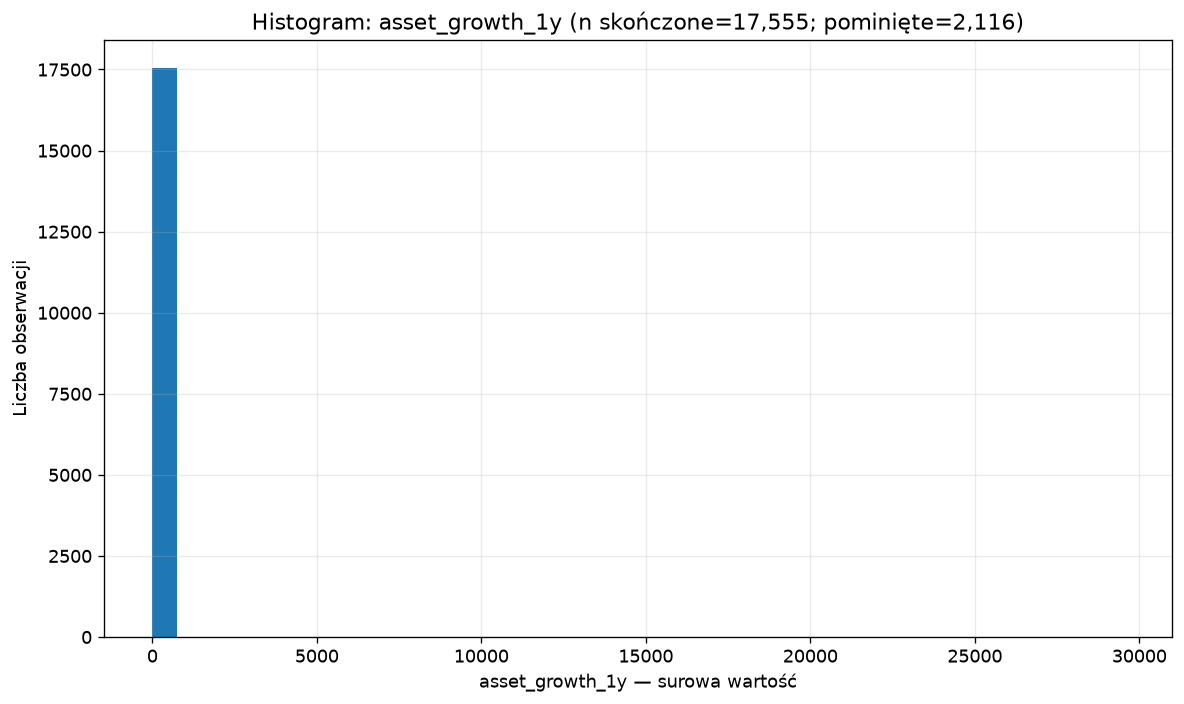

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


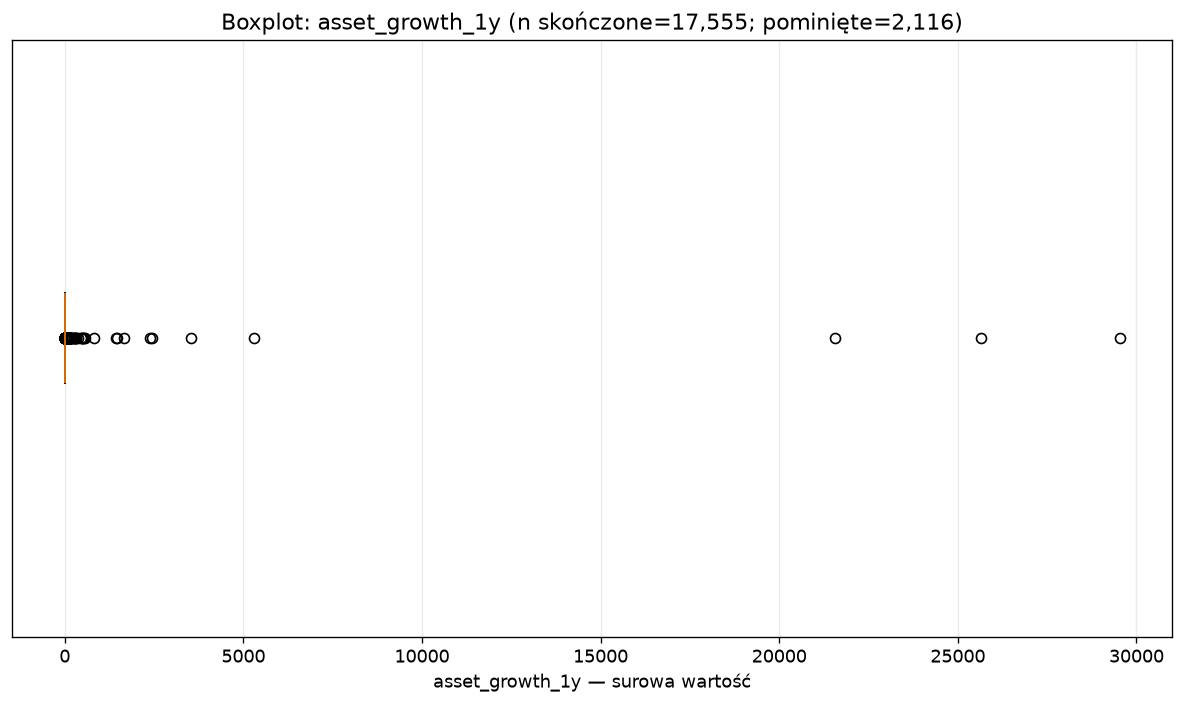

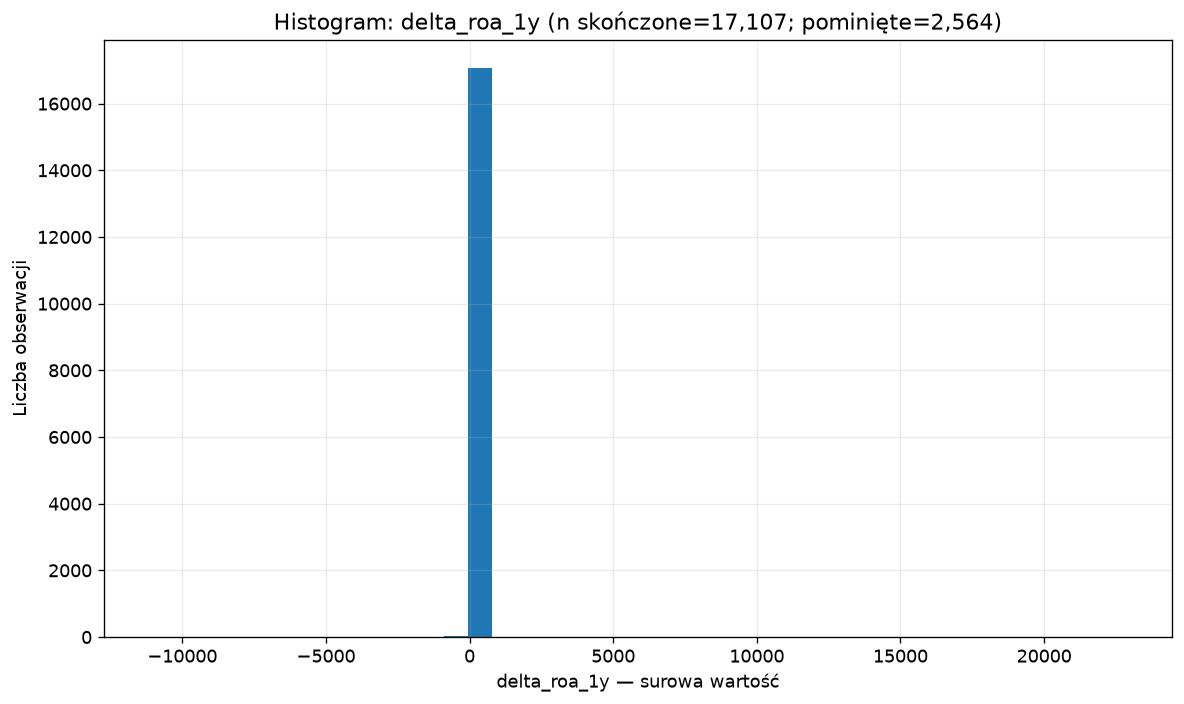

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


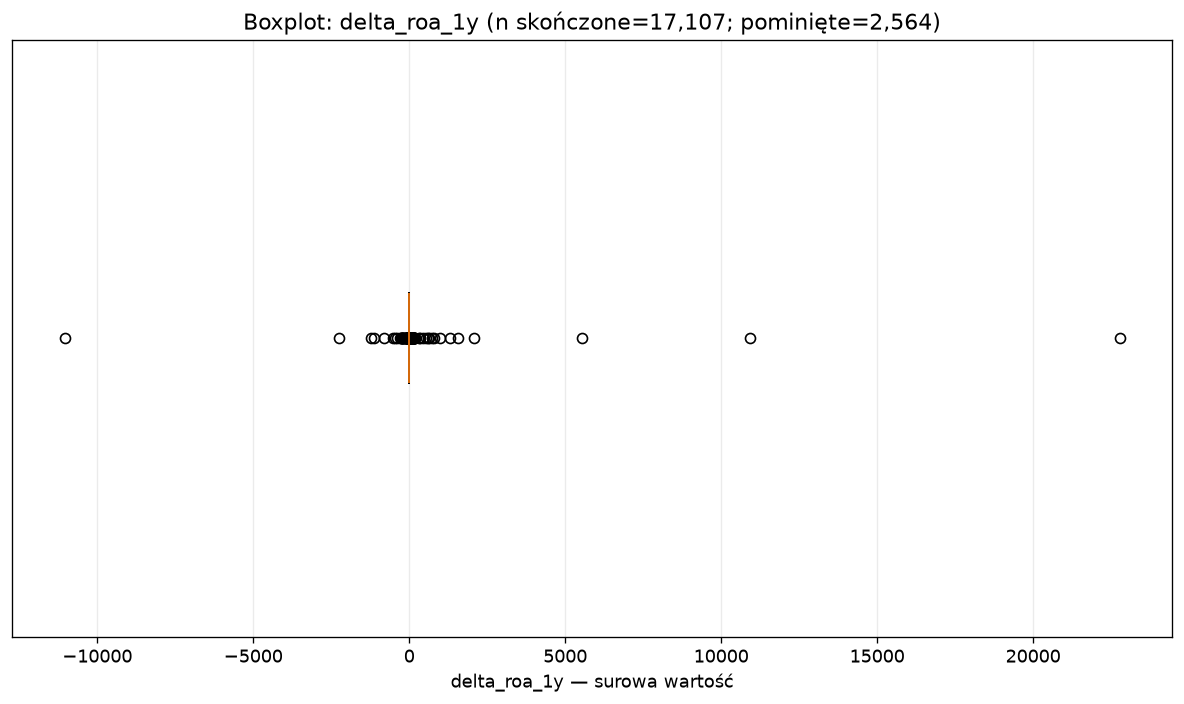

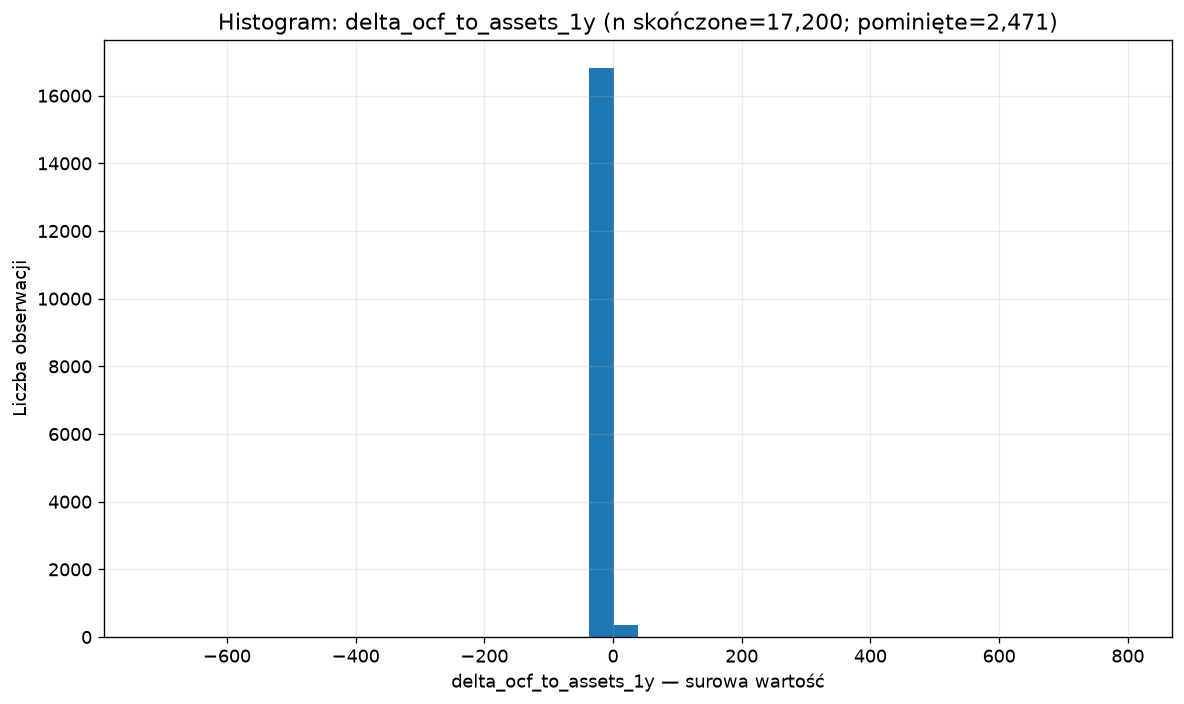

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


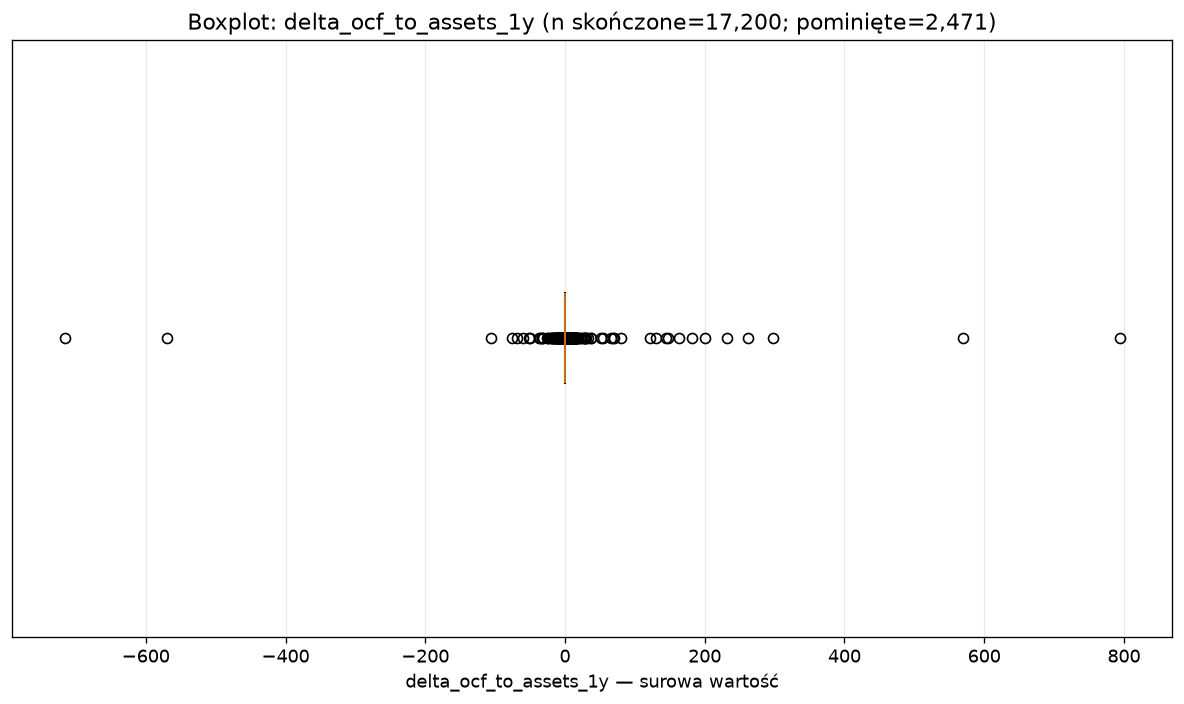

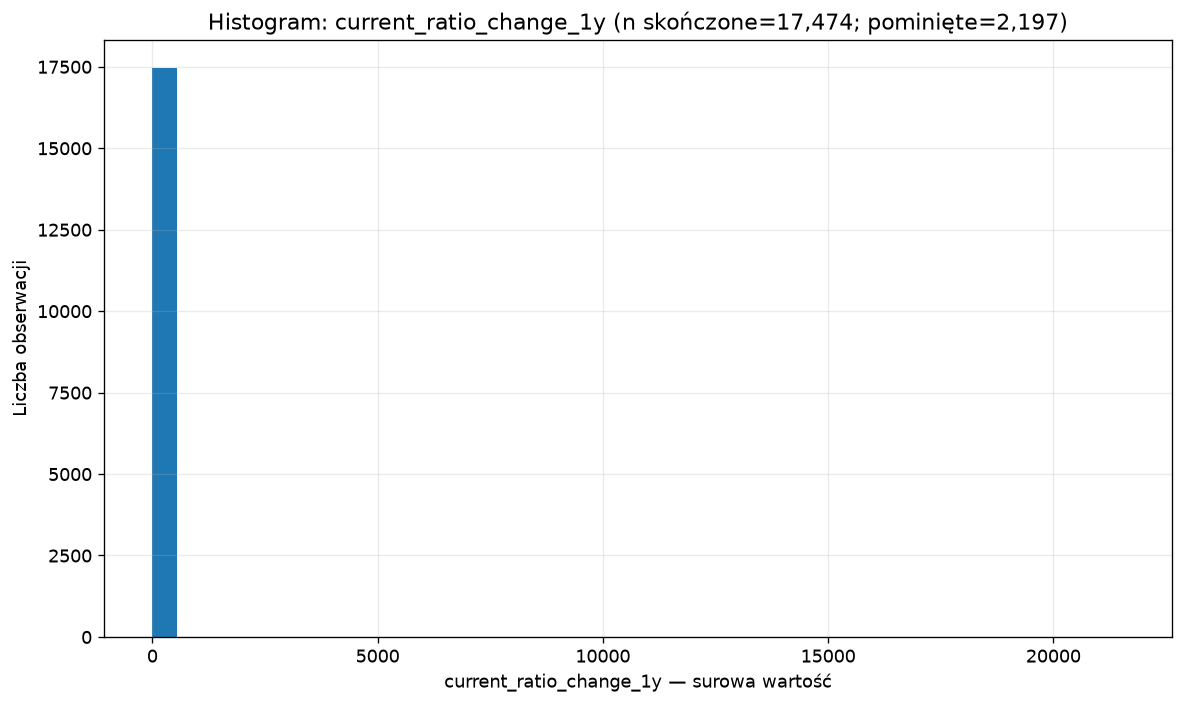

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


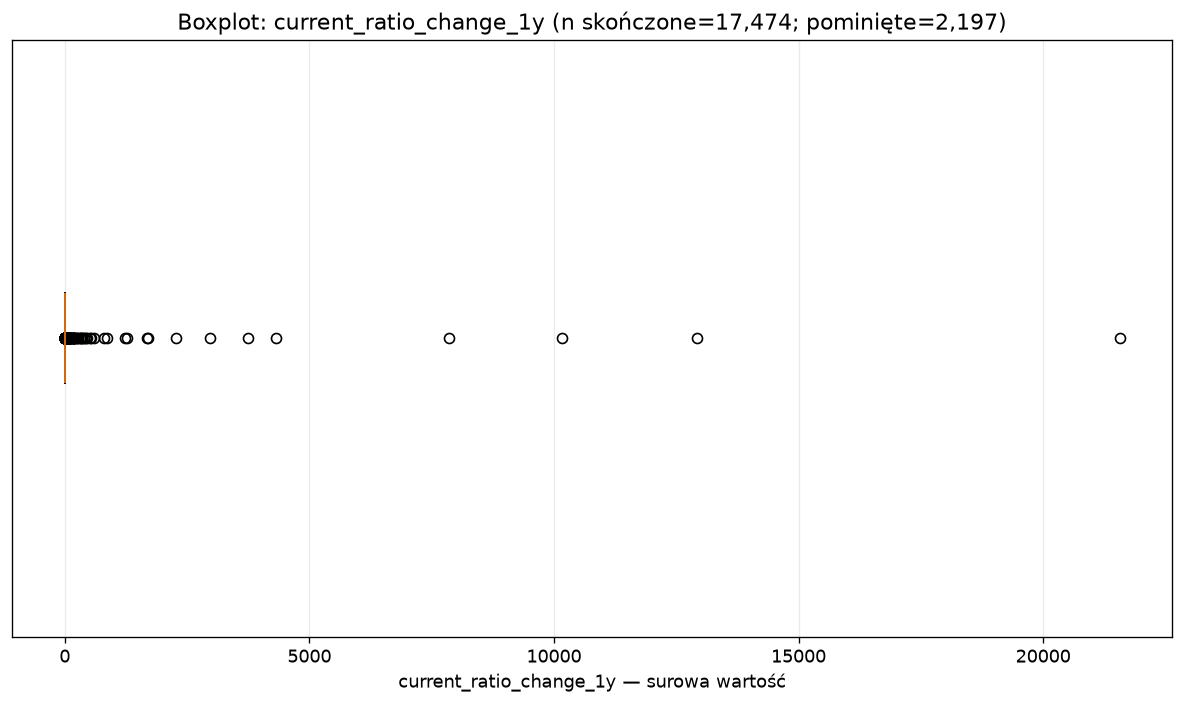

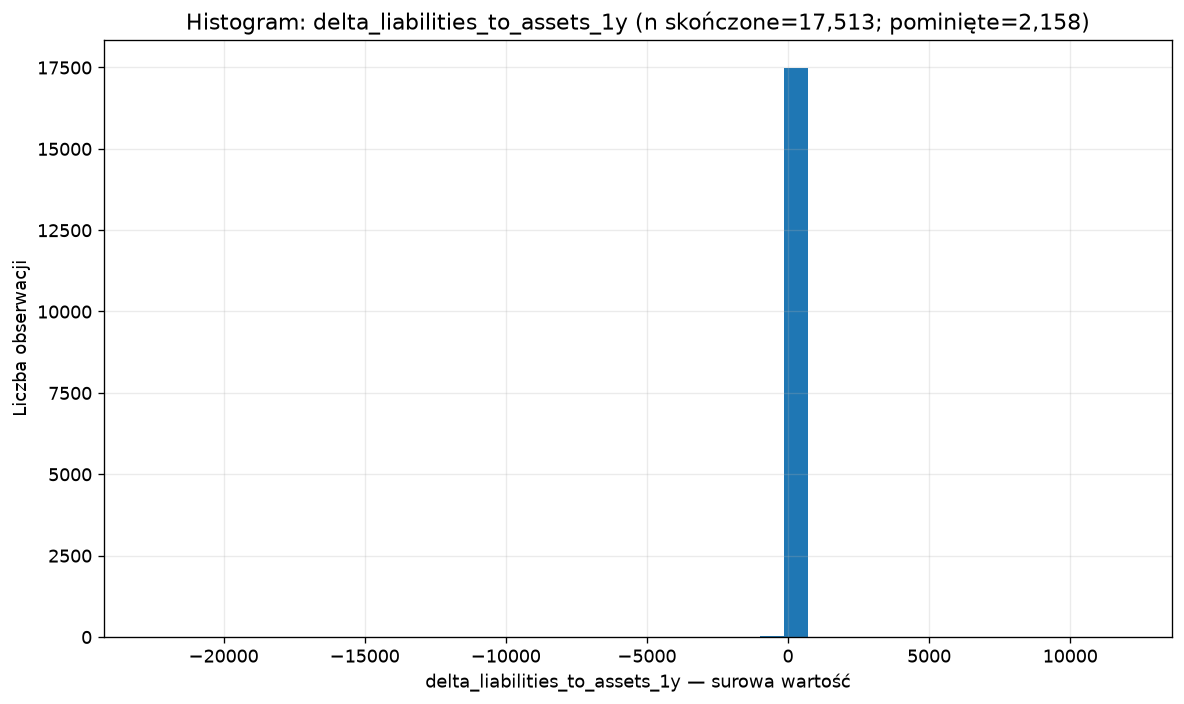

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


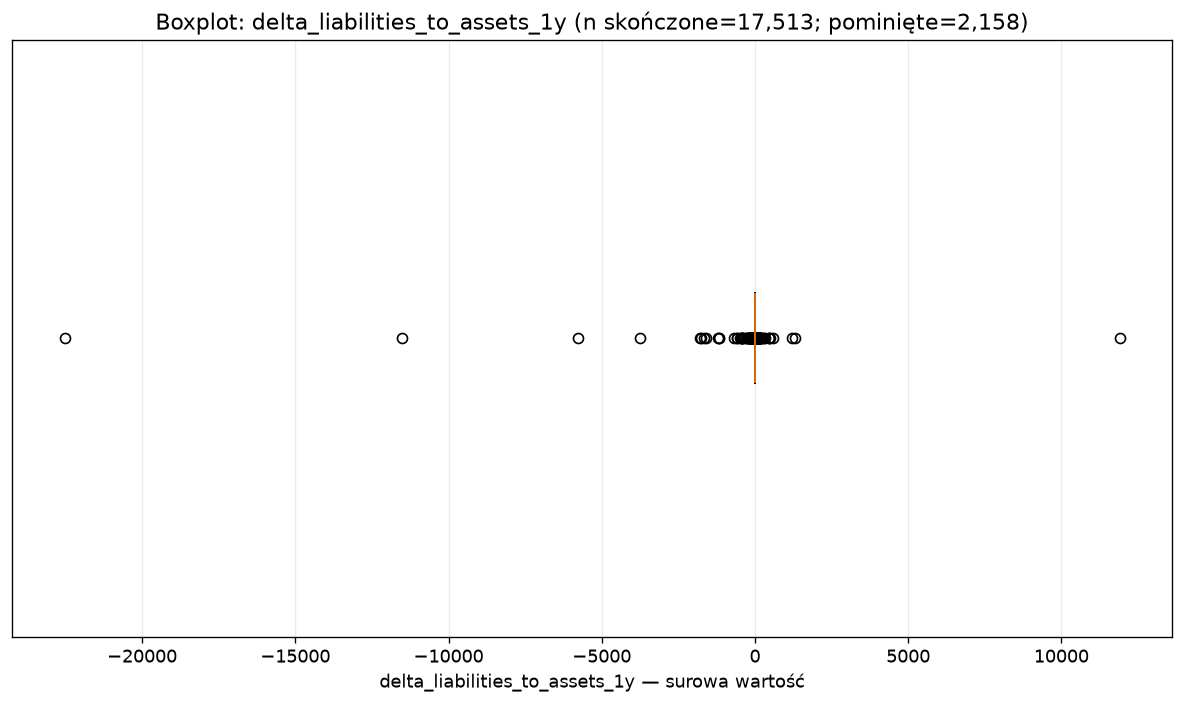

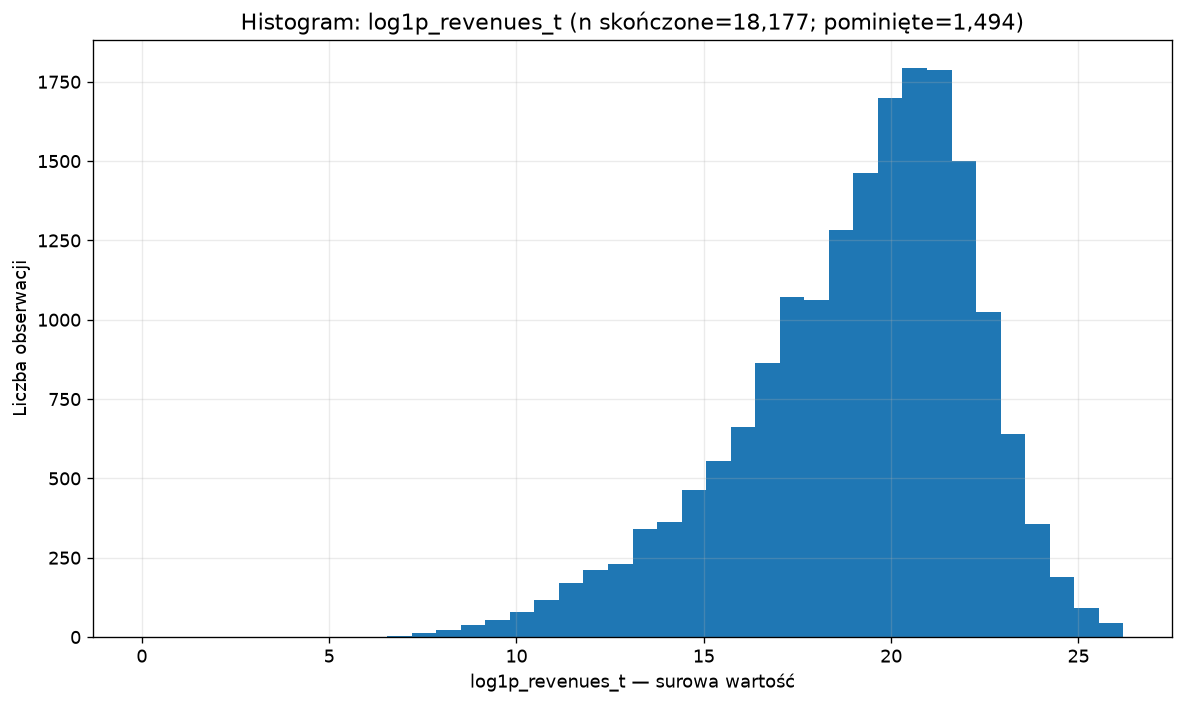

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


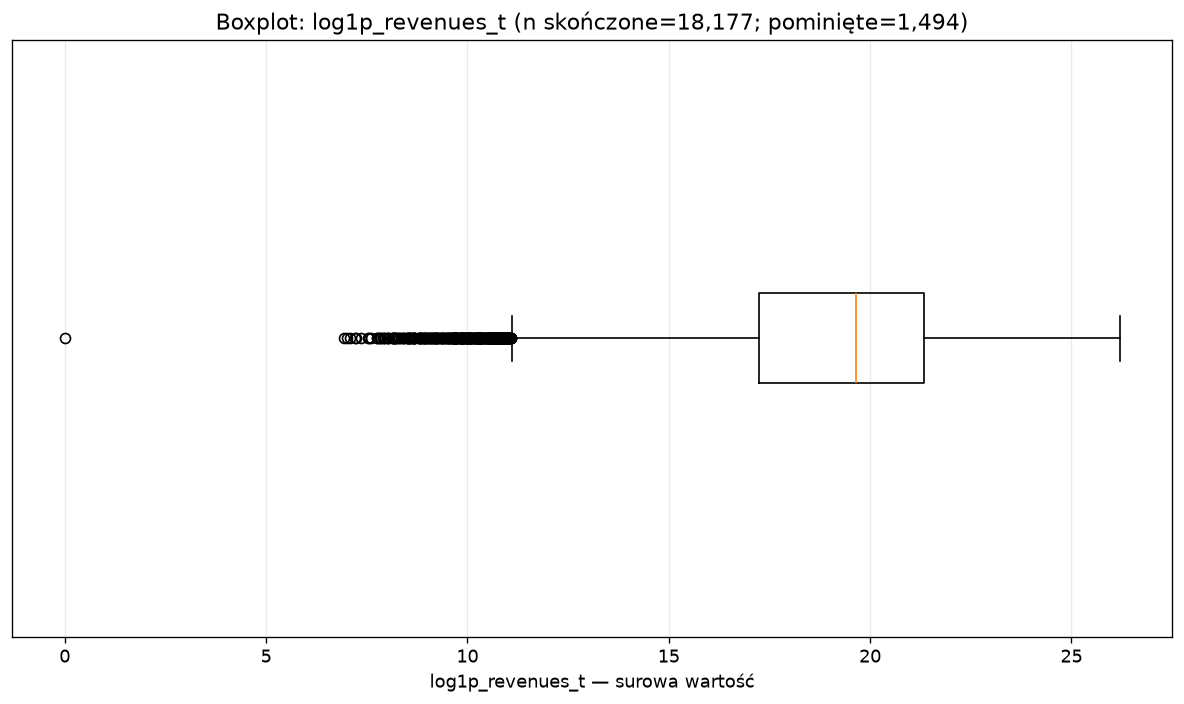

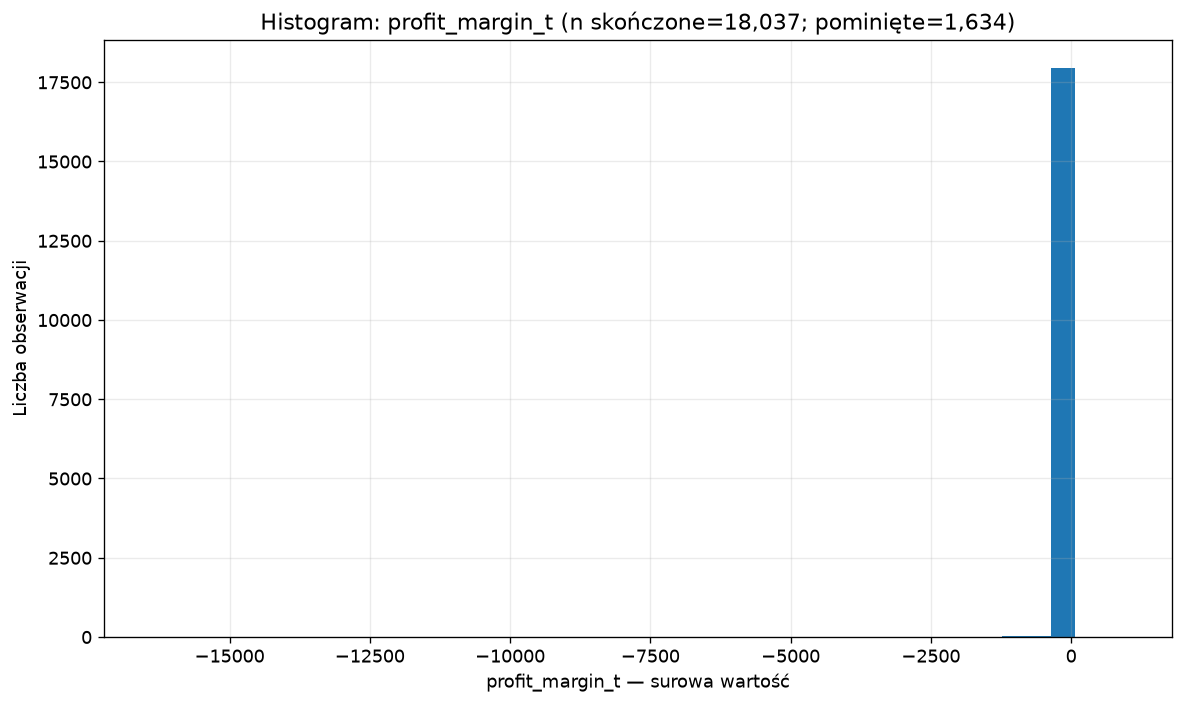

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


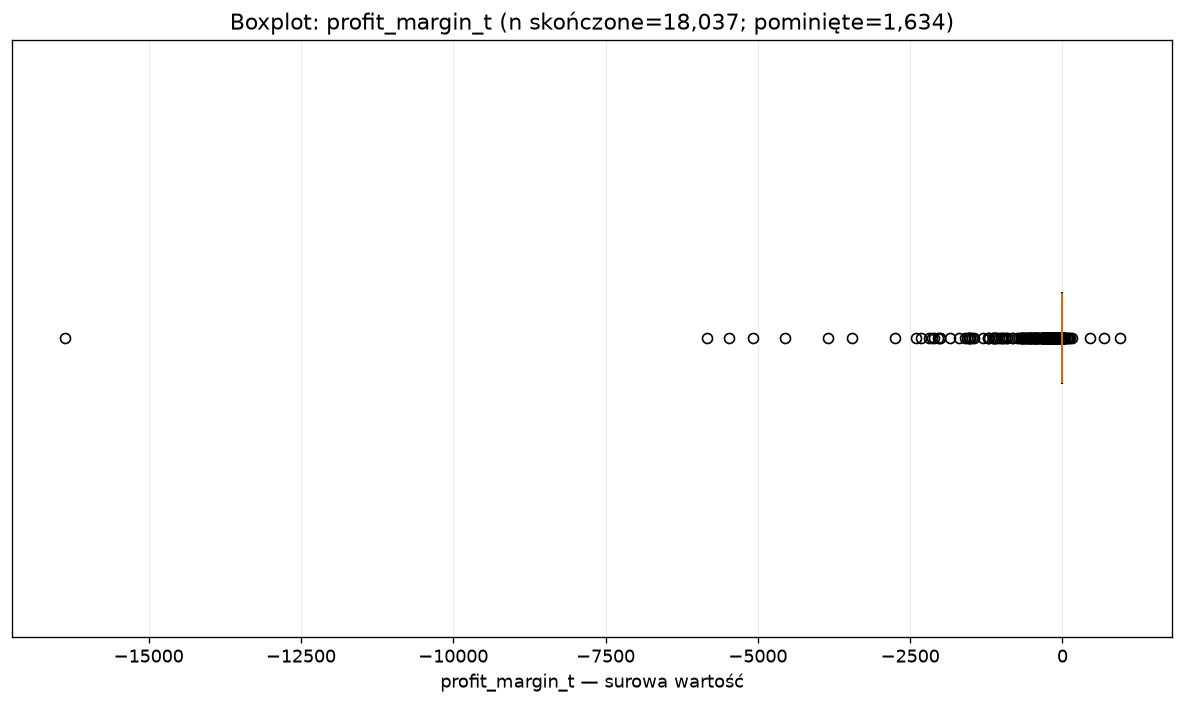

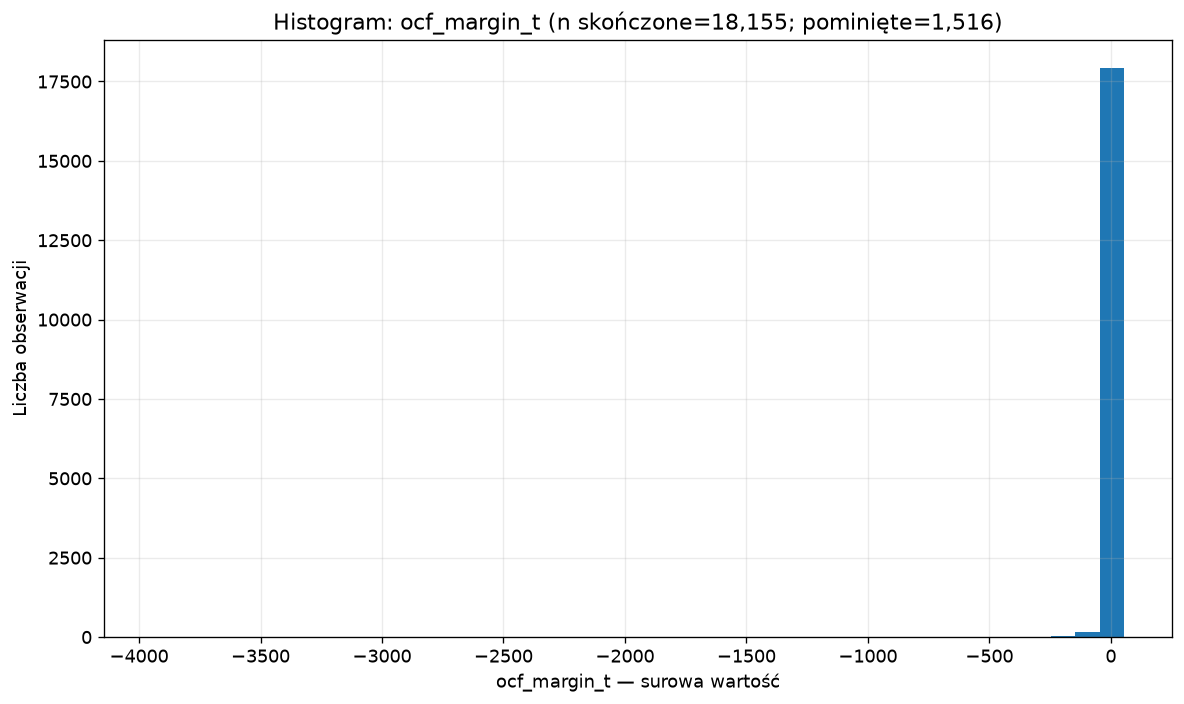

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


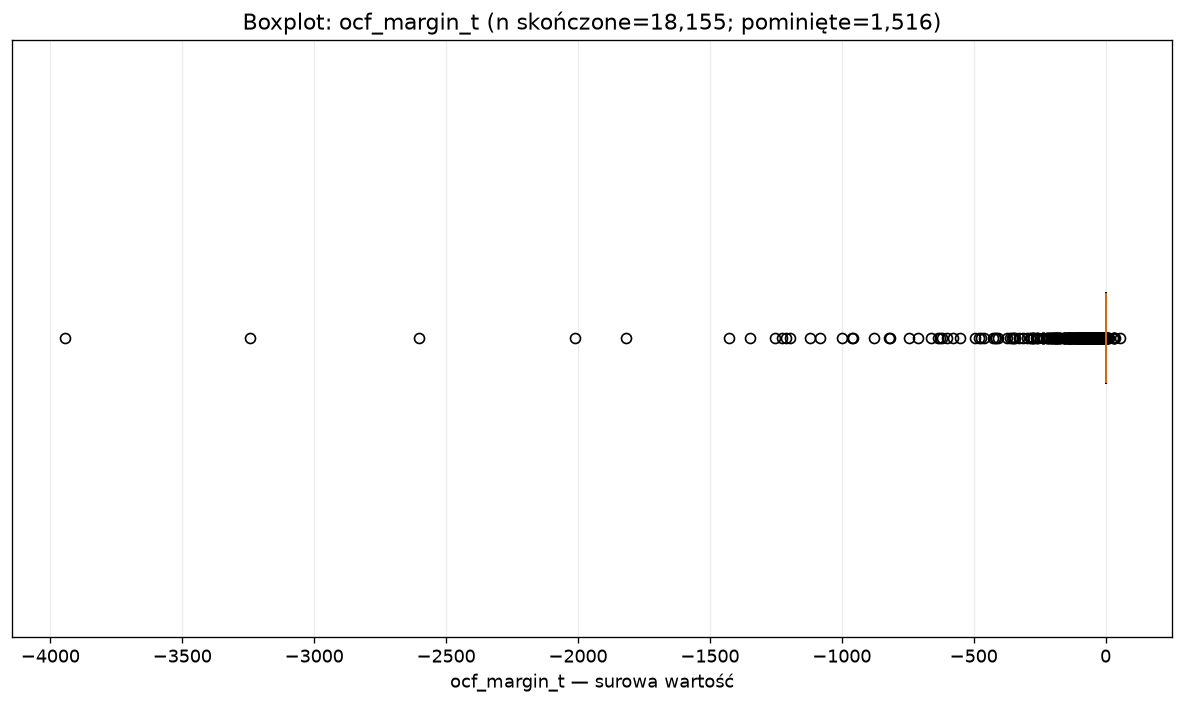

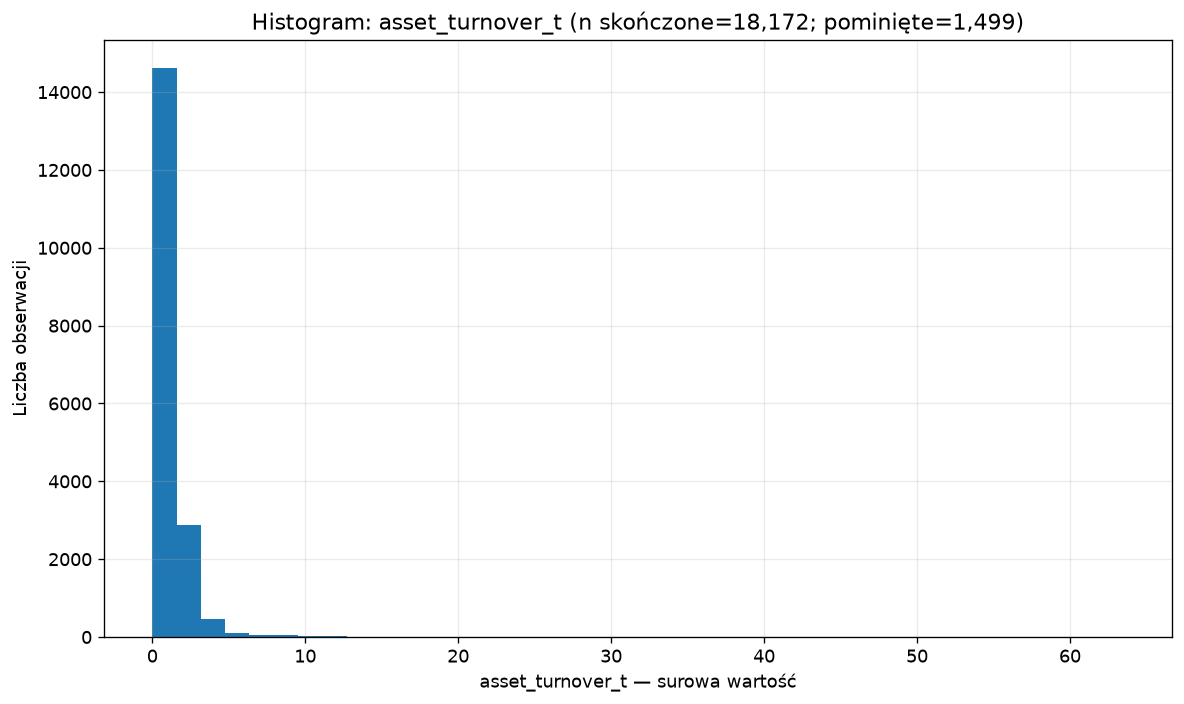

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


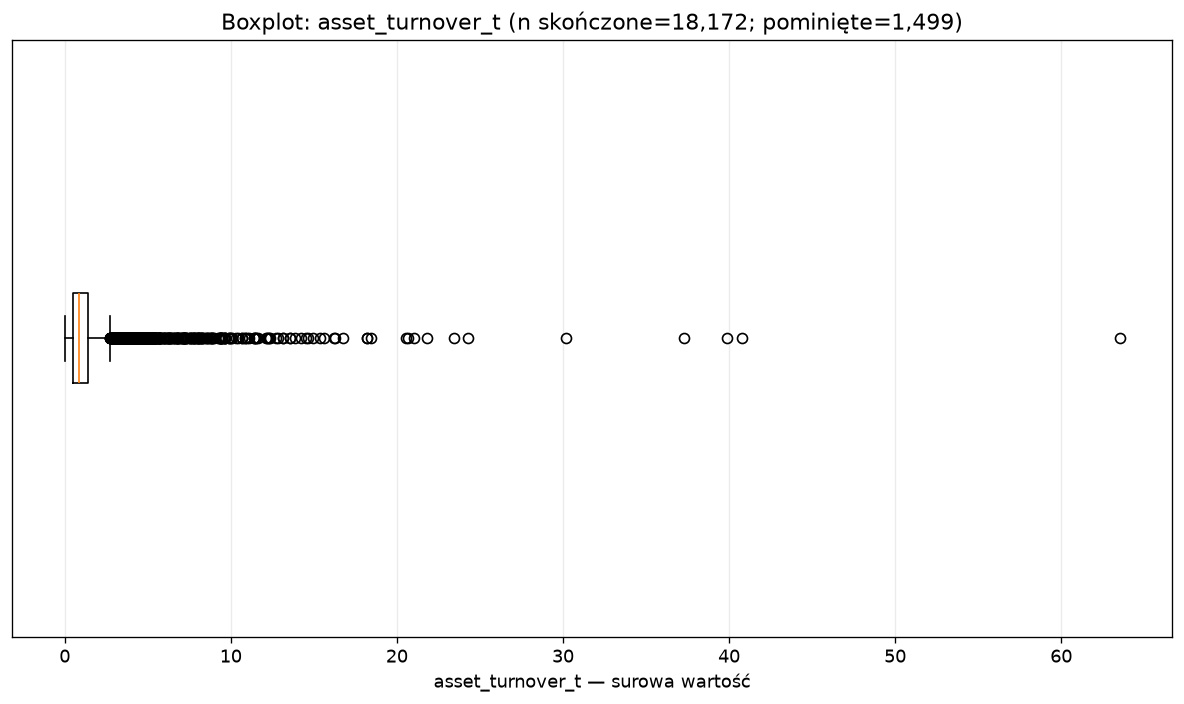

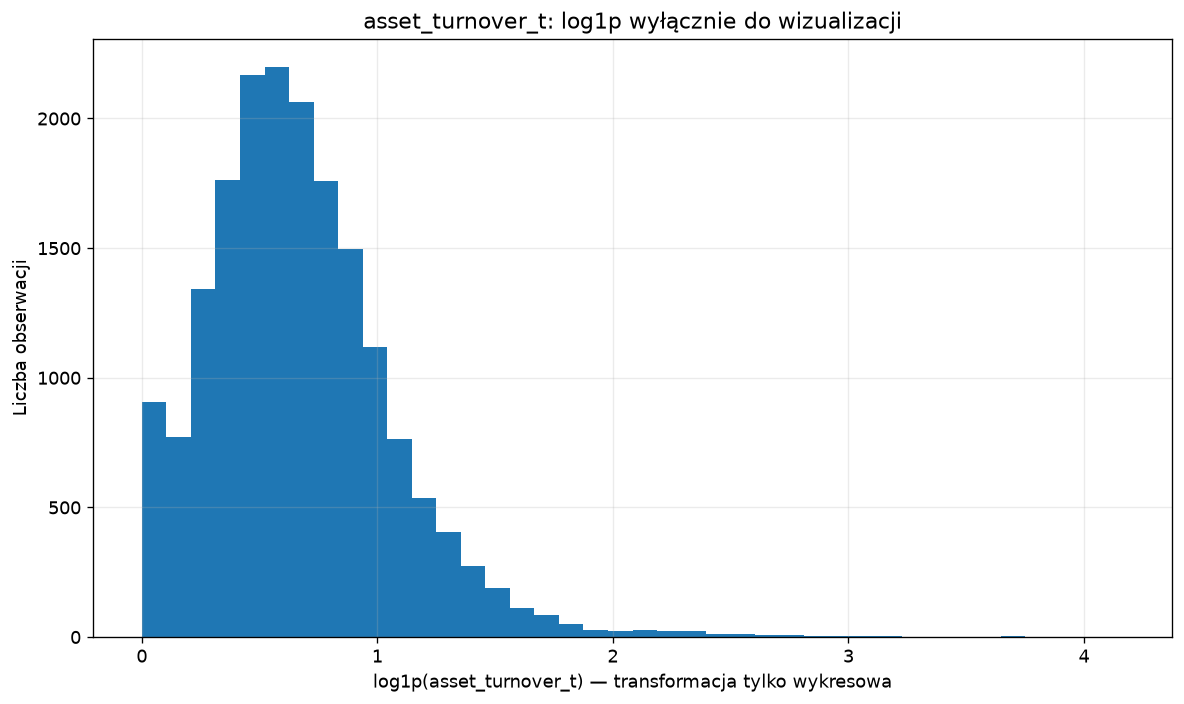

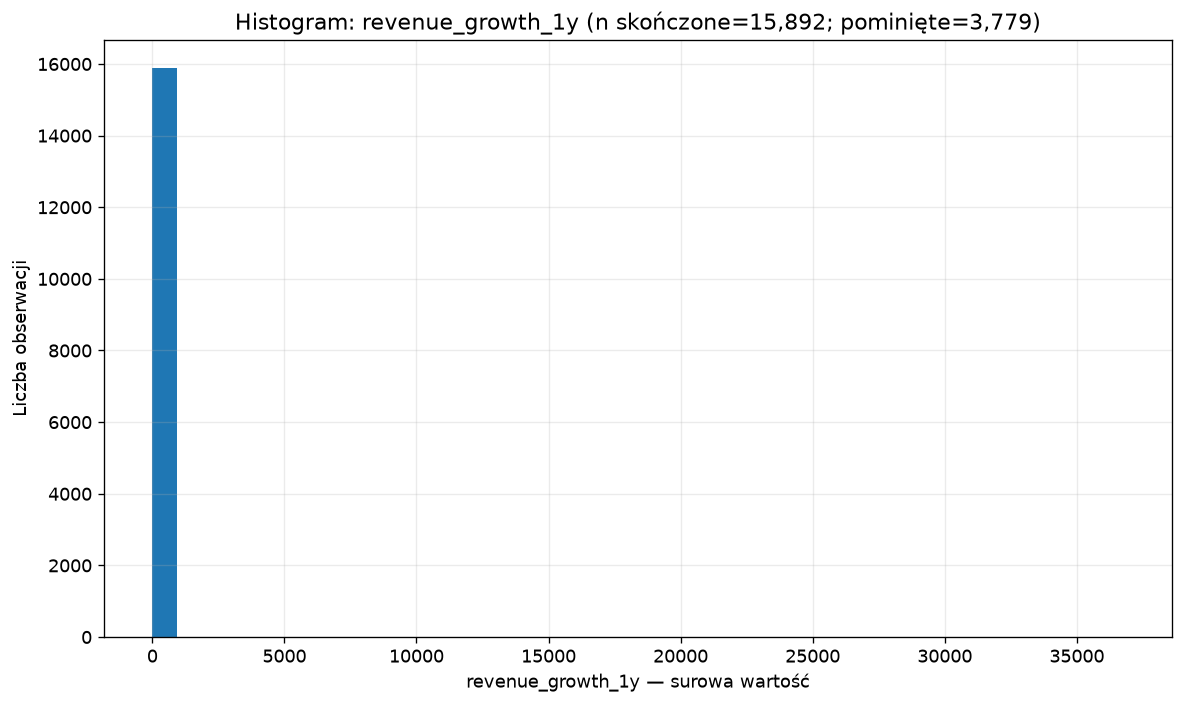

/var/folders/wp/y5rmm5lj5qz3_zbz6hfb1l000000gn/T/ipykernel_44252/4131023530.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(finite.to_numpy(), vert=False)


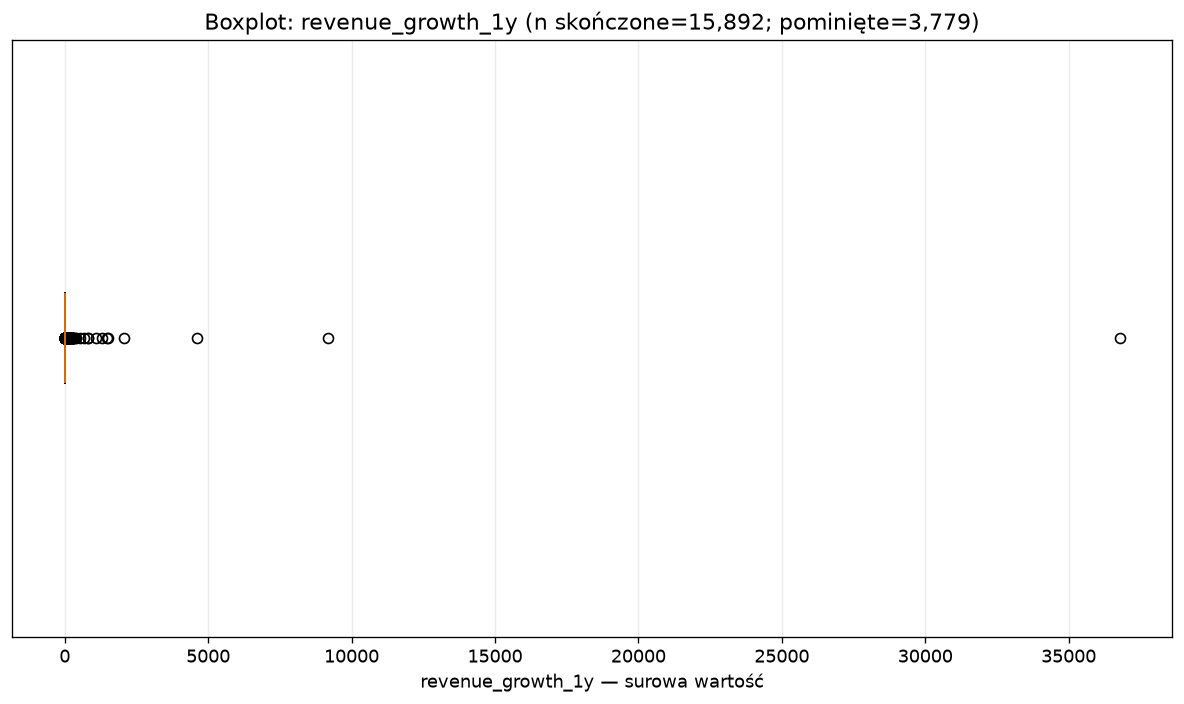

In [7]:
for feature in FEATURES:
    finite = finite_series(analysis_frame, feature)
    omitted_n = len(analysis_frame) - len(finite)

    fig, ax = plt.subplots()
    if finite.empty:
        ax.text(0.5, 0.5, "Brak skończonych wartości", ha="center", va="center")
    else:
        ax.hist(finite.to_numpy(), bins=40)
    ax.set_title(
        f"Histogram: {feature} (n skończone={len(finite):,}; pominięte={omitted_n:,})"
    )
    ax.set_xlabel(f"{feature} — surowa wartość")
    ax.set_ylabel("Liczba obserwacji")
    finalize_figure(fig, f"feature_hist_{slugify(feature)}.png")

    fig, ax = plt.subplots()
    if finite.empty:
        ax.text(0.5, 0.5, "Brak skończonych wartości", ha="center", va="center")
    else:
        ax.boxplot(finite.to_numpy(), vert=False)
    ax.set_title(
        f"Boxplot: {feature} (n skończone={len(finite):,}; pominięte={omitted_n:,})"
    )
    ax.set_xlabel(f"{feature} — surowa wartość")
    ax.set_yticks([])
    finalize_figure(fig, f"feature_box_{slugify(feature)}.png")

    skewness = descriptive_stats.loc[feature, "skewness"]
    if (
        not finite.empty
        and np.isfinite(skewness)
        and abs(skewness) >= 2.0
        and finite.min() >= 0.0
    ):
        fig, ax = plt.subplots()
        ax.hist(np.log1p(finite.to_numpy()), bins=40)
        ax.set_title(f"{feature}: log1p wyłącznie do wizualizacji")
        ax.set_xlabel(f"log1p({feature}) — transformacja tylko wykresowa")
        ax.set_ylabel("Liczba obserwacji")
        finalize_figure(fig, f"feature_hist_log1p_visual_{slugify(feature)}.png")


## 3.3. Porównanie `target=0` i `target=1`

SMD jest liczony jako różnica **średnich** podzielona przez łączne odchylenie standardowe grup, natomiast mediana i IQR pozostają podstawowymi miarami opisowymi. Cliff's delta ma znak dodatni, gdy wartości w klasie `target=1` mają tendencję do bycia większymi. Wyniki są wyłącznie opisowe: nie dowodzą przyczynowości, nie stanowią rankingu do usuwania cech i nie zmieniają zamrożonego zestawu zmiennych.


In [8]:
def standardized_mean_difference(group_1: np.ndarray, group_0: np.ndarray) -> float:
    if len(group_1) < 2 or len(group_0) < 2:
        return np.nan
    variance_1 = np.var(group_1, ddof=1)
    variance_0 = np.var(group_0, ddof=1)
    pooled_variance = (
        (len(group_1) - 1) * variance_1 + (len(group_0) - 1) * variance_0
    ) / (len(group_1) + len(group_0) - 2)
    if not np.isfinite(pooled_variance) or pooled_variance <= 0.0:
        return np.nan
    return float((np.mean(group_1) - np.mean(group_0)) / np.sqrt(pooled_variance))


def cliffs_delta(group_1: np.ndarray, group_0: np.ndarray) -> float:
    """Rank-based exact delta with average ranks for ties."""
    n1, n0 = len(group_1), len(group_0)
    if n1 == 0 or n0 == 0:
        return np.nan
    combined = np.concatenate([group_1, group_0])
    ranks = rankdata(combined, method="average")
    rank_sum_1 = float(ranks[:n1].sum())
    u1 = rank_sum_1 - n1 * (n1 + 1) / 2.0
    return float(2.0 * u1 / (n1 * n0) - 1.0)


def target_comparison_row(frame: pd.DataFrame, feature: str) -> dict:
    rows = {target: frame.loc[frame["target"].eq(target), feature] for target in (0, 1)}
    finite = {}
    for target, series in rows.items():
        values = pd.to_numeric(series, errors="raise").to_numpy(dtype=float)
        finite[target] = values[np.isfinite(values)]

    result = {"blok": FEATURE_TO_BLOCK[feature], "cecha": feature}
    for target in (0, 1):
        values = finite[target]
        q25 = float(np.quantile(values, 0.25)) if len(values) else np.nan
        q75 = float(np.quantile(values, 0.75)) if len(values) else np.nan
        result.update(
            {
                f"n_finite_target_{target}": len(values),
                f"n_pominiete_target_{target}": int(len(rows[target]) - len(values)),
                f"median_target_{target}": float(np.median(values)) if len(values) else np.nan,
                f"P25_target_{target}": q25,
                f"P75_target_{target}": q75,
                f"IQR_target_{target}": q75 - q25 if len(values) else np.nan,
            }
        )
    result["SMD_target1_minus_target0"] = standardized_mean_difference(
        finite[1], finite[0]
    )
    result["Cliffs_delta_target1_vs_target0"] = cliffs_delta(finite[1], finite[0])
    return result


target_comparison = pd.DataFrame(
    [target_comparison_row(analysis_frame, feature) for feature in FEATURES]
).set_index("cecha")
target_comparison = target_comparison.loc[FEATURES]

save_table(target_comparison, "19_target_0_vs_1_feature_comparison.csv")
show_table("Porównanie rozkładów cech między klasami", target_comparison)


#### Porównanie rozkładów cech między klasami

,blok,n_finite_target_0,n_pominiete_target_0,median_target_0,P25_target_0,P75_target_0,IQR_target_0,n_finite_target_1,n_pominiete_target_1,median_target_1,P25_target_1,P75_target_1,IQR_target_1,SMD_target1_minus_target0,Cliffs_delta_target1_vs_target0
cecha,,,,,,,,,,,,,,,
log_assets_t,L,16046,2,20.1784,18.1864,21.6798,3.4934,3620,3,17.6506,15.4392,19.5346,4.0954,-0.8324,-0.4498
roa_t,L,15715,333,0.0271,-0.0712,0.0714,0.1425,3546,77,-0.1433,-0.6880,0.0394,0.7274,-0.0047,-0.3241
ocf_to_assets_t,L,15812,236,0.0738,0.0037,0.1223,0.1185,3564,59,-0.0320,-0.3819,0.1033,0.4852,-0.0425,-0.2842
current_ratio_t,L,16002,46,1.9144,1.2369,3.0352,1.7983,3594,29,1.9722,0.7836,4.0810,3.2973,0.1571,-0.0064
liabilities_to_assets_t,L,16025,23,0.5412,0.3510,0.7332,0.3822,3612,11,0.5113,0.2677,0.9416,0.6739,0.0036,-0.0038
working_capital_to_assets_t,L,16002,46,0.2025,0.0538,0.3797,0.3258,3592,31,0.2272,-0.0701,0.5231,0.5932,-0.0027,0.0184
accruals_to_assets_t,L,15693,355,-0.0565,-0.1124,-0.0210,0.0914,3536,87,-0.1020,-0.2832,-0.0308,0.2524,-0.0012,-0.2131
asset_growth_1y,D,14183,1865,0.0479,-0.0385,0.1815,0.2200,3372,251,0.0403,-0.1303,0.3741,0.5044,-0.0106,-0.0188
delta_roa_1y,D,13848,2200,-0.0016,-0.0416,0.0310,0.0726,3259,364,0.0014,-0.1440,0.1884,0.3324,-0.0090,0.0334


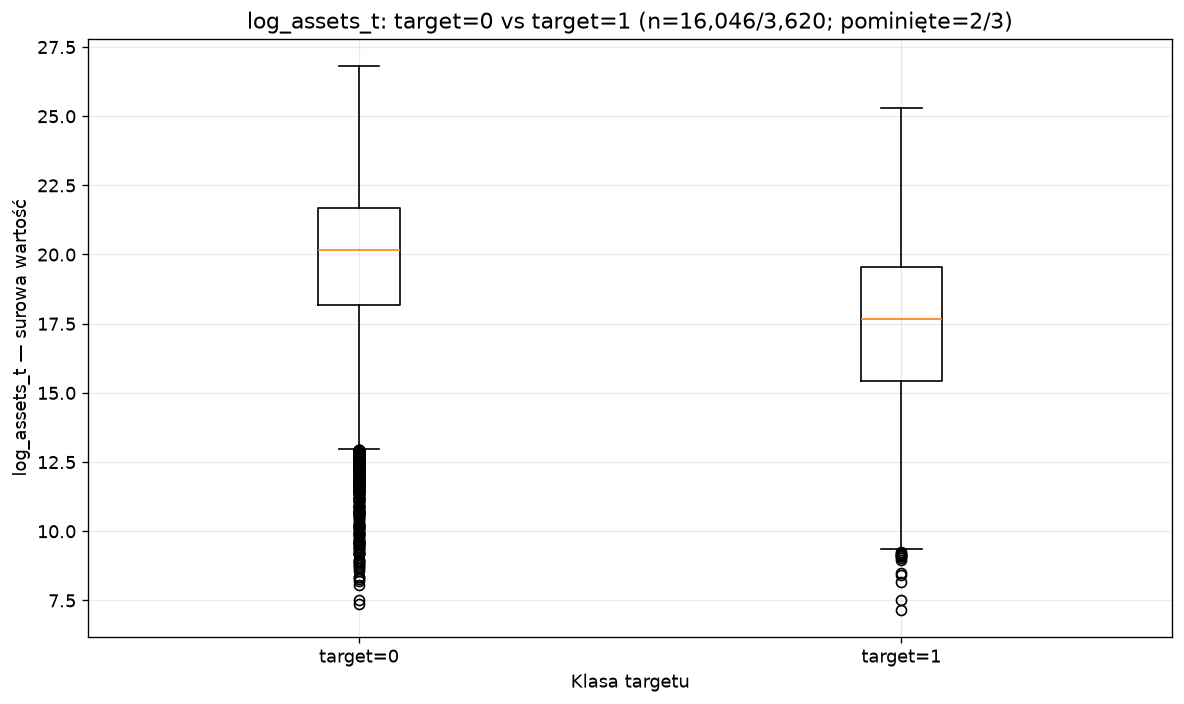

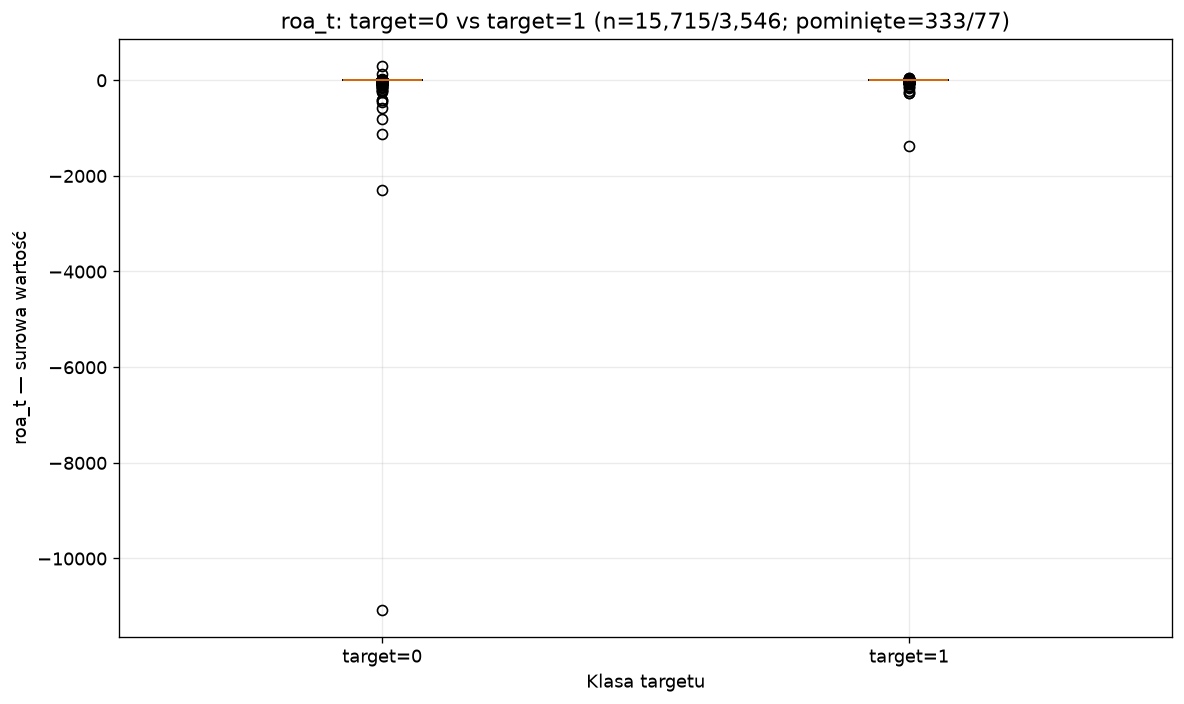

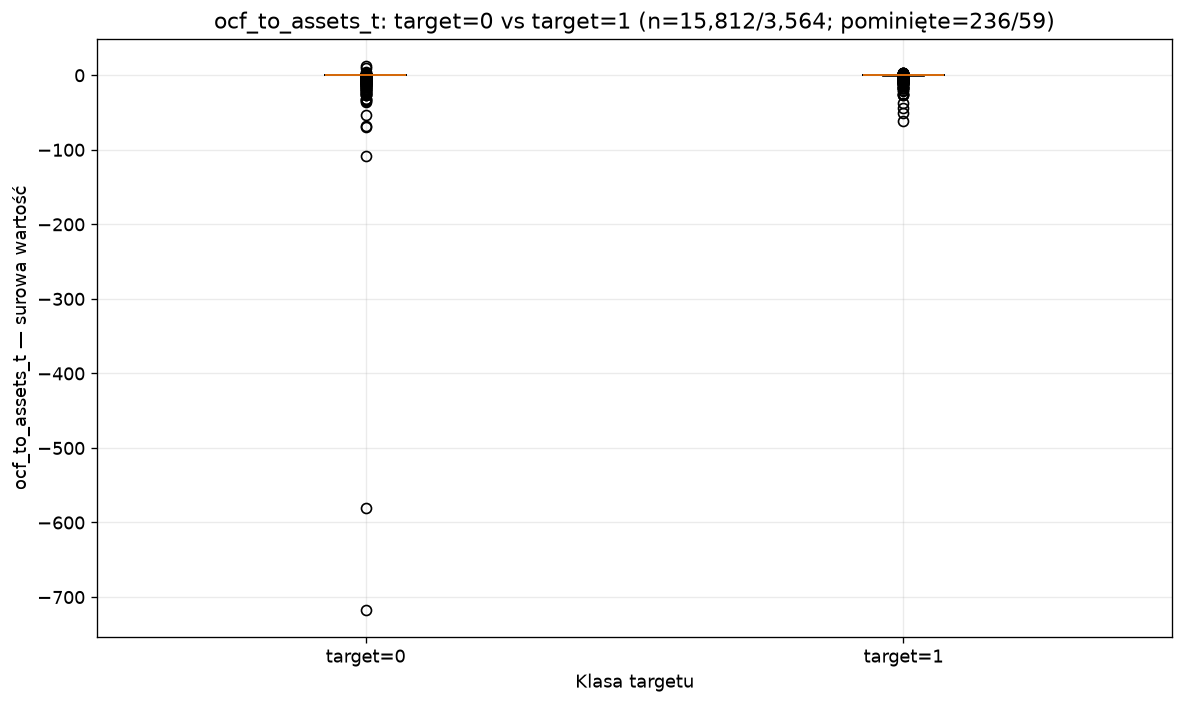

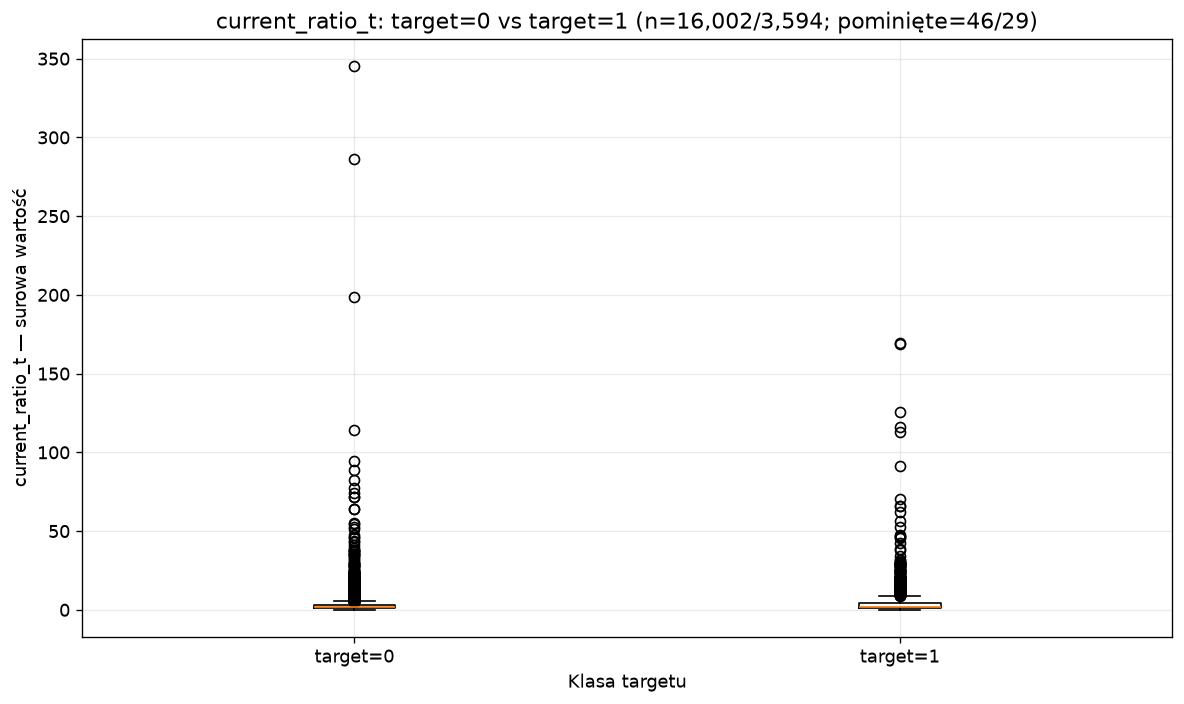

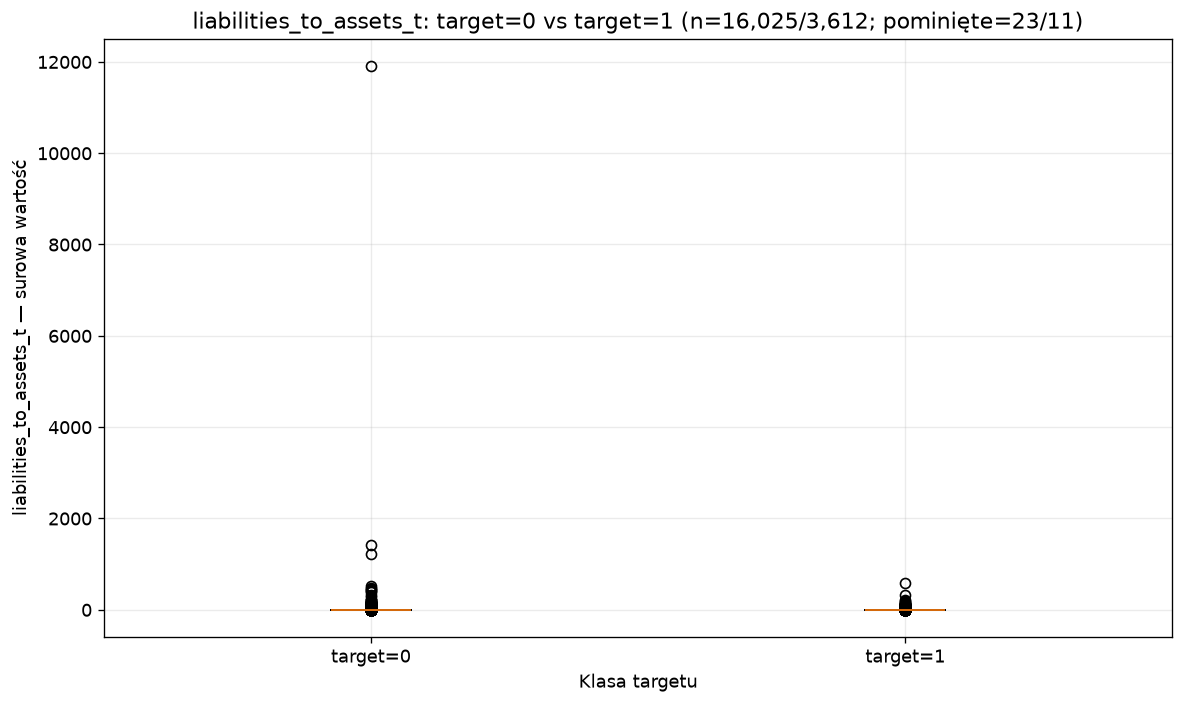

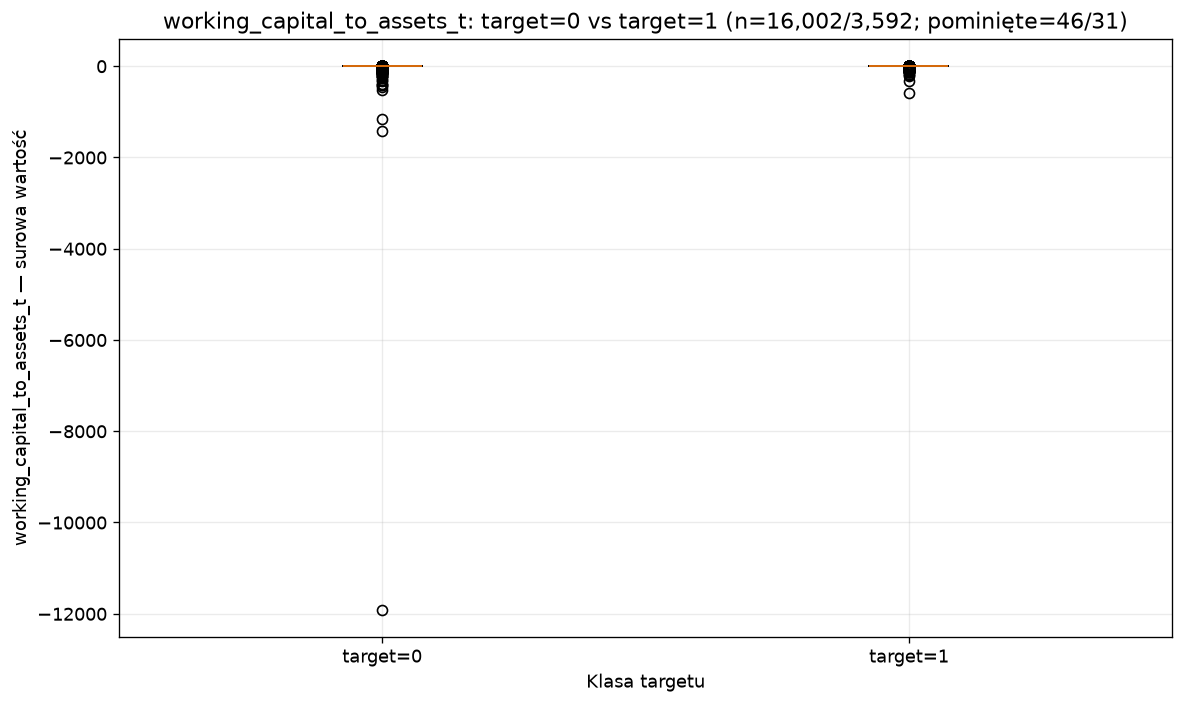

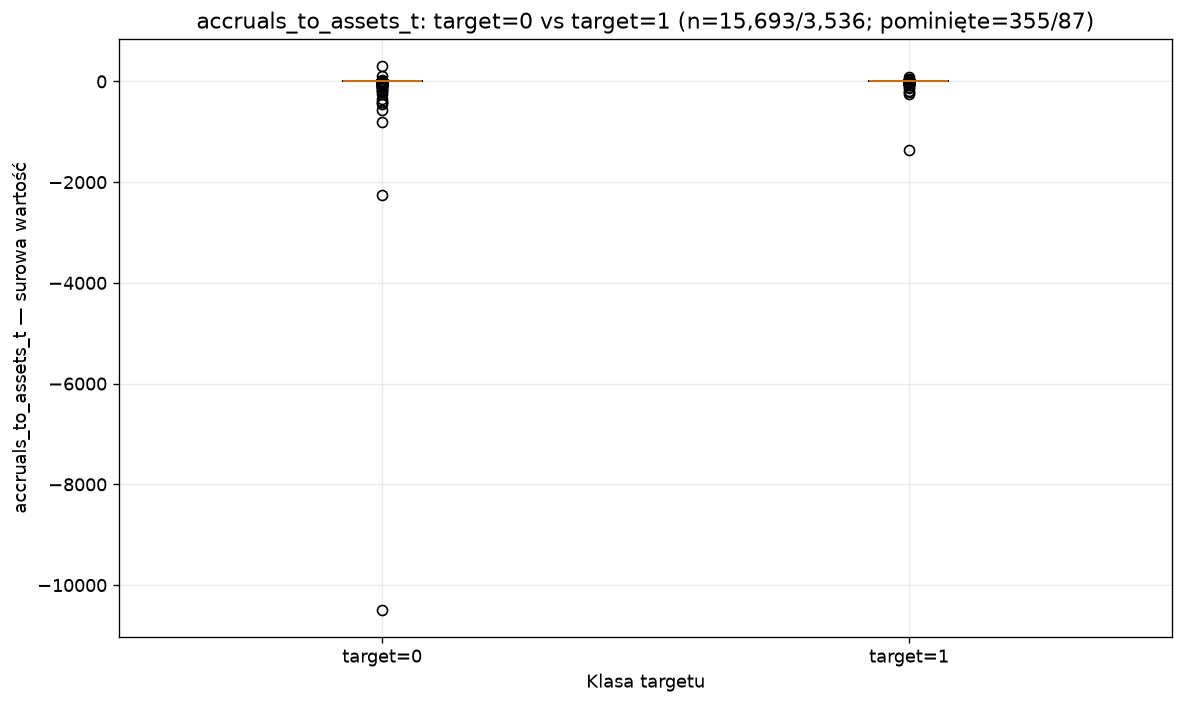

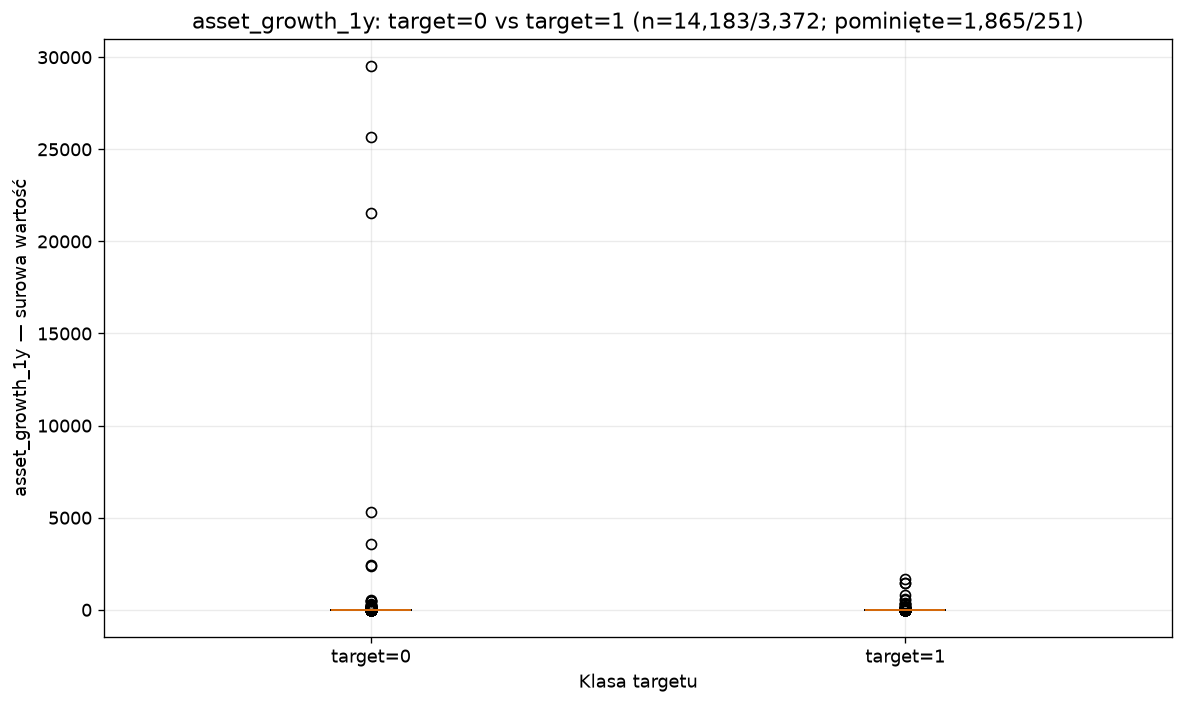

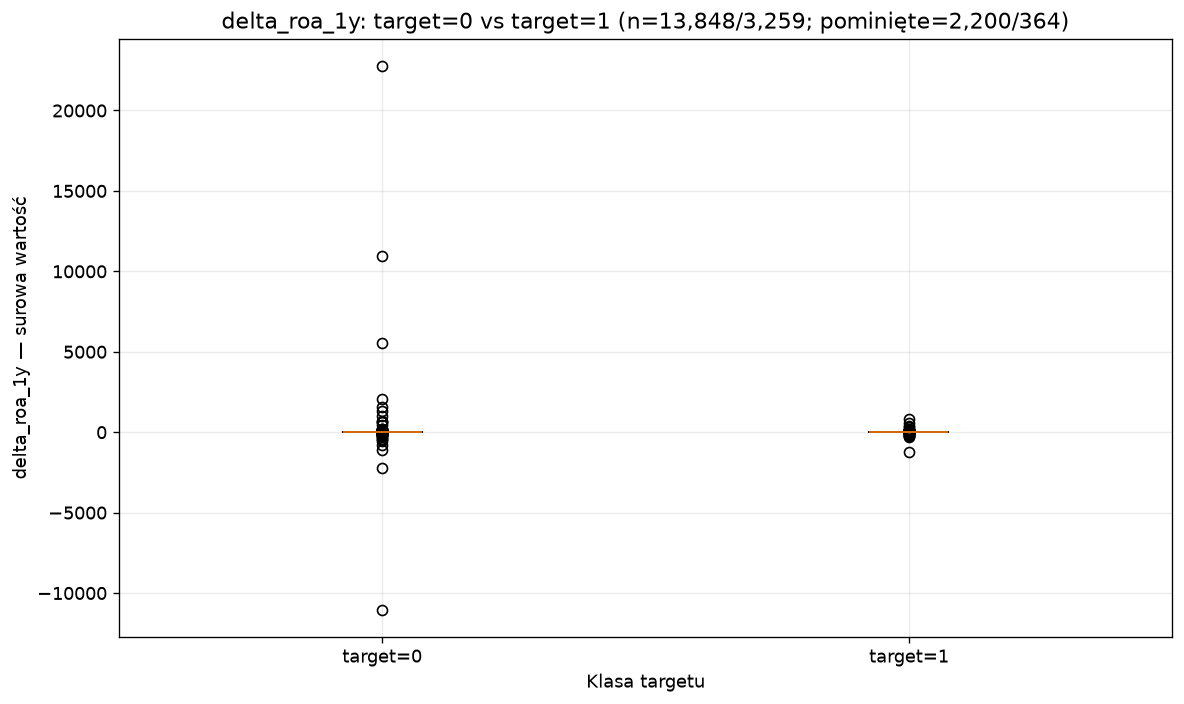

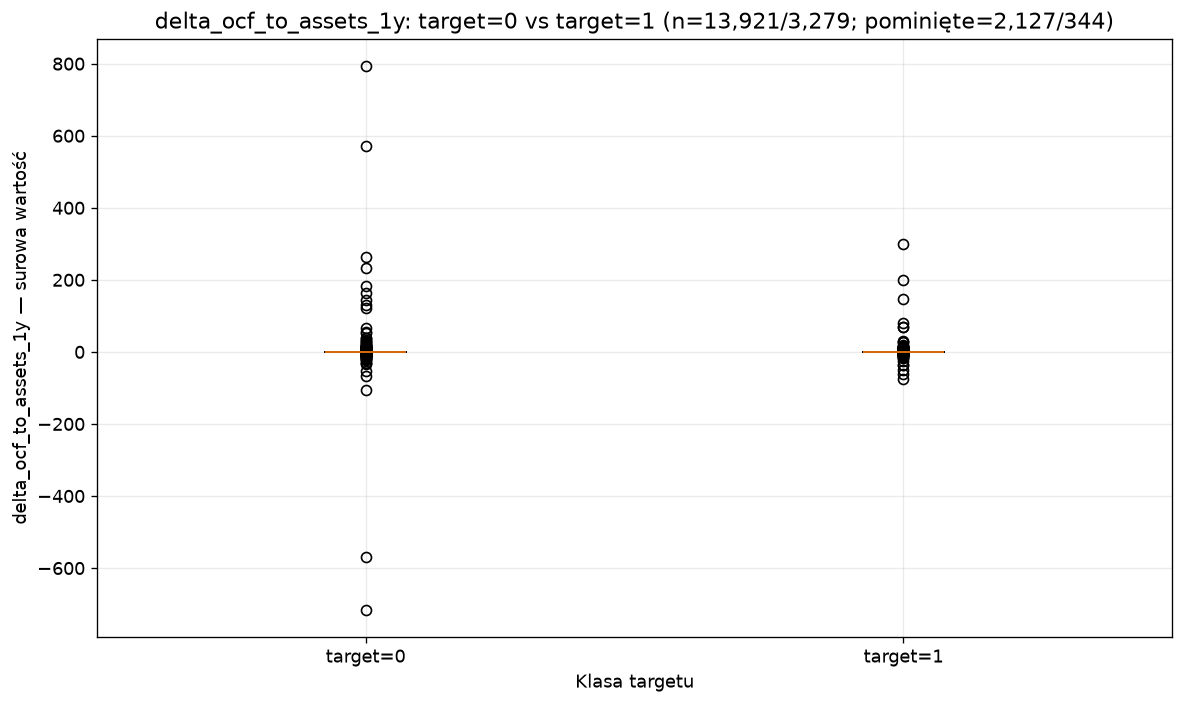

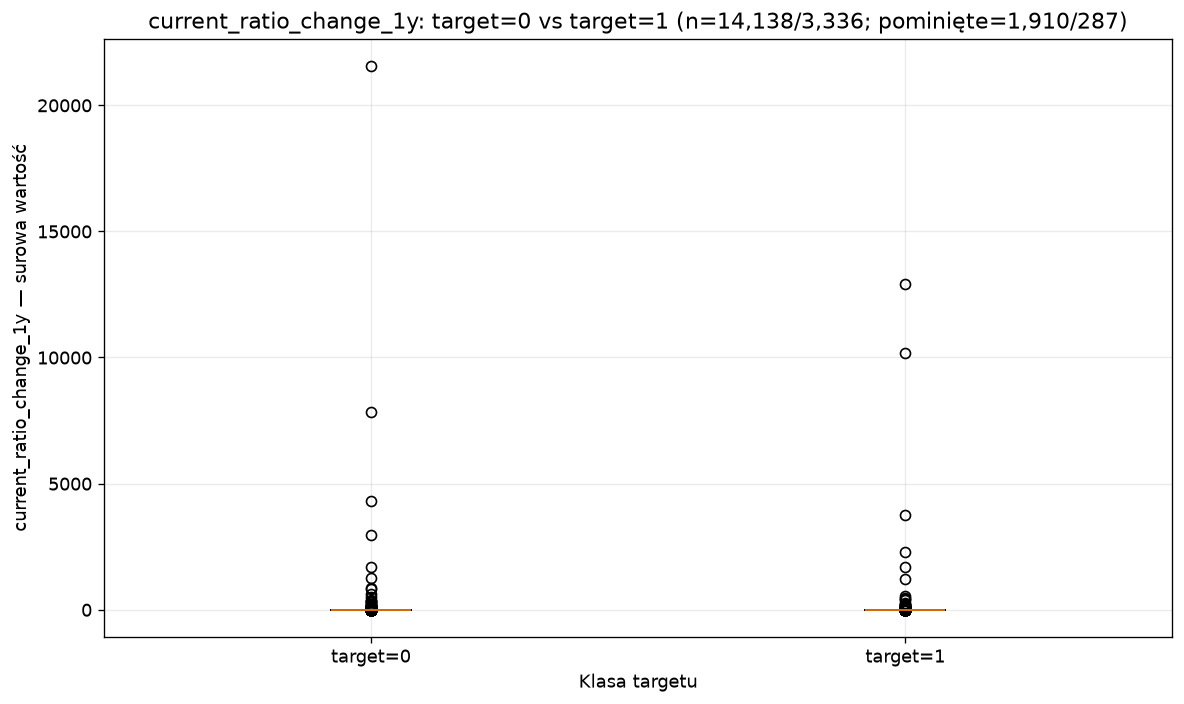

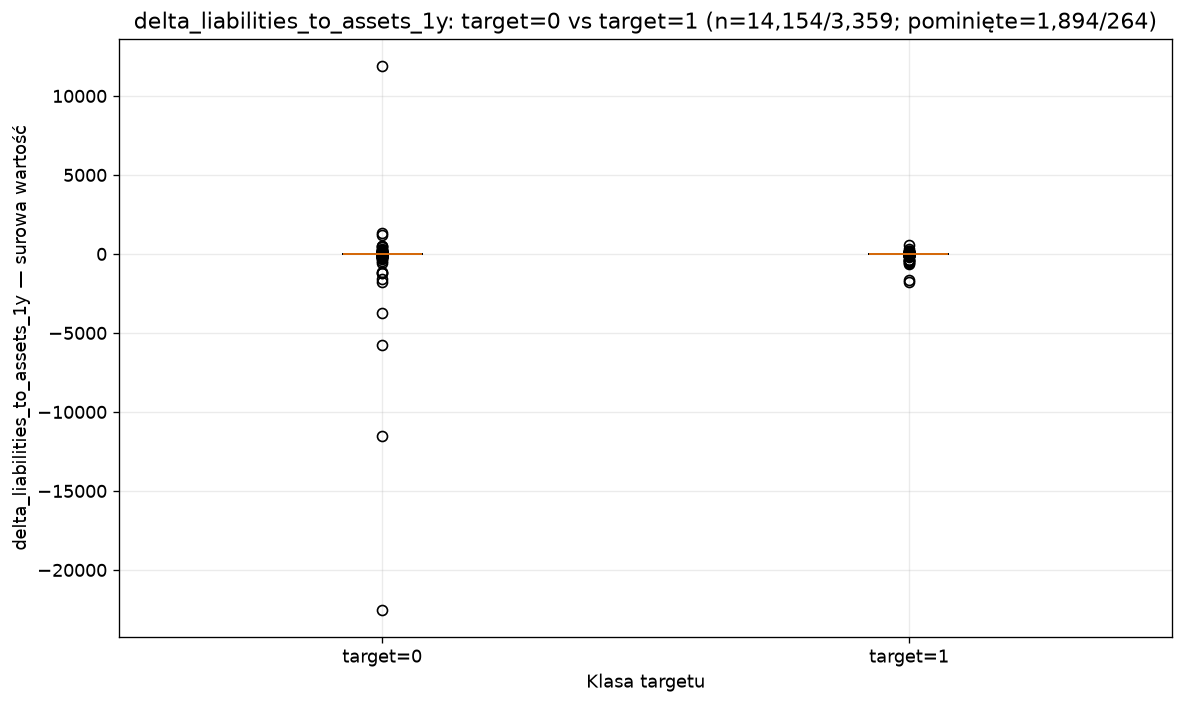

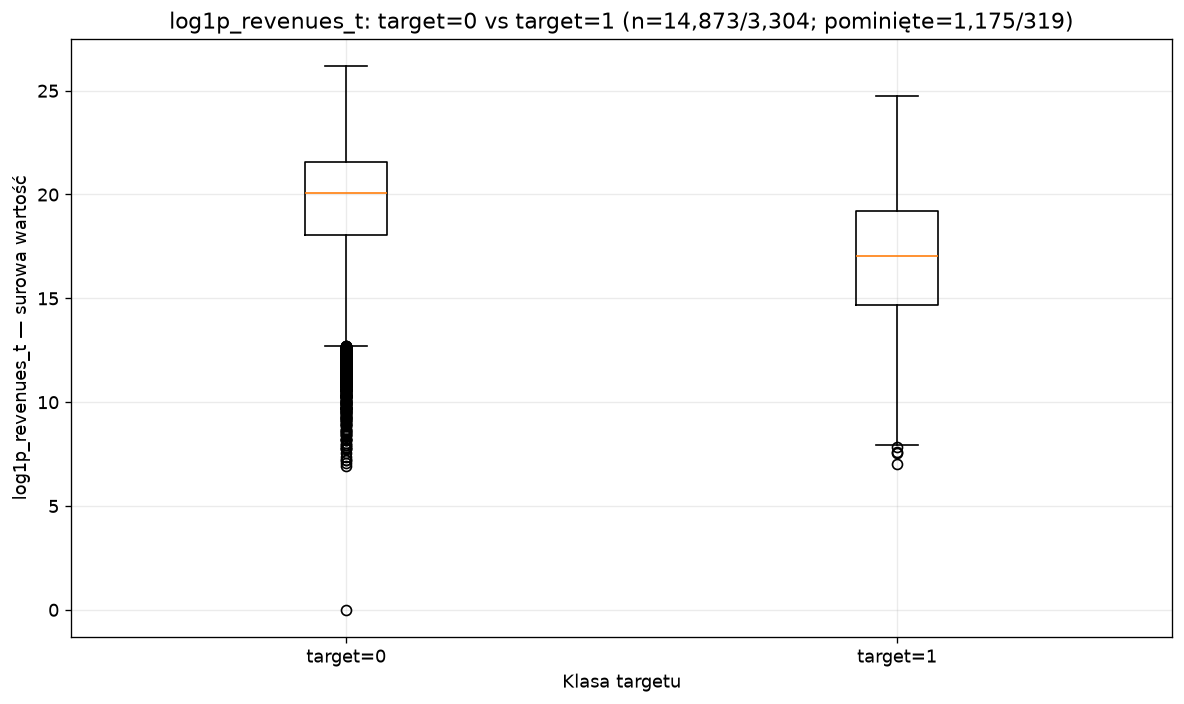

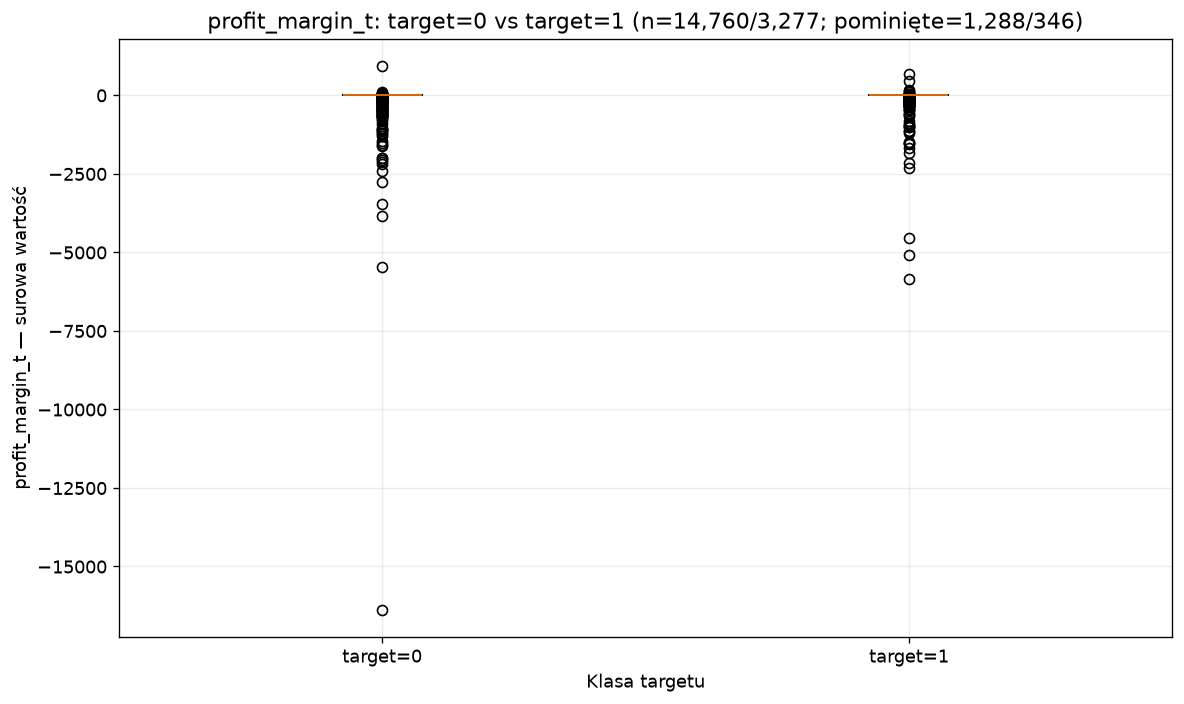

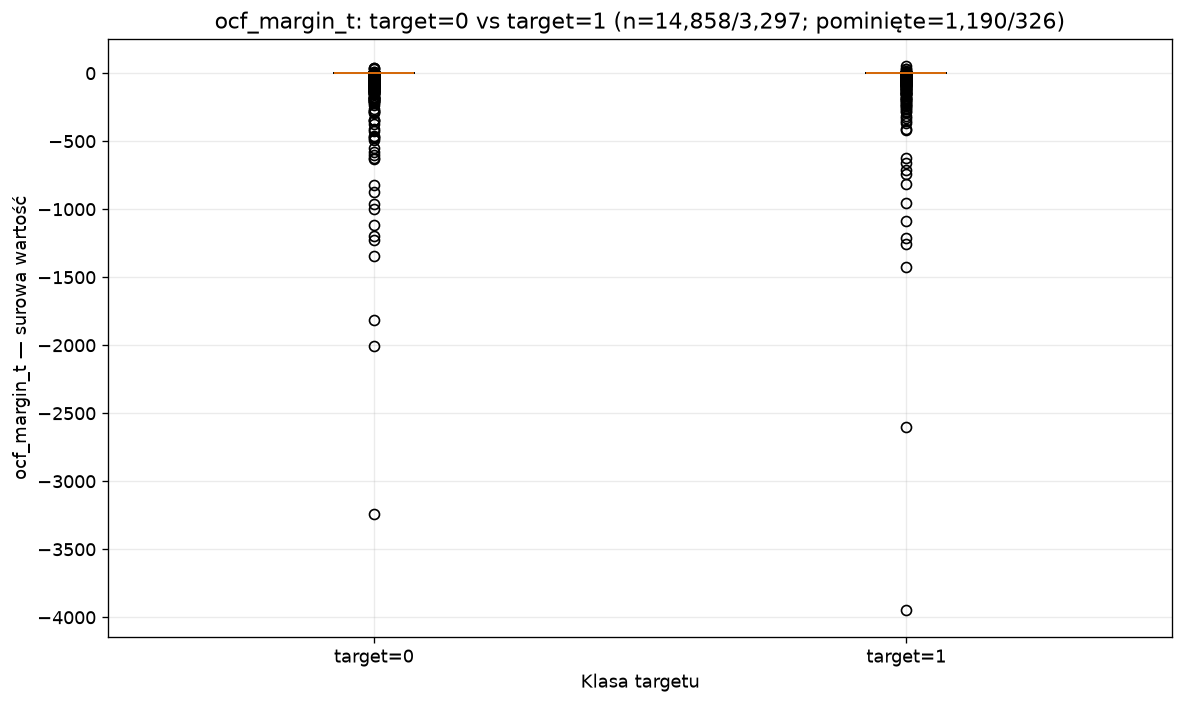

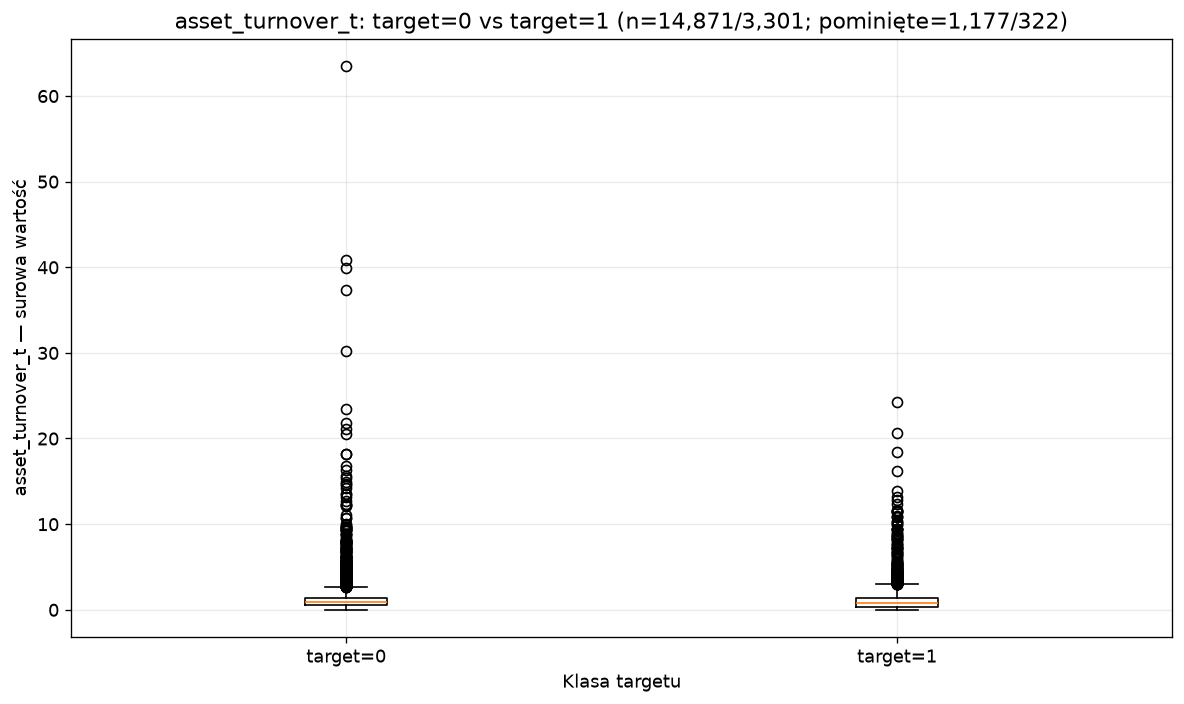

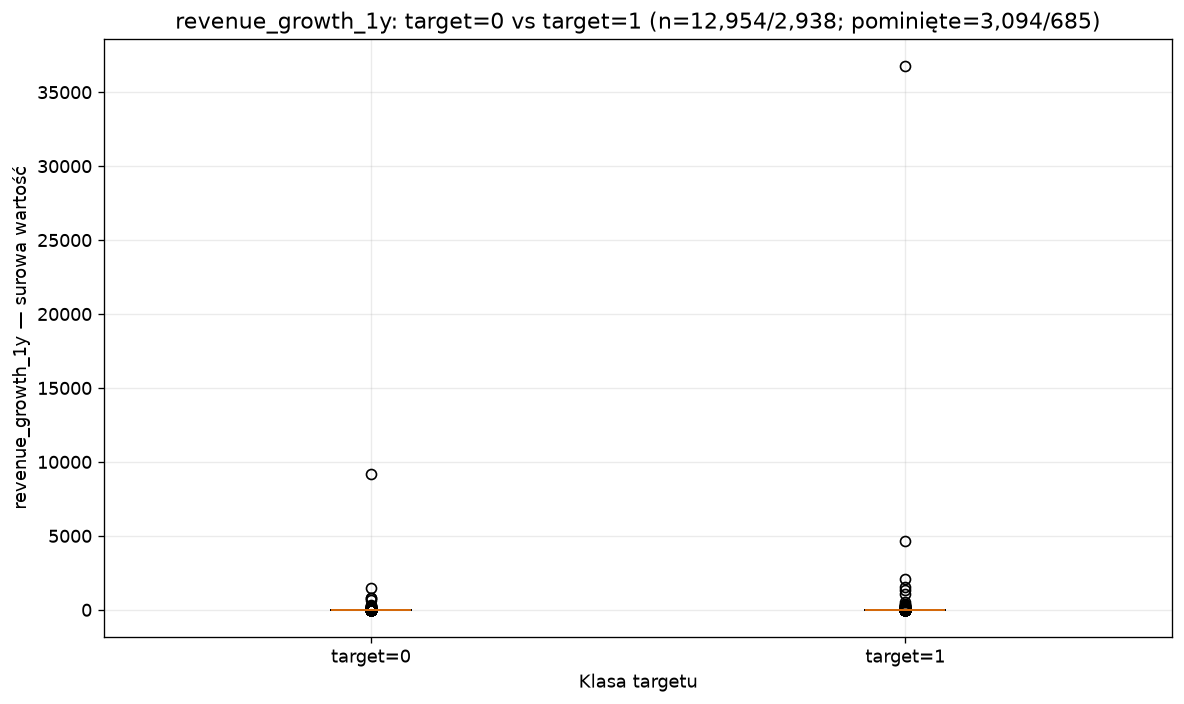

In [9]:
for feature in FEATURES:
    group_values = []
    finite_counts = []
    omitted_counts = []
    for target in (0, 1):
        raw = pd.to_numeric(
            analysis_frame.loc[analysis_frame["target"].eq(target), feature],
            errors="raise",
        )
        values = raw.to_numpy(dtype=float)
        finite = values[np.isfinite(values)]
        group_values.append(finite)
        finite_counts.append(len(finite))
        omitted_counts.append(len(raw) - len(finite))

    fig, ax = plt.subplots()
    if all(len(values) > 0 for values in group_values):
        ax.boxplot(group_values, tick_labels=["target=0", "target=1"])
    else:
        ax.text(0.5, 0.5, "Co najmniej jedna grupa bez skończonych wartości", ha="center")
    ax.set_title(
        f"{feature}: target=0 vs target=1 "
        f"(n={finite_counts[0]:,}/{finite_counts[1]:,}; "
        f"pominięte={omitted_counts[0]:,}/{omitted_counts[1]:,})"
    )
    ax.set_xlabel("Klasa targetu")
    ax.set_ylabel(f"{feature} — surowa wartość")
    finalize_figure(fig, f"target_box_{slugify(feature)}.png")


## 3.4. Missingness

Brak jest definiowany jako `NaN` w surowej cesze. Wartości `+inf/-inf` są problemem jakości danych raportowanym osobno, a nie brakami. Żadna wartość nie jest imputowana w tej sekcji. Macierz współwystępowania pokazuje zarówno liczbę wspólnych braków, jak i ich podobieństwo Jaccarda.


In [10]:
missing_indicator = analysis_frame[FEATURES].isna()
available_feature_count = (~missing_indicator).sum(axis=1)

feature_missingness = pd.DataFrame(
    {
        "blok": [FEATURE_TO_BLOCK[feature] for feature in FEATURES],
        "n": len(analysis_frame),
        "n_missing": missing_indicator.sum(axis=0).reindex(FEATURES).astype(int),
        "missingness_pct": 100.0 * missing_indicator.mean(axis=0).reindex(FEATURES),
        "n_available": (~missing_indicator).sum(axis=0).reindex(FEATURES).astype(int),
    },
    index=FEATURES,
)
feature_missingness.index.name = "cecha"


def grouped_missingness(frame: pd.DataFrame, group_column: str) -> pd.DataFrame:
    working = frame.copy()
    working["_group"] = working[group_column].astype("string").fillna("Brak danych")
    rows = []
    for group, subset in working.groupby("_group", dropna=False, sort=True):
        miss = subset[FEATURES].isna()
        row = {
            group_column: group,
            "n": len(subset),
            "missing_all_feature_cells_pct": 100.0 * miss.to_numpy().mean(),
            "available_features_mean": float((~miss).sum(axis=1).mean()),
            "available_features_median": float((~miss).sum(axis=1).median()),
        }
        for feature in FEATURES:
            row[f"{feature}__missing_pct"] = 100.0 * miss[feature].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index(group_column)


missing_by_year = grouped_missingness(analysis_frame, "feature_year")
missing_by_sector = grouped_missingness(analysis_frame, "research_sector")
missing_by_size = grouped_missingness(analysis_frame, "size_quartile")
missing_by_target = grouped_missingness(analysis_frame, "target")
missing_by_x_t_status = grouped_missingness(analysis_frame, "x_t_status")
missing_by_xbrl = grouped_missingness(analysis_frame, "xbrl_status")

missing_counts = missing_indicator.astype(int).T.dot(missing_indicator.astype(int))
missing_counts.index.name = "cecha_1"
missing_counts.columns.name = "cecha_2"
missing_per_feature = missing_indicator.sum(axis=0).astype(float)
missing_union = (
    missing_per_feature.to_numpy()[:, None]
    + missing_per_feature.to_numpy()[None, :]
    - missing_counts.to_numpy(dtype=float)
)
missing_jaccard_values = np.divide(
    missing_counts.to_numpy(dtype=float),
    missing_union,
    out=np.zeros_like(missing_union, dtype=float),
    where=missing_union > 0,
)
missing_jaccard = pd.DataFrame(
    missing_jaccard_values,
    index=FEATURES,
    columns=FEATURES,
)

available_count_distribution = (
    available_feature_count.value_counts()
    .sort_index()
    .rename("n_obserwacji")
    .to_frame()
)
available_count_distribution["udzial_pct"] = (
    100.0 * available_count_distribution["n_obserwacji"] / len(analysis_frame)
)
available_count_distribution.index.name = "liczba_dostepnych_cech"

for filename, table in {
    "20_feature_missingness.csv": feature_missingness,
    "21_missingness_by_year.csv": missing_by_year,
    "22_missingness_by_sector.csv": missing_by_sector,
    "23_missingness_by_size.csv": missing_by_size,
    "24_missingness_by_target.csv": missing_by_target,
    "25_missingness_by_x_t_status.csv": missing_by_x_t_status,
    "26_missingness_by_xbrl_status.csv": missing_by_xbrl,
    "27_missing_cooccurrence_counts.csv": missing_counts,
    "28_missing_cooccurrence_jaccard.csv": missing_jaccard,
    "29_available_feature_count_distribution.csv": available_count_distribution,
}.items():
    save_table(table, filename)

show_table("Missingness według cechy", feature_missingness)
show_table("Missingness według roku", missing_by_year)
show_table("Missingness według sektora", missing_by_sector)
show_table("Missingness według wielkości spółki", missing_by_size)
show_table("Missingness według targetu", missing_by_target)
show_table("Missingness według statusu XBRL", missing_by_xbrl)
show_table("Rozkład liczby dostępnych cech na obserwację", available_count_distribution)


#### Missingness według cechy

,blok,n,n_missing,missingness_pct,n_available
cecha,,,,,
log_assets_t,L,19671,5,0.0254,19666
roa_t,L,19671,410,2.0843,19261
ocf_to_assets_t,L,19671,295,1.4997,19376
current_ratio_t,L,19671,75,0.3813,19596
liabilities_to_assets_t,L,19671,34,0.1728,19637
working_capital_to_assets_t,L,19671,77,0.3914,19594
accruals_to_assets_t,L,19671,442,2.2470,19229
asset_growth_1y,D,19671,2116,10.7570,17555
delta_roa_1y,D,19671,2564,13.0344,17107


#### Missingness według roku

,n,missing_all_feature_cells_pct,available_features_mean,available_features_median,log_assets_t__missing_pct,roa_t__missing_pct,ocf_to_assets_t__missing_pct,current_ratio_t__missing_pct,liabilities_to_assets_t__missing_pct,working_capital_to_assets_t__missing_pct,accruals_to_assets_t__missing_pct,asset_growth_1y__missing_pct,delta_roa_1y__missing_pct,delta_ocf_to_assets_1y__missing_pct,current_ratio_change_1y__missing_pct,delta_liabilities_to_assets_1y__missing_pct,log1p_revenues_t__missing_pct,profit_margin_t__missing_pct,ocf_margin_t__missing_pct,asset_turnover_t__missing_pct,revenue_growth_1y__missing_pct
feature_year,,,,,,,,,,,,,,,,,,,,,
2011,1907,2.2240,16.6219,17.0000,0.0524,0.7866,0.4719,0.4719,0.2622,0.4719,0.9963,0.2622,1.5732,1.1536,0.7341,0.4719,5.6109,6.1353,5.7682,5.6633,6.9219
2012,2311,10.9400,15.1402,17.0000,0.0000,9.5630,9.0437,0.6491,0.1731,0.6491,9.8659,14.7122,15.9238,15.4911,15.2748,14.8853,14.4093,15.1450,14.5392,14.4093,21.2462
2013,2393,7.9054,15.6561,17.0000,0.0418,1.6715,0.8776,0.4179,0.1672,0.4179,1.8805,11.8679,18.0527,17.4258,12.2440,12.0351,7.9816,8.9427,8.1070,8.0234,24.2374
2014,2300,6.1944,15.9470,17.0000,0.0435,1.2174,0.6087,0.5217,0.3478,0.5652,1.2609,11.6957,13.5652,13.0435,12.3043,12.0870,4.8696,5.4783,4.9130,4.9130,17.8696
2015,2241,5.9611,15.9866,17.0000,0.0446,0.8478,0.6693,0.3570,0.1785,0.3570,0.9371,10.6203,12.6283,12.4498,11.2450,10.9326,5.3994,5.6225,5.4440,5.4440,18.1615
2016,2133,6.3208,15.9255,17.0000,0.0000,2.0159,0.3282,0.0938,0.0469,0.0938,2.2972,12.0956,14.9555,13.5021,12.1894,12.2363,4.2663,6.1416,4.4538,4.2663,18.4716
2017,1549,5.9127,15.9948,17.0000,0.0000,0.8393,0.2582,0.1937,0.1291,0.1937,0.9684,9.5546,11.2976,10.9748,9.6837,9.6837,6.9722,7.6824,7.0368,6.9722,18.0762
2018,1511,7.3189,15.7558,17.0000,0.0000,0.3309,0.1985,0.3971,0.1985,0.3971,0.3309,10.7876,12.5745,12.5745,11.3170,11.0523,10.1919,10.3243,10.2581,10.1919,23.2958
2019,1638,7.7893,15.6758,17.0000,0.0000,1.1600,0.4884,0.3663,0.0611,0.3663,1.2821,12.5153,14.0415,13.6142,12.9426,12.7595,9.6459,10.4396,9.7680,9.6459,23.3211


#### Missingness według sektora

...

,n,missing_all_feature_cells_pct,available_features_mean,available_features_median,log_assets_t__missing_pct,roa_t__missing_pct,ocf_to_assets_t__missing_pct,current_ratio_t__missing_pct,liabilities_to_assets_t__missing_pct,working_capital_to_assets_t__missing_pct,accruals_to_assets_t__missing_pct,asset_growth_1y__missing_pct,delta_roa_1y__missing_pct,delta_ocf_to_assets_1y__missing_pct,current_ratio_change_1y__missing_pct,delta_liabilities_to_assets_1y__missing_pct,log1p_revenues_t__missing_pct,profit_margin_t__missing_pct,ocf_margin_t__missing_pct,asset_turnover_t__missing_pct,revenue_growth_1y__missing_pct
target,,,,,,,,,,,,,,,,,,,,,
0,16048,6.9501,15.8185,17.0000,0.0125,2.0750,1.4706,0.2866,0.1433,0.2866,2.2121,11.6214,13.7089,13.2540,11.9018,11.8021,7.3218,8.0259,7.4153,7.3342,19.2797
1,3623,6.1779,15.9498,17.0000,0.0828,2.1253,1.6285,0.8004,0.3036,0.8556,2.4013,6.9280,10.0469,9.4949,7.9216,7.2868,8.8049,9.5501,8.9981,8.8877,18.9070


#### Missingness według statusu XBRL

,n,missing_all_feature_cells_pct,available_features_mean,available_features_median,log_assets_t__missing_pct,roa_t__missing_pct,ocf_to_assets_t__missing_pct,current_ratio_t__missing_pct,liabilities_to_assets_t__missing_pct,working_capital_to_assets_t__missing_pct,accruals_to_assets_t__missing_pct,asset_growth_1y__missing_pct,delta_roa_1y__missing_pct,delta_ocf_to_assets_1y__missing_pct,current_ratio_change_1y__missing_pct,delta_liabilities_to_assets_1y__missing_pct,log1p_revenues_t__missing_pct,profit_margin_t__missing_pct,ocf_margin_t__missing_pct,asset_turnover_t__missing_pct,revenue_growth_1y__missing_pct
xbrl_status,,,,,,,,,,,,,,,,,,,,,
available,19671,6.8079,15.8427,17.0000,0.0254,2.0843,1.4997,0.3813,0.1728,0.3914,2.2470,10.7570,13.0344,12.5616,11.1687,10.9705,7.5949,8.3066,7.7068,7.6204,19.2110


#### Rozkład liczby dostępnych cech na obserwację

,n_obserwacji,udzial_pct
liczba_dostepnych_cech,,
1,1,0.0051
2,2,0.0102
4,239,1.2150
5,4,0.0203
6,1,0.0051
7,133,0.6761
8,27,0.1373
9,30,0.1525
10,43,0.2186


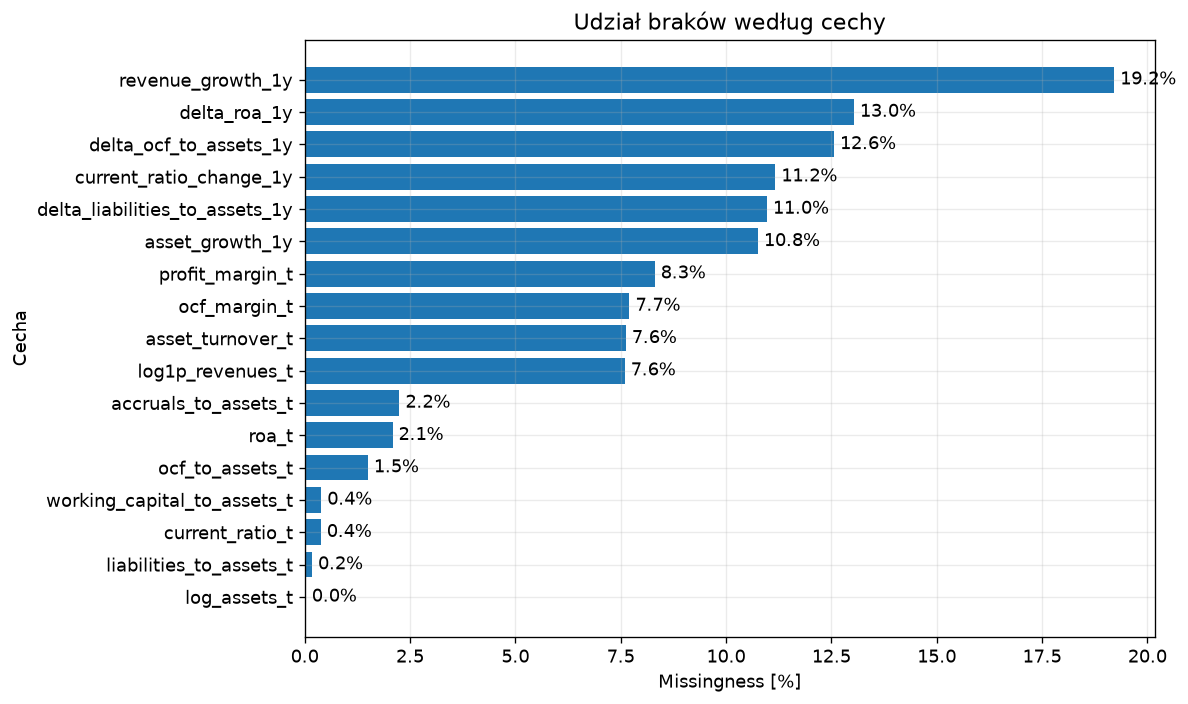

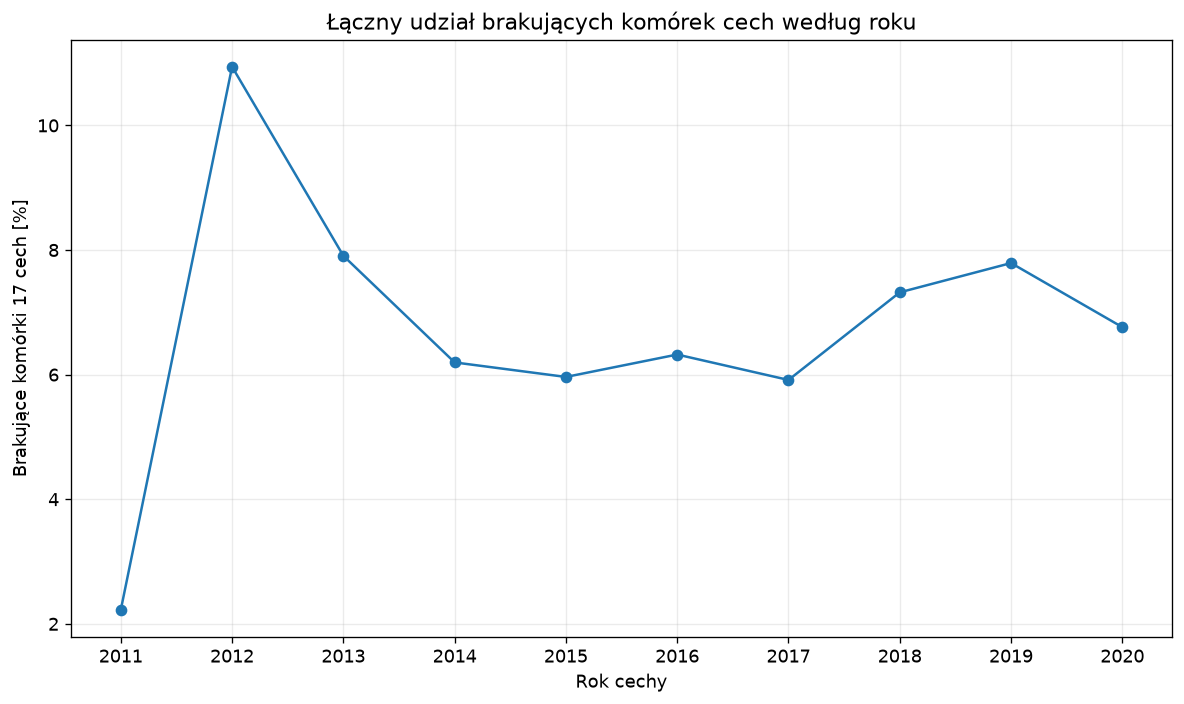

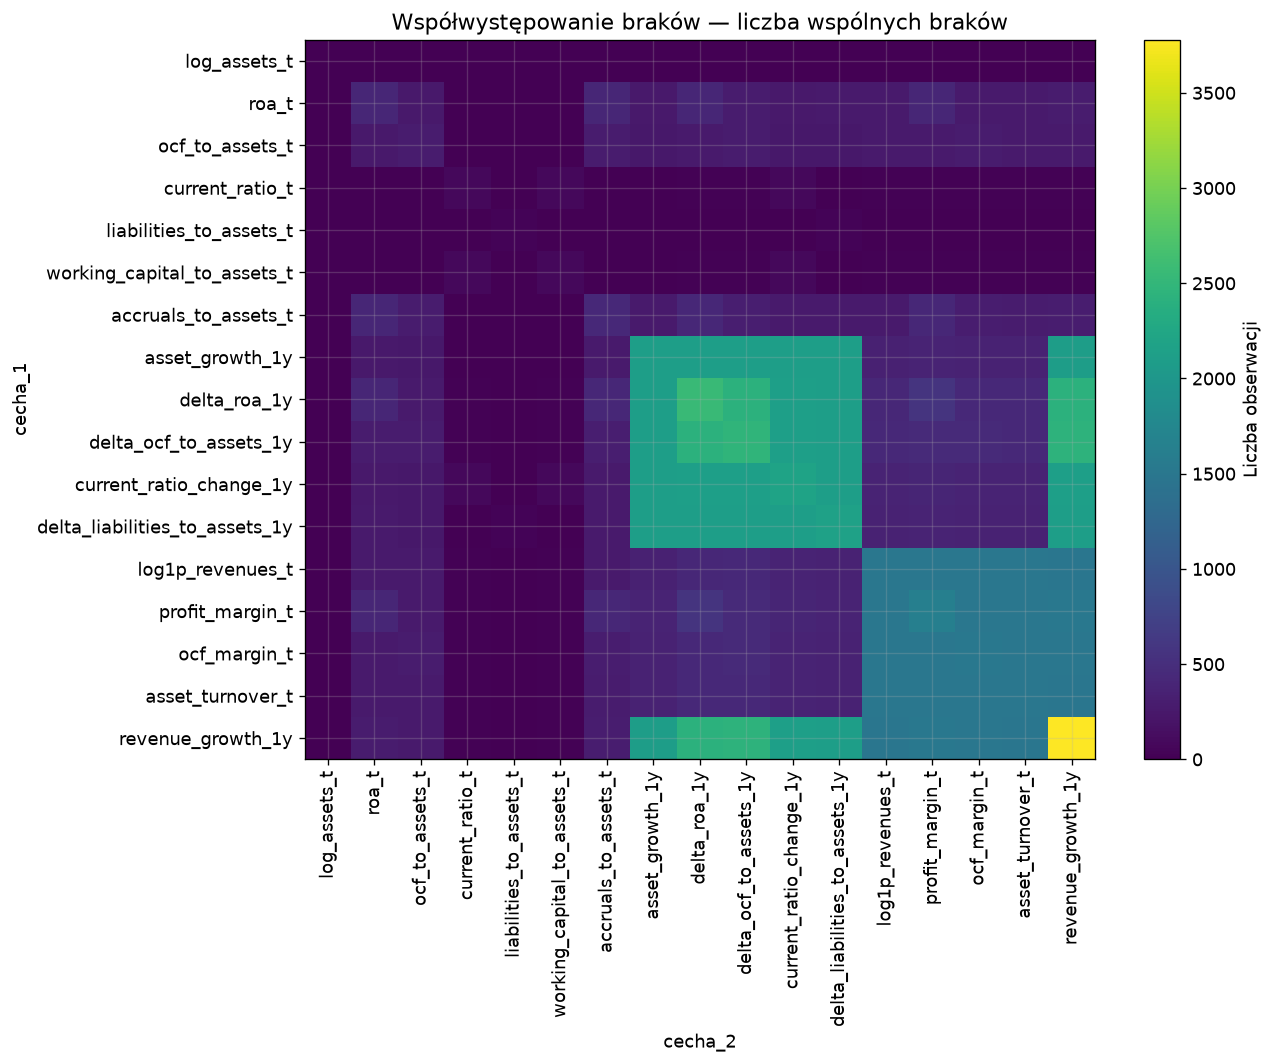

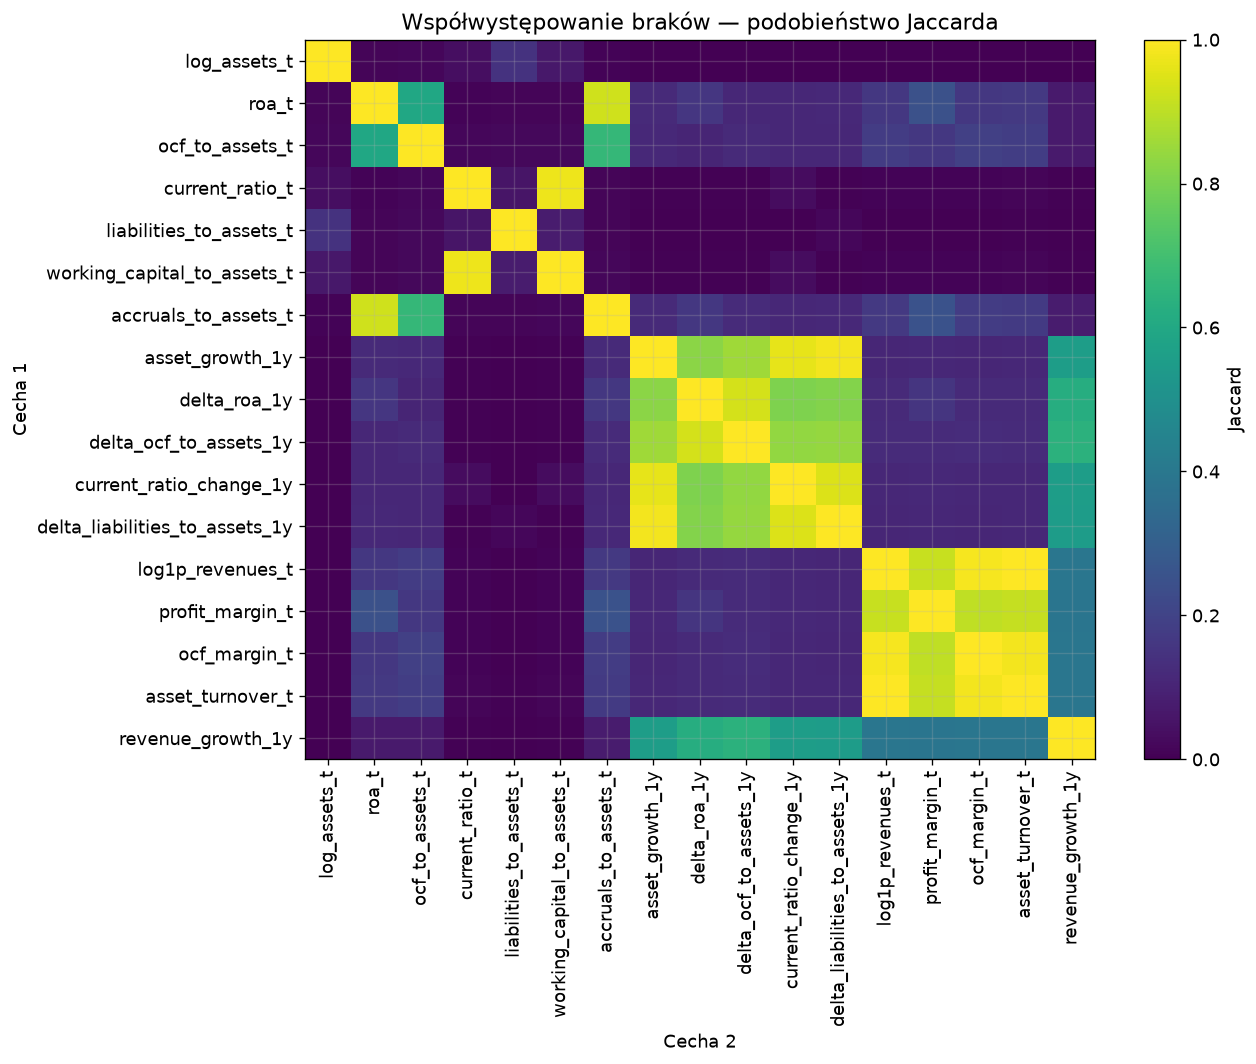

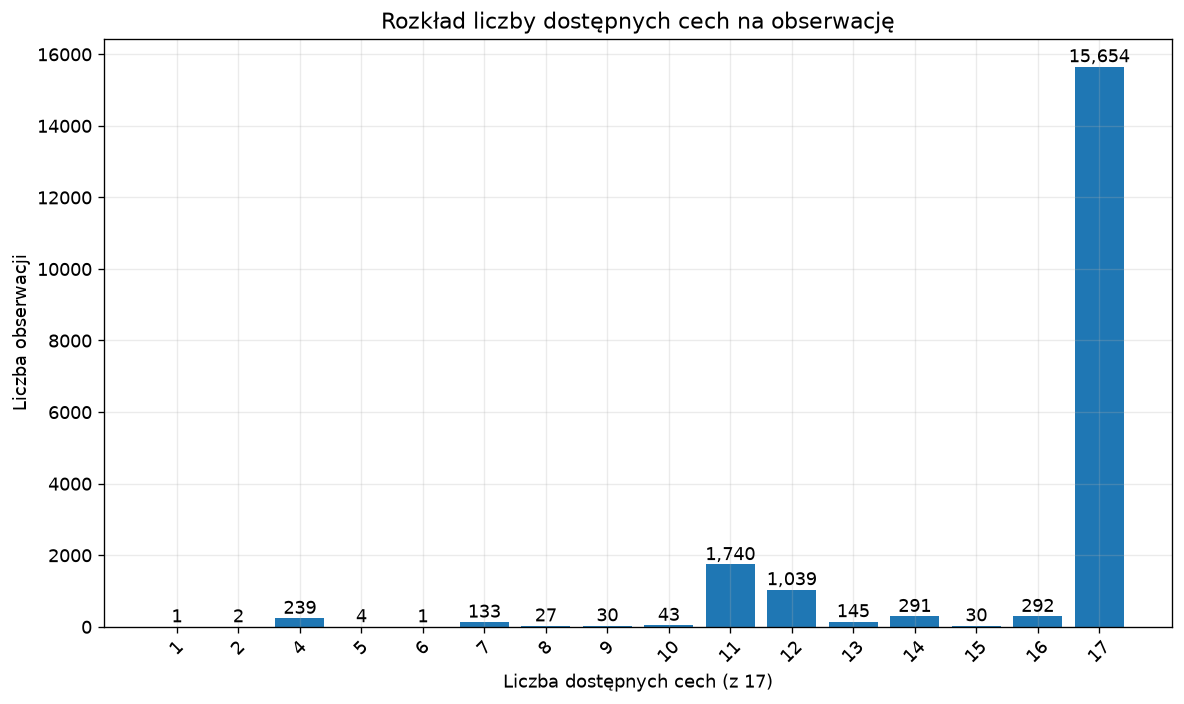

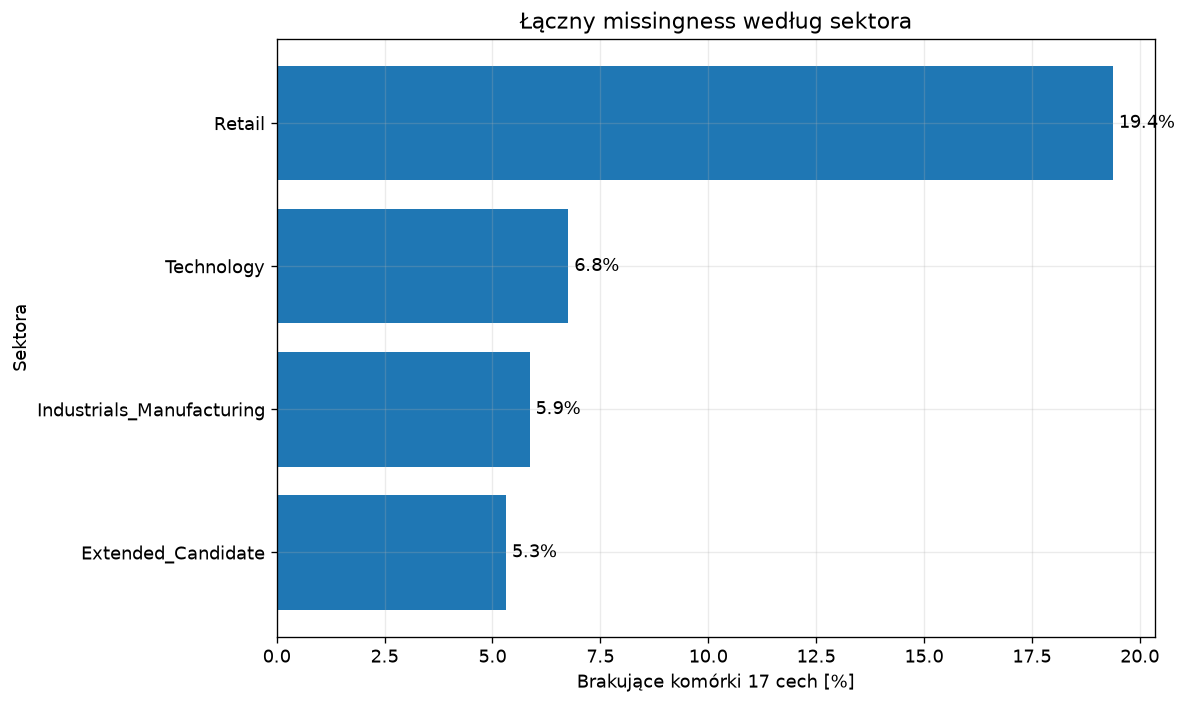

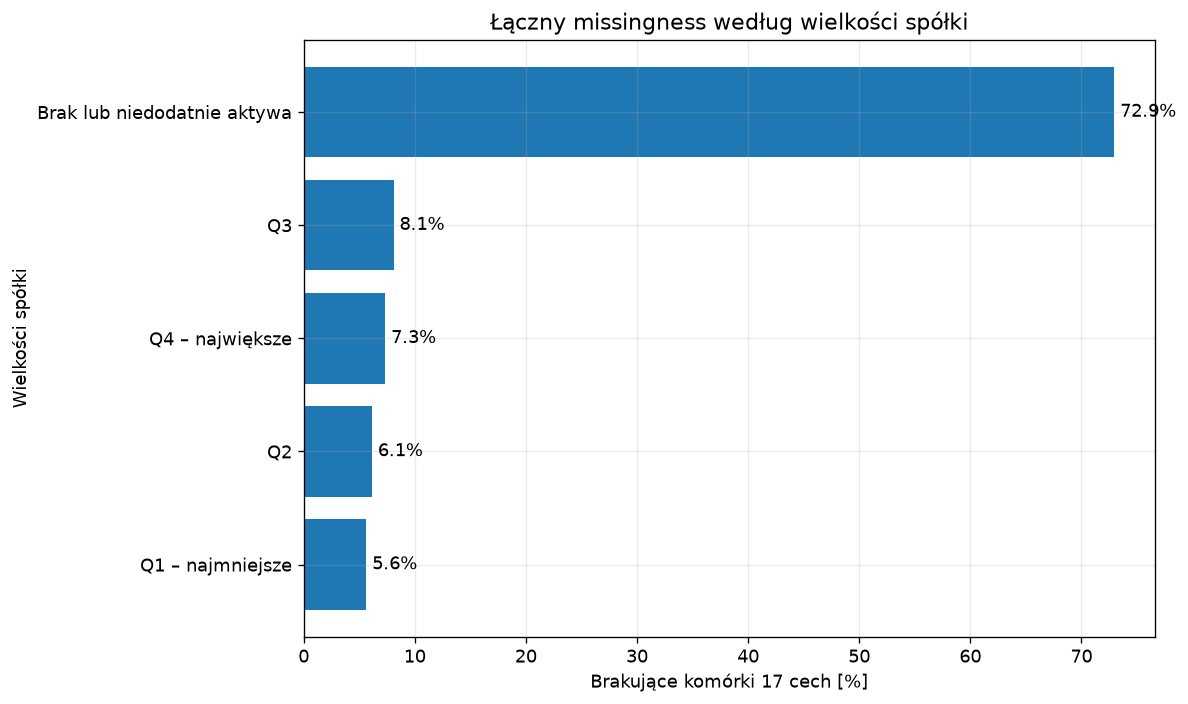

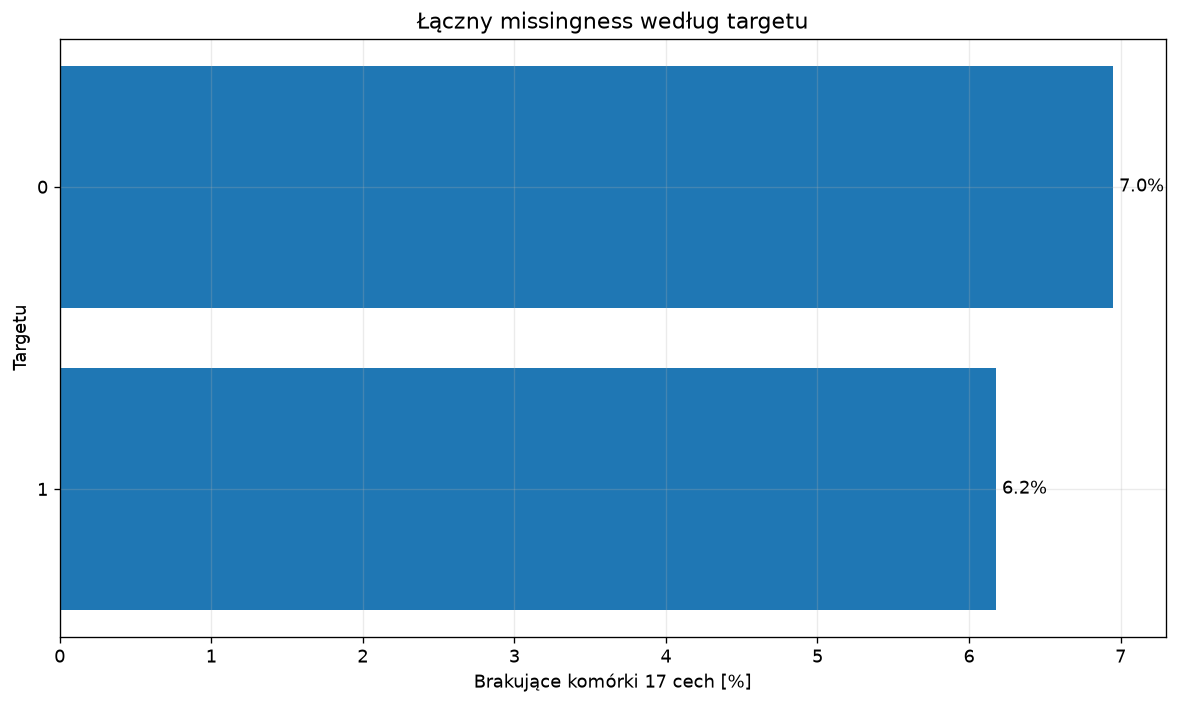

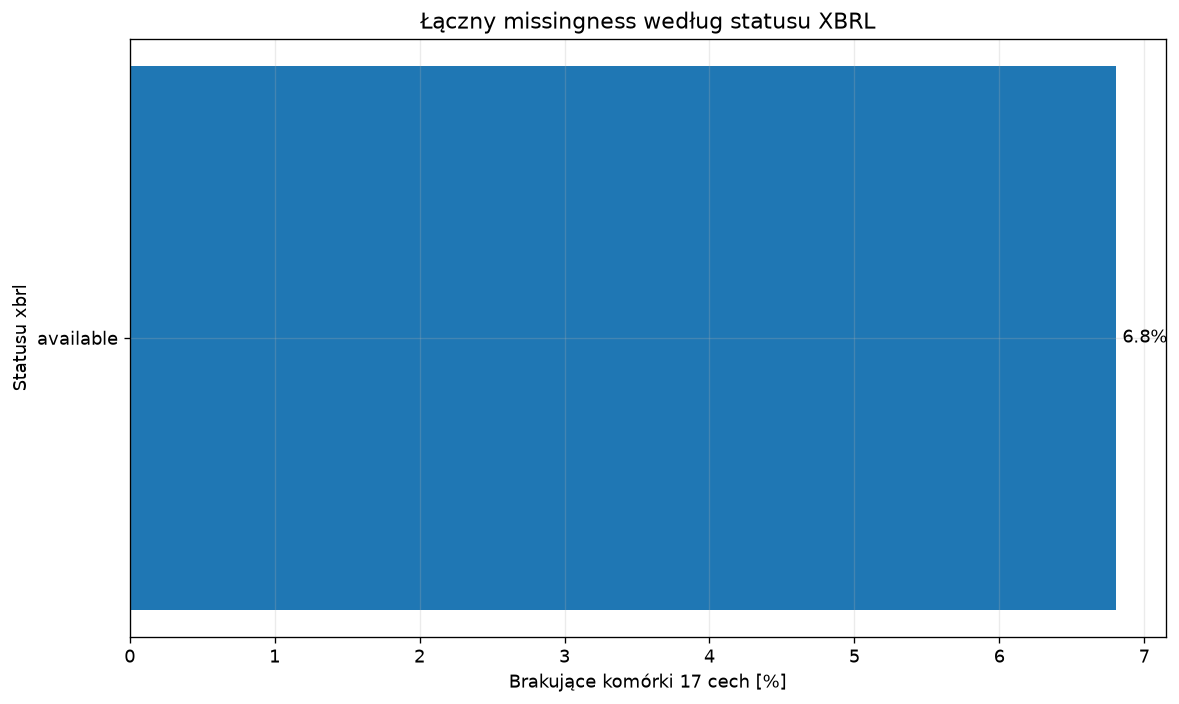

In [11]:
bar_chart(
    feature_missingness["missingness_pct"].sort_values(),
    title="Udział braków według cechy",
    x_label="Missingness [%]",
    y_label="Cecha",
    filename="12_missingness_by_feature.png",
    horizontal=True,
    percent=True,
)

fig, ax = plt.subplots()
ax.plot(
    missing_by_year.index.astype(int),
    missing_by_year["missing_all_feature_cells_pct"],
    marker="o",
)
ax.set_title("Łączny udział brakujących komórek cech według roku")
ax.set_xlabel("Rok cechy")
ax.set_ylabel("Brakujące komórki 17 cech [%]")
ax.set_xticks(missing_by_year.index.astype(int))
finalize_figure(fig, "13_aggregate_missingness_by_year.png")


def matrix_heatmap(matrix: pd.DataFrame, *, title: str, filename: str, colorbar_label: str) -> None:
    fig, ax = plt.subplots(figsize=(11, 9))
    image = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(matrix.columns)), labels=matrix.columns, rotation=90)
    ax.set_yticks(range(len(matrix.index)), labels=matrix.index)
    ax.set_xlabel(matrix.columns.name or "Cecha 2")
    ax.set_ylabel(matrix.index.name or "Cecha 1")
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)
    finalize_figure(fig, filename)


matrix_heatmap(
    missing_counts,
    title="Współwystępowanie braków — liczba wspólnych braków",
    filename="14_missing_cooccurrence_counts.png",
    colorbar_label="Liczba obserwacji",
)
matrix_heatmap(
    missing_jaccard,
    title="Współwystępowanie braków — podobieństwo Jaccarda",
    filename="15_missing_cooccurrence_jaccard.png",
    colorbar_label="Jaccard",
)
bar_chart(
    available_count_distribution["n_obserwacji"],
    title="Rozkład liczby dostępnych cech na obserwację",
    x_label="Liczba dostępnych cech (z 17)",
    y_label="Liczba obserwacji",
    filename="16_available_feature_count_distribution.png",
)

for group_name, table, filename in [
    ("sektora", missing_by_sector, "17_missingness_by_sector.png"),
    ("wielkości spółki", missing_by_size, "18_missingness_by_size.png"),
    ("targetu", missing_by_target, "19_missingness_by_target.png"),
    ("statusu XBRL", missing_by_xbrl, "20_missingness_by_xbrl.png"),
]:
    bar_chart(
        table["missing_all_feature_cells_pct"].sort_values(),
        title=f"Łączny missingness według {group_name}",
        x_label="Brakujące komórki 17 cech [%]",
        y_label=group_name.capitalize(),
        filename=filename,
        horizontal=True,
        percent=True,
    )


## 3.5. Współliniowość i redundancja

Korelacja Spearmana jest analizą podstawową, Pearson — pomocniczą. Obliczenia są wykonywane parami na dostępnych, skończonych wartościach, a liczba wspólnych obserwacji jest raportowana. Wysoka korelacja nie oznacza przyczynowości i nie prowadzi do automatycznego usunięcia cechy.


In [12]:
correlation_frame = analysis_frame[FEATURES].replace([np.inf, -np.inf], np.nan)
spearman_corr = correlation_frame.corr(method="spearman", min_periods=2)
pearson_corr = correlation_frame.corr(method="pearson", min_periods=2)
pairwise_n = correlation_frame.notna().astype(int).T.dot(
    correlation_frame.notna().astype(int)
)
pairwise_n.index.name = "cecha_1"
pairwise_n.columns.name = "cecha_2"


def correlation_pairs(correlation: pd.DataFrame, n_matrix: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for feature_1, feature_2 in combinations(FEATURES, 2):
        value = correlation.loc[feature_1, feature_2]
        rows.append(
            {
                "cecha_1": feature_1,
                "cecha_2": feature_2,
                "r": value,
                "abs_r": abs(value) if pd.notna(value) else np.nan,
                "n_wspolnych_obserwacji": int(n_matrix.loc[feature_1, feature_2]),
            }
        )
    return pd.DataFrame(rows)


spearman_pairs = correlation_pairs(spearman_corr, pairwise_n)
pearson_pairs = correlation_pairs(pearson_corr, pairwise_n)
spearman_over_08 = spearman_pairs.loc[spearman_pairs["abs_r"].gt(0.8)].sort_values(
    "abs_r", ascending=False
)
spearman_over_09 = spearman_pairs.loc[spearman_pairs["abs_r"].gt(0.9)].sort_values(
    "abs_r", ascending=False
)
top_10_spearman = spearman_pairs.sort_values("abs_r", ascending=False).head(10)

for filename, table in {
    "30_spearman_correlation_matrix.csv": spearman_corr,
    "31_pearson_correlation_matrix.csv": pearson_corr,
    "32_pairwise_correlation_n.csv": pairwise_n,
    "33_spearman_pairs_abs_gt_0_8.csv": spearman_over_08,
    "34_spearman_pairs_abs_gt_0_9.csv": spearman_over_09,
    "35_top_10_spearman_pairs.csv": top_10_spearman,
    "36_all_spearman_pairs.csv": spearman_pairs,
    "37_all_pearson_pairs.csv": pearson_pairs,
}.items():
    save_table(table, filename, index=not filename.startswith(("33_", "34_", "35_", "36_", "37_")))

show_table("Macierz korelacji Spearmana", spearman_corr)
show_table("Pomocnicza macierz korelacji Pearsona", pearson_corr)
show_table("Pary Spearmana z |r| > 0,8", spearman_over_08)
show_table("Pary Spearmana z |r| > 0,9", spearman_over_09)
show_table("10 najsilniej skorelowanych par Spearmana", top_10_spearman)


#### Macierz korelacji Spearmana

,log_assets_t,roa_t,ocf_to_assets_t,current_ratio_t,liabilities_to_assets_t,working_capital_to_assets_t,accruals_to_assets_t,asset_growth_1y,delta_roa_1y,delta_ocf_to_assets_1y,current_ratio_change_1y,delta_liabilities_to_assets_1y,log1p_revenues_t,profit_margin_t,ocf_margin_t,asset_turnover_t,revenue_growth_1y
log_assets_t,1.0000,0.5076,0.4993,0.0597,0.0201,-0.0329,0.2701,0.0686,0.0143,0.0104,0.0413,-0.0453,0.9566,0.5256,0.5761,-0.0795,-0.0161
roa_t,0.5076,1.0000,0.7523,0.2163,-0.2524,0.1687,0.5491,0.2214,0.2386,0.0825,0.1638,-0.2750,0.5592,0.9427,0.6571,0.2213,0.0925
ocf_to_assets_t,0.4993,0.7523,1.0000,0.1009,-0.1677,0.0440,0.0472,0.1161,0.0938,0.2497,0.0825,-0.1529,0.5489,0.7152,0.8628,0.2171,0.0325
current_ratio_t,0.0597,0.2163,0.1009,1.0000,-0.7054,0.9152,0.2803,0.1236,0.0319,0.0089,0.2528,-0.1819,0.0016,0.1795,0.0867,-0.1370,0.0176
liabilities_to_assets_t,0.0201,-0.2524,-0.1677,-0.7054,1.0000,-0.6509,-0.2305,-0.1181,-0.0304,-0.0112,-0.1309,0.2529,0.0684,-0.2174,-0.1484,0.1362,-0.0283
working_capital_to_assets_t,-0.0329,0.1687,0.0440,0.9152,-0.6509,1.0000,0.2694,0.1220,0.0450,0.0144,0.2231,-0.1719,-0.0494,0.0997,-0.0368,-0.0042,0.0251
accruals_to_assets_t,0.2701,0.5491,0.0472,0.2803,-0.2305,0.2694,1.0000,0.1988,0.2571,-0.1542,0.1810,-0.2563,0.2730,0.5190,0.0666,0.0592,0.0760
asset_growth_1y,0.0686,0.2214,0.1161,0.1236,-0.1181,0.1220,0.1988,1.0000,0.2845,0.1729,0.2490,-0.2511,0.0344,0.2057,0.1178,-0.1153,0.4270
delta_roa_1y,0.0143,0.2386,0.0938,0.0319,-0.0304,0.0450,0.2571,0.2845,1.0000,0.4082,0.2577,-0.3500,0.0191,0.2110,0.0588,0.0185,0.2313
delta_ocf_to_assets_1y,0.0104,0.0825,0.2497,0.0089,-0.0112,0.0144,-0.1542,0.1729,0.4082,1.0000,0.1270,-0.1860,0.0200,0.0691,0.1865,0.0203,0.1727


#### Pomocnicza macierz korelacji Pearsona

,log_assets_t,roa_t,ocf_to_assets_t,current_ratio_t,liabilities_to_assets_t,working_capital_to_assets_t,accruals_to_assets_t,asset_growth_1y,delta_roa_1y,delta_ocf_to_assets_1y,current_ratio_change_1y,delta_liabilities_to_assets_1y,log1p_revenues_t,profit_margin_t,ocf_margin_t,asset_turnover_t,revenue_growth_1y
log_assets_t,1.0000,0.0648,0.1273,-0.0312,-0.0665,0.0640,0.0574,-0.0225,-0.0115,-0.0168,-0.0317,0.0160,0.9345,0.0806,0.0684,-0.2218,-0.0209
roa_t,0.0648,1.0000,0.6776,0.0095,-0.9663,0.9672,0.9979,-0.0001,0.3992,0.3931,-0.0000,-0.4014,0.0517,0.0915,0.0138,-0.0760,-0.0002
ocf_to_assets_t,0.1273,0.6776,1.0000,0.0167,-0.6921,0.6882,0.6288,-0.0008,0.2649,0.5982,-0.0005,-0.2787,0.1053,0.0638,0.0246,-0.2363,-0.0016
current_ratio_t,-0.0312,0.0095,0.0167,1.0000,-0.0114,0.0113,0.0086,-0.0016,-0.0025,0.0016,0.3381,0.0034,-0.1095,-0.0149,-0.0587,-0.1058,-0.0040
liabilities_to_assets_t,-0.0665,-0.9663,-0.6921,-0.0114,1.0000,-0.9998,-0.9610,-0.0003,-0.3749,-0.4114,-0.0005,0.3980,-0.0511,-0.0717,-0.0115,0.0866,-0.0000
working_capital_to_assets_t,0.0640,0.9672,0.6882,0.0113,-0.9998,1.0000,0.9624,0.0003,0.3840,0.4102,0.0005,-0.4079,0.0491,0.0721,0.0114,-0.0817,0.0000
accruals_to_assets_t,0.0574,0.9979,0.6288,0.0086,-0.9610,0.9624,1.0000,0.0000,0.3989,0.3634,0.0000,-0.4001,0.0455,0.0912,0.0124,-0.0596,-0.0001
asset_growth_1y,-0.0225,-0.0001,-0.0008,-0.0016,-0.0003,0.0003,0.0000,1.0000,0.0991,0.0430,0.1557,-0.1359,-0.0225,-0.0010,0.0003,-0.0059,0.3924
delta_roa_1y,-0.0115,0.3992,0.2649,-0.0025,-0.3749,0.3840,0.3989,0.0991,1.0000,0.4986,0.0193,-0.9776,-0.0195,-0.0135,-0.0038,-0.0362,0.0024
delta_ocf_to_assets_1y,-0.0168,0.3931,0.5982,0.0016,-0.4114,0.4102,0.3634,0.0430,0.4986,1.0000,0.0641,-0.5911,-0.0301,-0.1362,-0.0085,-0.1468,-0.0016


#### Pary Spearmana z |r| > 0,8

,cecha_1,cecha_2,r,abs_r,n_wspolnych_obserwacji
11,log_assets_t,log1p_revenues_t,0.9566,0.9566,18172
27,roa_t,profit_margin_t,0.9427,0.9427,18032
46,current_ratio_t,working_capital_to_assets_t,0.9152,0.9152,19594
42,ocf_to_assets_t,ocf_margin_t,0.8628,0.8628,18150


#### Pary Spearmana z |r| > 0,9

,cecha_1,cecha_2,r,abs_r,n_wspolnych_obserwacji
11,log_assets_t,log1p_revenues_t,0.9566,0.9566,18172
27,roa_t,profit_margin_t,0.9427,0.9427,18032
46,current_ratio_t,working_capital_to_assets_t,0.9152,0.9152,19594


#### 10 najsilniej skorelowanych par Spearmana

,cecha_1,cecha_2,r,abs_r,n_wspolnych_obserwacji
11,log_assets_t,log1p_revenues_t,0.9566,0.9566,18172
27,roa_t,profit_margin_t,0.9427,0.9427,18032
46,current_ratio_t,working_capital_to_assets_t,0.9152,0.9152,19594
42,ocf_to_assets_t,ocf_margin_t,0.8628,0.8628,18150
16,roa_t,ocf_to_assets_t,0.7523,0.7523,19229
130,profit_margin_t,ocf_margin_t,0.7341,0.7341,18016
41,ocf_to_assets_t,profit_margin_t,0.7152,0.7152,18011
45,current_ratio_t,liabilities_to_assets_t,-0.7054,0.7054,19568
28,roa_t,ocf_margin_t,0.6571,0.6571,18011
58,liabilities_to_assets_t,working_capital_to_assets_t,-0.6509,0.6509,19568


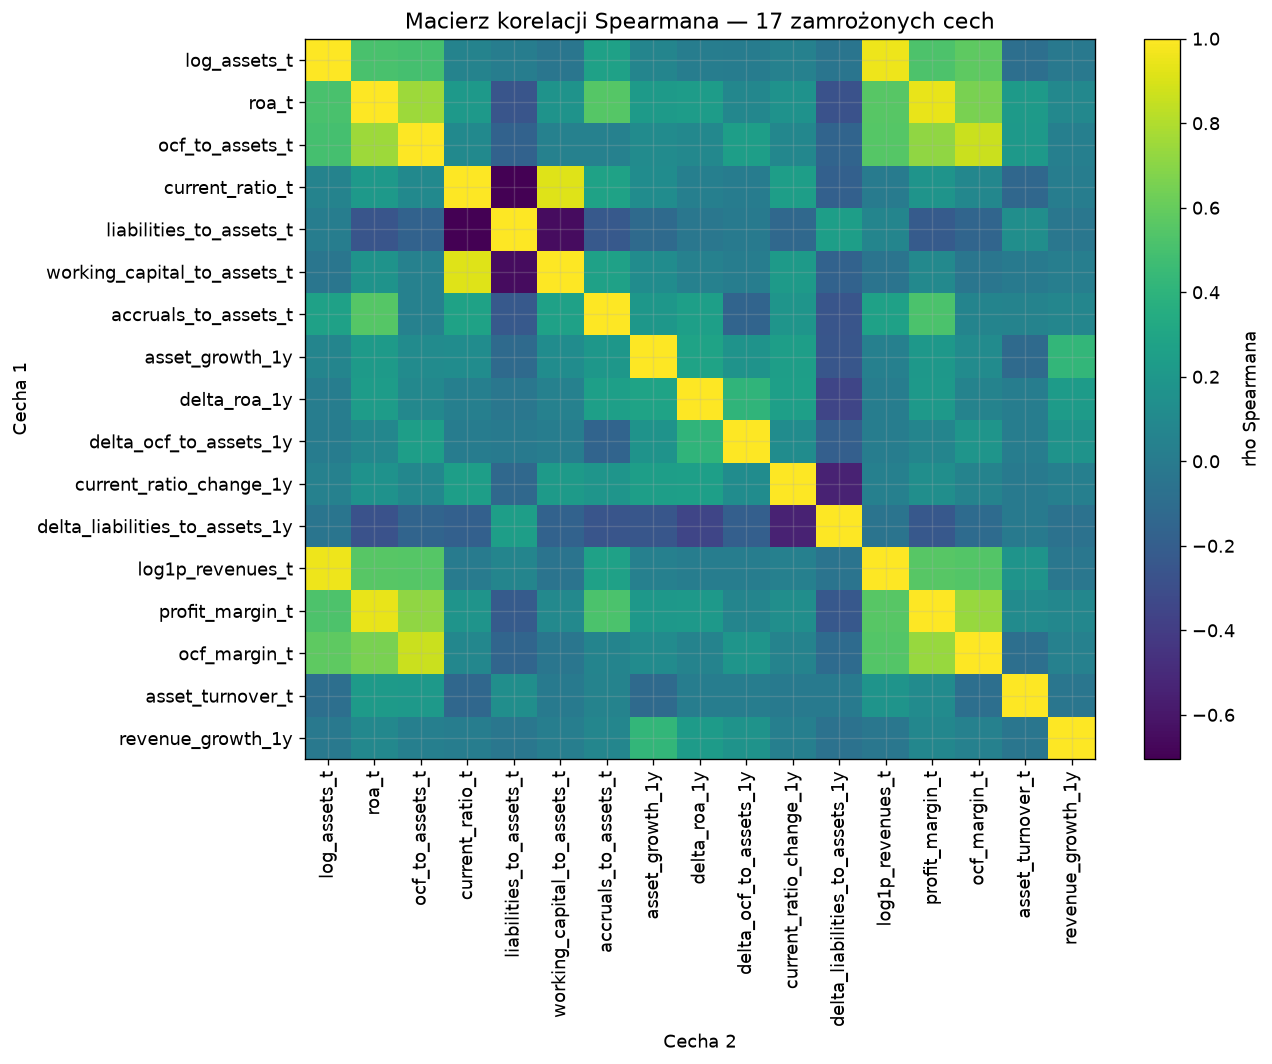

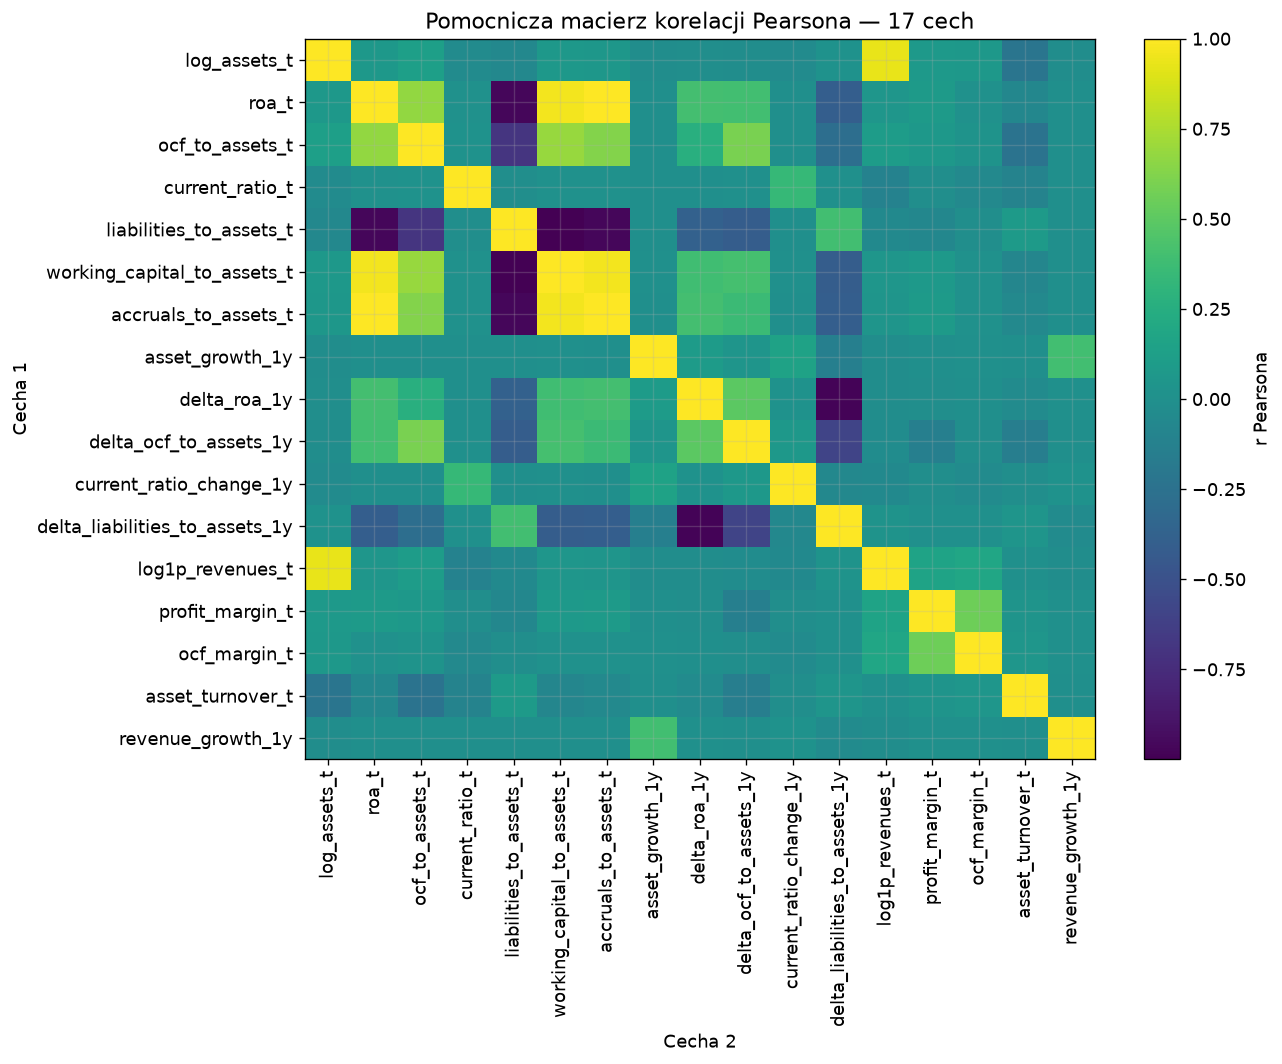

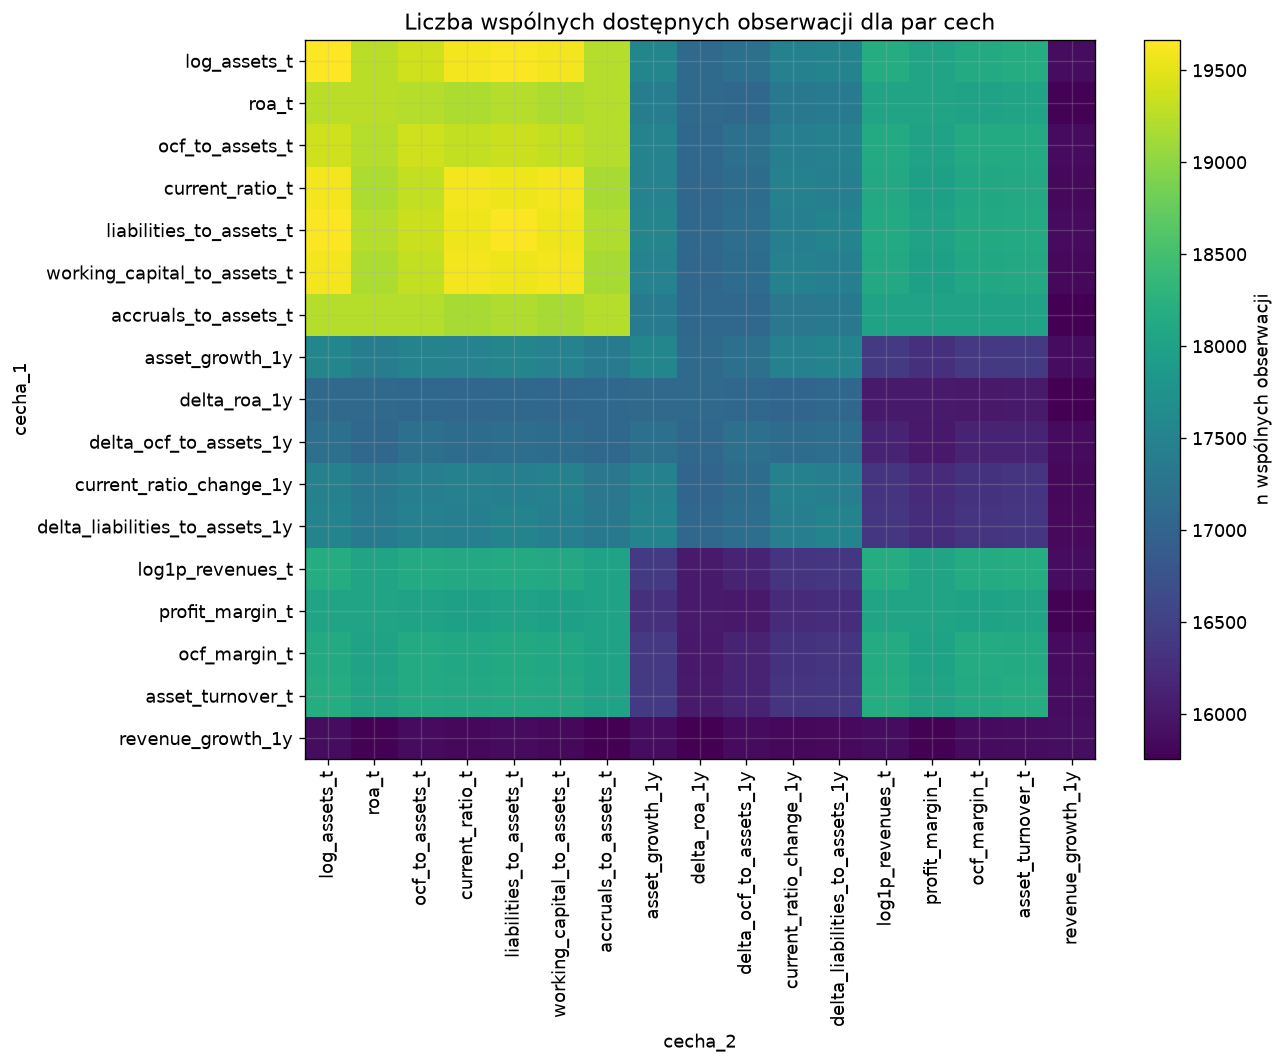

In [13]:
matrix_heatmap(
    spearman_corr,
    title="Macierz korelacji Spearmana — 17 zamrożonych cech",
    filename="21_spearman_correlation_heatmap.png",
    colorbar_label="rho Spearmana",
)
matrix_heatmap(
    pearson_corr,
    title="Pomocnicza macierz korelacji Pearsona — 17 cech",
    filename="22_pearson_correlation_heatmap.png",
    colorbar_label="r Pearsona",
)
matrix_heatmap(
    pairwise_n,
    title="Liczba wspólnych dostępnych obserwacji dla par cech",
    filename="23_pairwise_correlation_n.png",
    colorbar_label="n wspólnych obserwacji",
)


In [14]:
def variance_diagnostics(frame: pd.DataFrame) -> pd.DataFrame:
    policy = PreprocessingPolicy()
    rows = []
    for feature in FEATURES:
        finite = finite_series(frame, feature)
        if finite.empty:
            rows.append(
                {
                    "cecha": feature,
                    "n_finite": 0,
                    "n_unique": 0,
                    "unique_pct": np.nan,
                    "dominant_share": np.nan,
                    "variance_ddof0": np.nan,
                    "constant": True,
                    "near_zero_variance": True,
                }
            )
            continue
        value_counts = finite.value_counts(dropna=False)
        variance = float(finite.var(ddof=0))
        constant = finite.nunique(dropna=True) <= 1 or variance <= policy.zero_scale_tolerance
        dominant_share = float(value_counts.iloc[0] / len(finite))
        near_zero = bool(
            constant
            or dominant_share >= policy.near_constant_dominant_share
            or variance <= policy.zero_scale_tolerance
        )
        rows.append(
            {
                "cecha": feature,
                "n_finite": len(finite),
                "n_unique": int(finite.nunique(dropna=True)),
                "unique_pct": 100.0 * finite.nunique(dropna=True) / len(finite),
                "dominant_share": dominant_share,
                "variance_ddof0": variance,
                "constant": constant,
                "near_zero_variance": near_zero,
            }
        )
    return pd.DataFrame(rows).set_index("cecha").loc[FEATURES]


def technical_vif(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Median imputation is used here only as an explicitly technical VIF operation."""
    numeric = frame[FEATURES].replace([np.inf, -np.inf], np.nan).astype(float)
    medians = numeric.median(axis=0, skipna=True)
    all_missing = medians.index[medians.isna()].tolist()
    valid_features = [feature for feature in FEATURES if feature not in all_missing]
    technical = numeric[valid_features].copy()
    imputed_counts = technical.isna().sum().astype(int)
    technical = technical.fillna(medians[valid_features])

    variance = technical.var(axis=0, ddof=0)
    constant_features = variance.index[variance.le(1e-12)].tolist()
    regression_features = [f for f in valid_features if f not in constant_features]

    vif_rows = []
    if regression_features:
        standardized = technical[regression_features]
        standardized = (standardized - standardized.mean(axis=0)) / standardized.std(
            axis=0, ddof=0
        )
        matrix = standardized.to_numpy(dtype=float)
        for index, feature in enumerate(regression_features):
            y = matrix[:, index]
            if matrix.shape[1] == 1:
                vif = 1.0
                r_squared = 0.0
            else:
                predictors = np.delete(matrix, index, axis=1)
                design = np.column_stack([np.ones(len(predictors)), predictors])
                coefficients, *_ = np.linalg.lstsq(design, y, rcond=None)
                residuals = y - design @ coefficients
                ss_res = float(np.dot(residuals, residuals))
                centered = y - y.mean()
                ss_tot = float(np.dot(centered, centered))
                r_squared = np.nan if ss_tot <= 1e-12 else 1.0 - ss_res / ss_tot
                if not np.isfinite(r_squared):
                    vif = np.nan
                elif 1.0 - r_squared <= 1e-12:
                    vif = np.inf
                else:
                    vif = 1.0 / (1.0 - r_squared)
            vif_rows.append(
                {
                    "cecha": feature,
                    "VIF": vif,
                    "R2_pomocniczej_regresji": r_squared,
                    "n": len(technical),
                    "n_imputowanych_technicznie": int(imputed_counts[feature]),
                    "imputowane_technicznie_pct": 100.0 * imputed_counts[feature] / len(technical),
                    "status": "ok",
                }
            )

    for feature in constant_features:
        vif_rows.append(
            {
                "cecha": feature,
                "VIF": np.inf,
                "R2_pomocniczej_regresji": np.nan,
                "n": len(technical),
                "n_imputowanych_technicznie": int(imputed_counts[feature]),
                "imputowane_technicznie_pct": 100.0 * imputed_counts[feature] / len(technical),
                "status": "cecha stała lub numerycznie stała",
            }
        )
    for feature in all_missing:
        vif_rows.append(
            {
                "cecha": feature,
                "VIF": np.nan,
                "R2_pomocniczej_regresji": np.nan,
                "n": len(frame),
                "n_imputowanych_technicznie": len(frame),
                "imputowane_technicznie_pct": 100.0,
                "status": "brak skończonych wartości — VIF niedostępny",
            }
        )

    vif = pd.DataFrame(vif_rows).set_index("cecha").reindex(FEATURES)
    imputation = pd.DataFrame(
        {
            "n_imputowanych_technicznie": numeric.isna().sum().astype(int),
            "imputowane_technicznie_pct": 100.0 * numeric.isna().mean(),
            "mediana_uzyta_wylacznie_do_VIF": medians,
        }
    ).reindex(FEATURES)
    imputation.index.name = "cecha"
    return vif, imputation


variance_check = variance_diagnostics(analysis_frame)
vif_table, vif_imputation_audit = technical_vif(analysis_frame)

save_table(variance_check, "38_constant_and_near_zero_variance.csv")
save_table(vif_table, "39_vif_technical_median_imputation.csv")
save_table(vif_imputation_audit, "40_vif_imputation_audit.csv")

show_table("Kontrola cech stałych i near-zero variance", variance_check)
show_table("VIF — techniczna diagnostyka pomocnicza", vif_table)
show_table("Jawny audyt technicznej imputacji zastosowanej wyłącznie do VIF", vif_imputation_audit)
display(
    Markdown(
        "**Uwaga metodologiczna:** imputacja medianą w tej komórce istnieje tylko "
        "w lokalnej macierzy diagnostycznej VIF. Nie zmienia `analysis_frame`, "
        "zamrożonego preprocessingu ani późniejszego pipeline'u modelowego."
    )
)


#### Kontrola cech stałych i near-zero variance

,n_finite,n_unique,unique_pct,dominant_share,variance_ddof0,constant,near_zero_variance
cecha,,,,,,,
log_assets_t,19666,19569,99.5068,0.0001,8.7211,False,False
roa_t,19261,19247,99.9273,0.0001,"6,929.0537",False,False
ocf_to_assets_t,19376,19363,99.9329,0.0001,47.3763,False,False
current_ratio_t,19596,19585,99.9439,0.0001,32.3814,False,False
liabilities_to_assets_t,19637,19625,99.9389,0.0002,"7,555.3652",False,False
working_capital_to_assets_t,19594,19583,99.9439,0.0001,"7,553.9356",False,False
accruals_to_assets_t,19229,19217,99.9376,0.0002,"6,208.2413",False,False
asset_growth_1y,17555,17534,99.8804,0.0001,"117,173.7467",False,False
delta_roa_1y,17107,17097,99.9415,0.0001,"47,519.8219",False,False


#### VIF — techniczna diagnostyka pomocnicza

,VIF,R2_pomocniczej_regresji,n,n_imputowanych_technicznie,imputowane_technicznie_pct,status
cecha,,,,,,
log_assets_t,6.1122,0.8364,19671,5,0.0254,ok
roa_t,"839,174.3495",1.0000,19671,410,2.0843,ok
ocf_to_assets_t,"5,773.9434",0.9998,19671,295,1.4997,ok
current_ratio_t,1.1775,0.1508,19671,75,0.3813,ok
liabilities_to_assets_t,"1,919.3275",0.9995,19671,34,0.1728,ok
working_capital_to_assets_t,"1,931.8572",0.9995,19671,77,0.3914,ok
accruals_to_assets_t,"750,624.8962",1.0000,19671,442,2.2470,ok
asset_growth_1y,1.0679,0.0635,19671,2116,10.7570,ok
delta_roa_1y,24.8024,0.9597,19671,2564,13.0344,ok


#### Jawny audyt technicznej imputacji zastosowanej wyłącznie do VIF

,n_imputowanych_technicznie,imputowane_technicznie_pct,mediana_uzyta_wylacznie_do_VIF
cecha,,,
log_assets_t,5,0.0254,19.7535
roa_t,410,2.0843,0.0183
ocf_to_assets_t,295,1.4997,0.0668
current_ratio_t,75,0.3813,1.9219
liabilities_to_assets_t,34,0.1728,0.5379
working_capital_to_assets_t,77,0.3914,0.2058
accruals_to_assets_t,442,2.2470,-0.0610
asset_growth_1y,2116,10.7570,0.0469
delta_roa_1y,2564,13.0344,-0.0014


**Uwaga metodologiczna:** imputacja medianą w tej komórce istnieje tylko w lokalnej macierzy diagnostycznej VIF. Nie zmienia `analysis_frame`, zamrożonego preprocessingu ani późniejszego pipeline'u modelowego.

## 3.6. Stabilność danych w czasie

Dla każdej cechy raportowane są mediana, P25, P75 i missingness w latach 2011–2020. Pomocnicze flagi opisowe wskazują wyraźne zmiany, gdy zakres rocznych median przekracza jeden ogólny IQR, maksymalny skok rok do roku przekracza połowę IQR albo zakres missingness wynosi co najmniej 10 punktów procentowych. Progi są diagnostyczne — nie służą do selekcji cech.


In [15]:
temporal_rows = []
for feature in FEATURES:
    for year, subset in analysis_frame.groupby("feature_year", sort=True):
        raw = pd.to_numeric(subset[feature], errors="raise")
        values = raw.to_numpy(dtype=float)
        finite = values[np.isfinite(values)]
        temporal_rows.append(
            {
                "cecha": feature,
                "blok": FEATURE_TO_BLOCK[feature],
                "feature_year": int(year),
                "n": len(subset),
                "n_finite": len(finite),
                "n_pominiete": len(subset) - len(finite),
                "median": float(np.median(finite)) if len(finite) else np.nan,
                "P25": float(np.quantile(finite, 0.25)) if len(finite) else np.nan,
                "P75": float(np.quantile(finite, 0.75)) if len(finite) else np.nan,
                "missingness_pct": 100.0 * raw.isna().mean(),
            }
        )
temporal_stats = pd.DataFrame(temporal_rows)


def diagnostic_ratio(numerator: float, denominator: float) -> float:
    if not np.isfinite(numerator):
        return np.nan
    if not np.isfinite(denominator) or denominator <= 1e-12:
        return np.inf if numerator > 1e-12 else 0.0
    return numerator / denominator


temporal_diagnostic_rows = []
for feature in FEATURES:
    yearly = temporal_stats.loc[temporal_stats["cecha"].eq(feature)].sort_values(
        "feature_year"
    )
    medians = yearly["median"].dropna()
    median_range = float(medians.max() - medians.min()) if len(medians) else np.nan
    max_yoy_jump = (
        float(medians.diff().abs().max()) if len(medians) >= 2 else np.nan
    )
    overall_iqr = float(descriptive_stats.loc[feature, "IQR"])
    missing_range = float(
        yearly["missingness_pct"].max() - yearly["missingness_pct"].min()
    )
    range_over_iqr = diagnostic_ratio(median_range, overall_iqr)
    yoy_over_iqr = diagnostic_ratio(max_yoy_jump, overall_iqr)
    distribution_flag = bool(
        (np.isfinite(range_over_iqr) and range_over_iqr >= 1.0)
        or np.isinf(range_over_iqr)
        or (np.isfinite(yoy_over_iqr) and yoy_over_iqr >= 0.5)
        or np.isinf(yoy_over_iqr)
    )
    availability_flag = missing_range >= 10.0
    temporal_diagnostic_rows.append(
        {
            "cecha": feature,
            "blok": FEATURE_TO_BLOCK[feature],
            "overall_IQR": overall_iqr,
            "range_rocznych_median": median_range,
            "range_median_over_IQR": range_over_iqr,
            "max_yoy_median_jump": max_yoy_jump,
            "max_yoy_jump_over_IQR": yoy_over_iqr,
            "missingness_range_pp": missing_range,
            "silna_zmiana_rozkladu_flag": distribution_flag,
            "silna_zmiana_dostepnosci_flag": availability_flag,
            "dowolna_flaga": distribution_flag or availability_flag,
        }
    )
temporal_diagnostics = pd.DataFrame(temporal_diagnostic_rows).set_index("cecha").loc[
    FEATURES
]
flagged_temporal = temporal_diagnostics.loc[temporal_diagnostics["dowolna_flaga"]].copy()
if not flagged_temporal.empty:
    flagged_temporal = flagged_temporal.sort_values(
        ["missingness_range_pp", "range_median_over_IQR"], ascending=False
    )

save_table(temporal_stats, "41_temporal_feature_statistics.csv", index=False)
save_table(temporal_diagnostics, "42_temporal_drift_diagnostics.csv")
save_table(flagged_temporal, "43_temporal_drift_flagged_features.csv")

show_table("Roczne mediany, P25, P75 i missingness — tabela długa", temporal_stats)
show_table("Diagnostyka stabilności 17 cech", temporal_diagnostics)
show_table("Cechy z pomocniczą flagą silnej zmiany", flagged_temporal)


#### Roczne mediany, P25, P75 i missingness — tabela długa

,cecha,blok,feature_year,n,n_finite,n_pominiete,median,P25,P75,missingness_pct
0,log_assets_t,L,2011,1907,1906,1,19.7523,17.6452,21.4382,0.0524
1,log_assets_t,L,2012,2311,2311,0,19.5603,17.5038,21.2467,0.0000
2,log_assets_t,L,2013,2393,2392,1,19.6394,17.5161,21.3002,0.0418
3,log_assets_t,L,2014,2300,2299,1,19.6468,17.6253,21.3574,0.0435
4,log_assets_t,L,2015,2241,2240,1,19.6982,17.6046,21.4246,0.0446
...,...,...,...,...,...,...,...,...,...,...
165,revenue_growth_1y,R,2016,2133,1739,394,0.0308,-0.0739,0.1805,18.4716
166,revenue_growth_1y,R,2017,1549,1269,280,0.0703,-0.0093,0.2282,18.0762
167,revenue_growth_1y,R,2018,1511,1159,352,0.0959,0.0128,0.2276,23.2958
168,revenue_growth_1y,R,2019,1638,1256,382,0.0441,-0.0390,0.1955,23.3211


#### Diagnostyka stabilności 17 cech

,blok,overall_IQR,range_rocznych_median,range_median_over_IQR,max_yoy_median_jump,max_yoy_jump_over_IQR,missingness_range_pp,silna_zmiana_rozkladu_flag,silna_zmiana_dostepnosci_flag,dowolna_flaga
cecha,,,,,,,,,,
log_assets_t,L,3.8971,0.5841,0.1499,0.2224,0.0571,0.0592,False,False,False
roa_t,L,0.2121,0.0394,0.1858,0.0168,0.0791,9.2321,False,False,False
ocf_to_assets_t,L,0.1590,0.0117,0.0738,0.0086,0.0538,8.8452,False,False,False
current_ratio_t,L,1.9736,0.2231,0.1131,0.1470,0.0745,0.5553,False,False,False
liabilities_to_assets_t,L,0.4152,0.0672,0.1618,0.0269,0.0648,0.3009,False,False,False
working_capital_to_assets_t,L,0.3576,0.0516,0.1444,0.0336,0.0938,0.5553,False,False,False
accruals_to_assets_t,L,0.1081,0.0234,0.2164,0.0169,0.1561,9.5350,False,False,False
asset_growth_1y,D,0.2521,0.0492,0.1951,0.0397,0.1573,14.4501,False,True,True
delta_roa_1y,D,0.0930,0.0159,0.1706,0.0159,0.1706,16.4795,False,True,True


#### Cechy z pomocniczą flagą silnej zmiany

,blok,overall_IQR,range_rocznych_median,range_median_over_IQR,max_yoy_median_jump,max_yoy_jump_over_IQR,missingness_range_pp,silna_zmiana_rozkladu_flag,silna_zmiana_dostepnosci_flag,dowolna_flaga
cecha,,,,,,,,,,
revenue_growth_1y,R,0.2441,0.1257,0.5149,0.0542,0.2221,17.3155,False,True,True
delta_roa_1y,D,0.0930,0.0159,0.1706,0.0159,0.1706,16.4795,False,True,True
delta_ocf_to_assets_1y,D,0.0911,0.0162,0.1777,0.0130,0.1430,16.2722,False,True,True
current_ratio_change_1y,D,0.3798,0.0890,0.2343,0.0731,0.1925,14.5406,False,True,True
asset_growth_1y,D,0.2521,0.0492,0.1951,0.0397,0.1573,14.4501,False,True,True
delta_liabilities_to_assets_1y,D,0.1083,0.0196,0.1810,0.0167,0.1540,14.4134,False,True,True
asset_turnover_t,R,0.9016,0.1970,0.2185,0.1343,0.1489,10.1431,False,True,True
log1p_revenues_t,R,4.1004,0.3831,0.0934,0.1687,0.0411,10.1431,False,True,True
ocf_margin_t,R,0.1745,0.0190,0.1091,0.0144,0.0828,10.0853,False,True,True


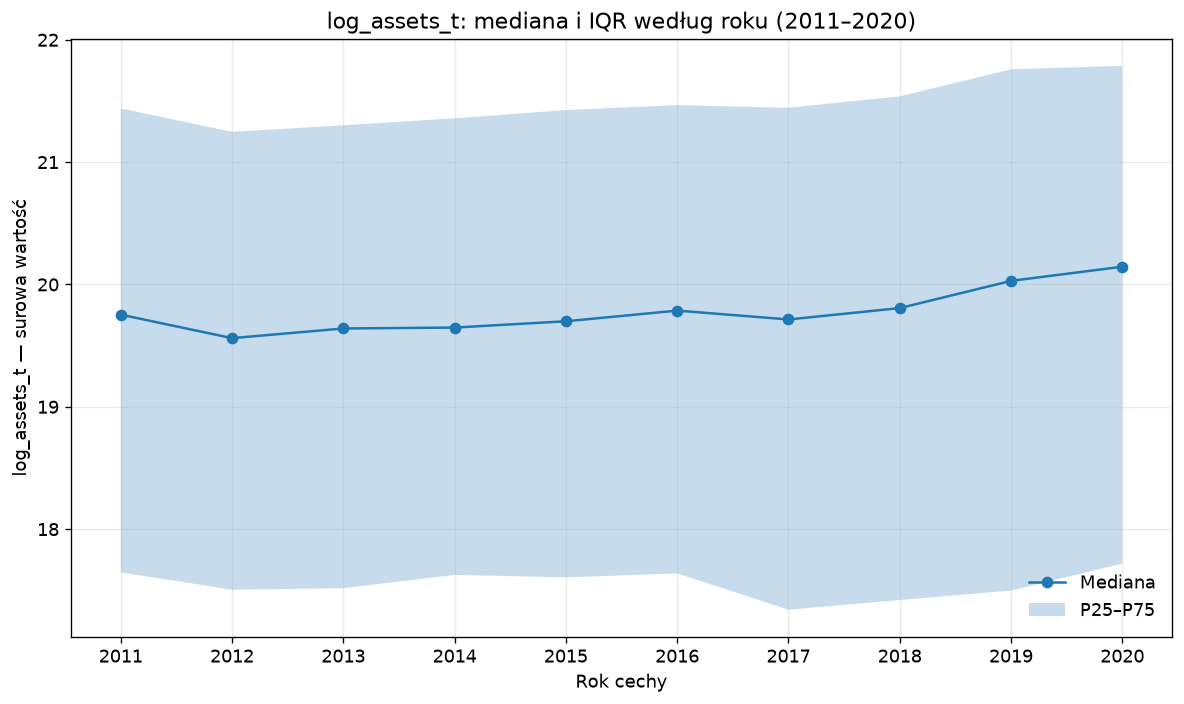

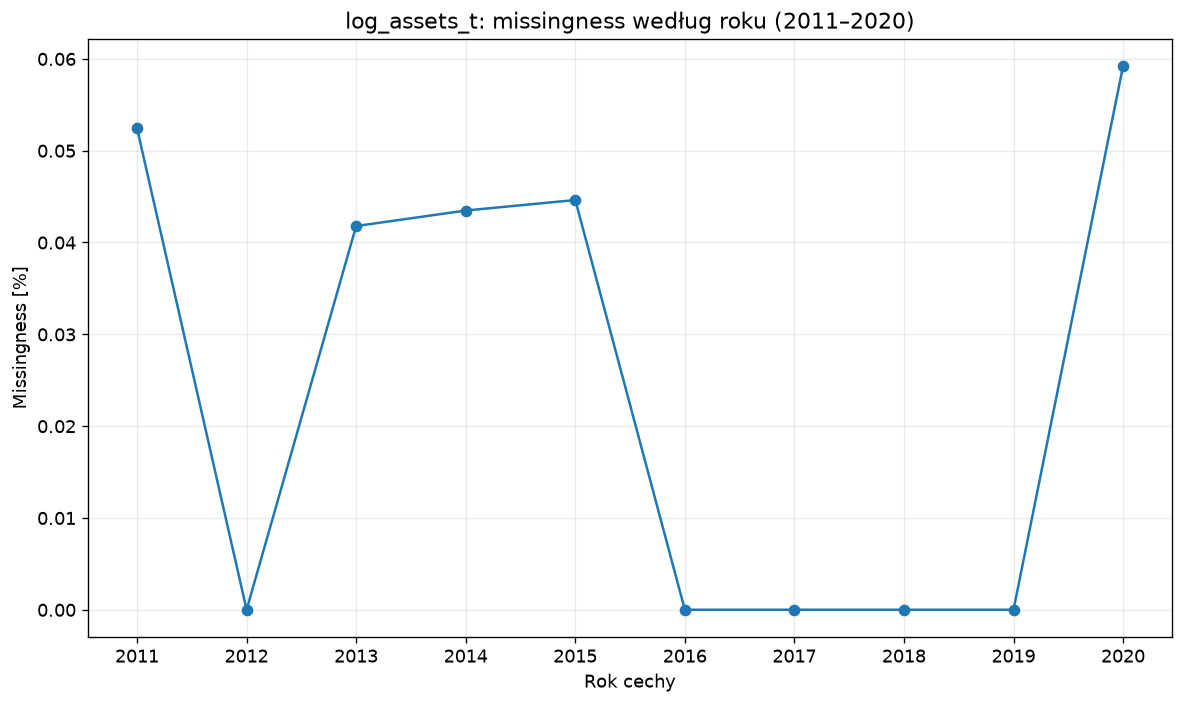

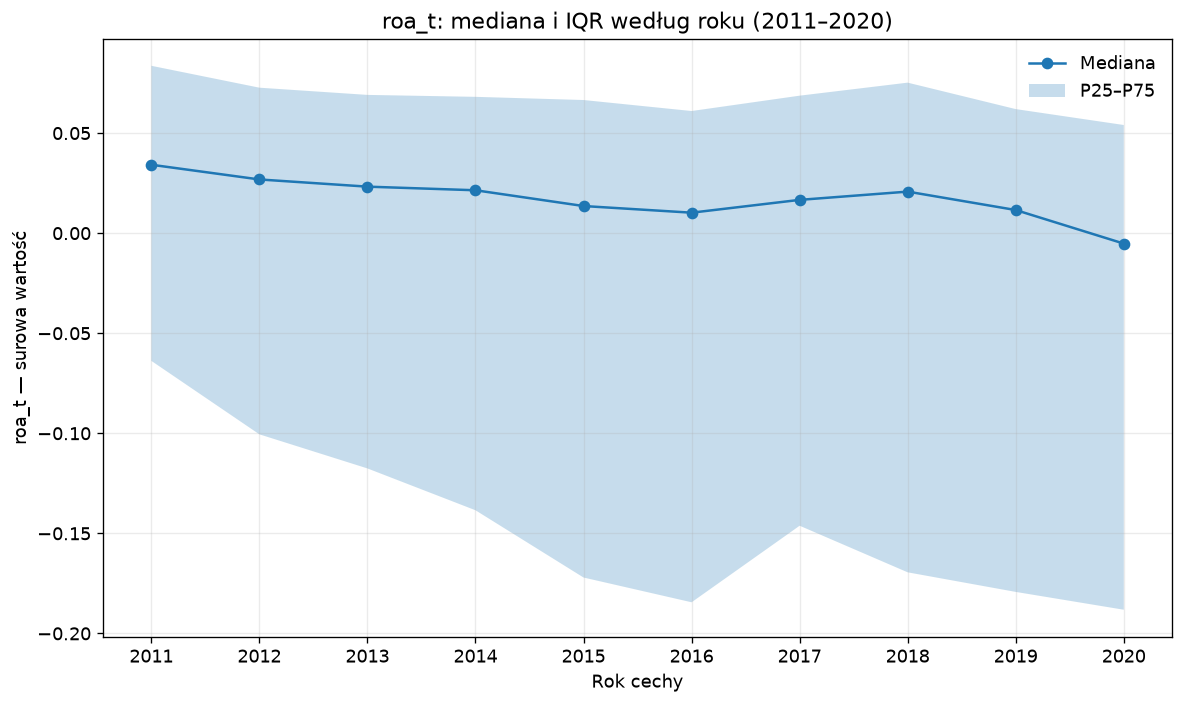

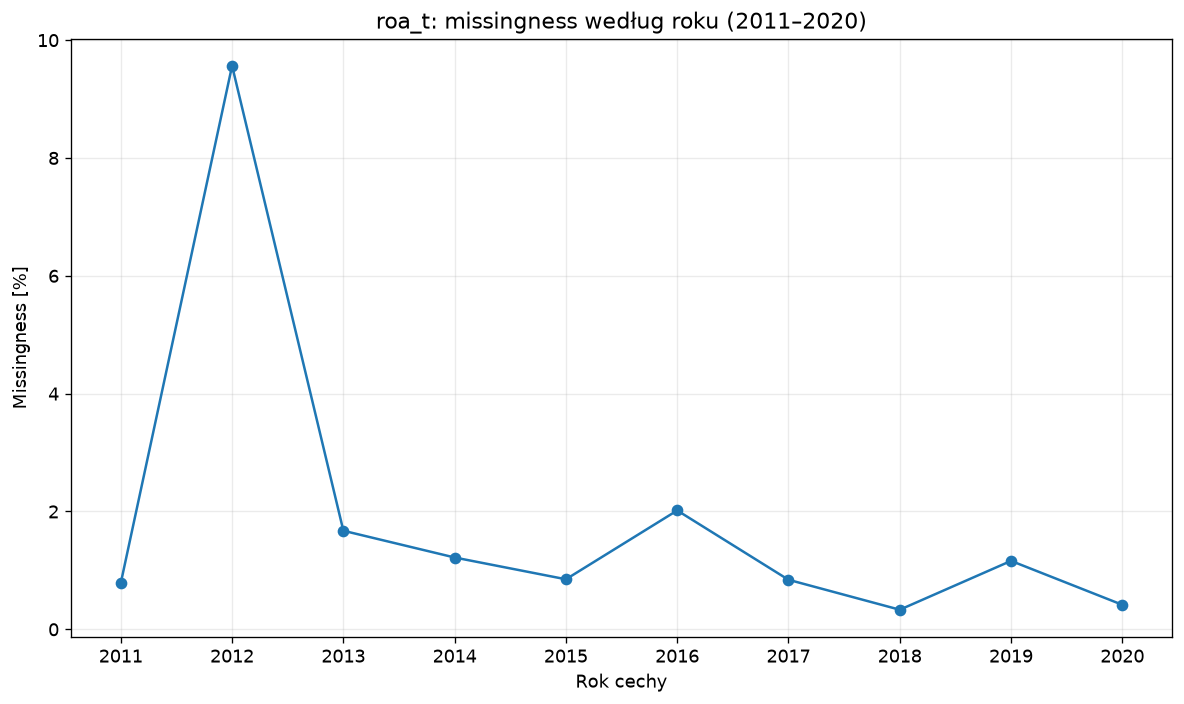

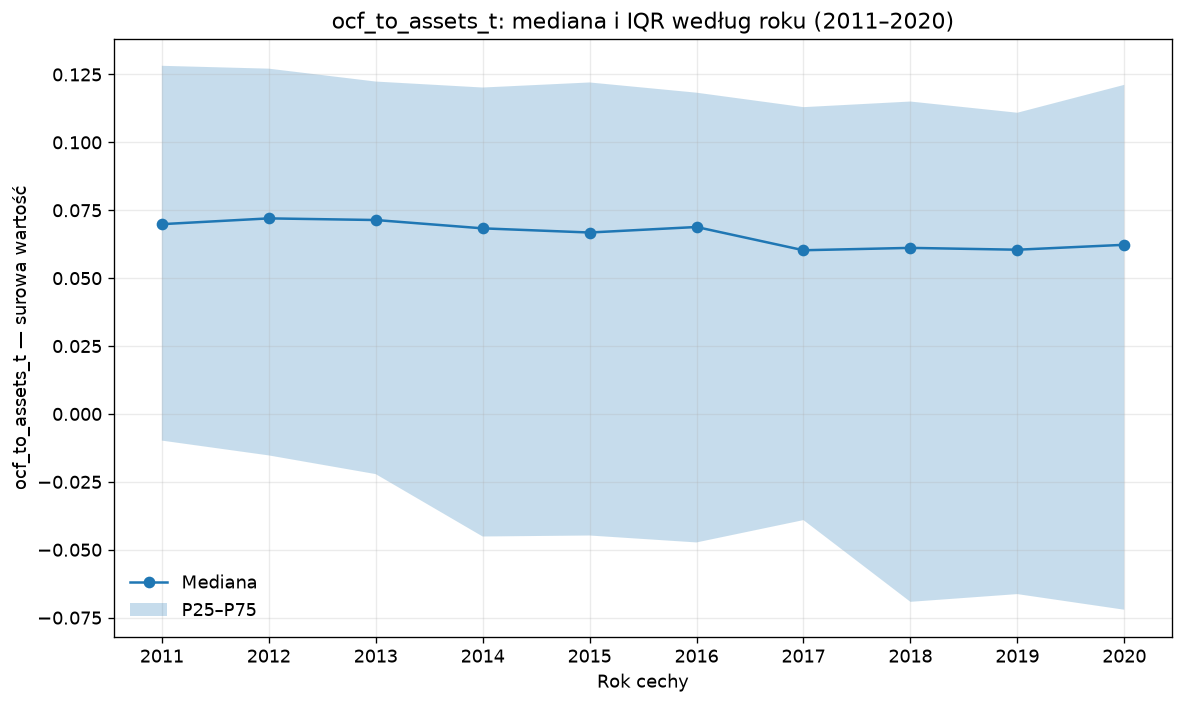

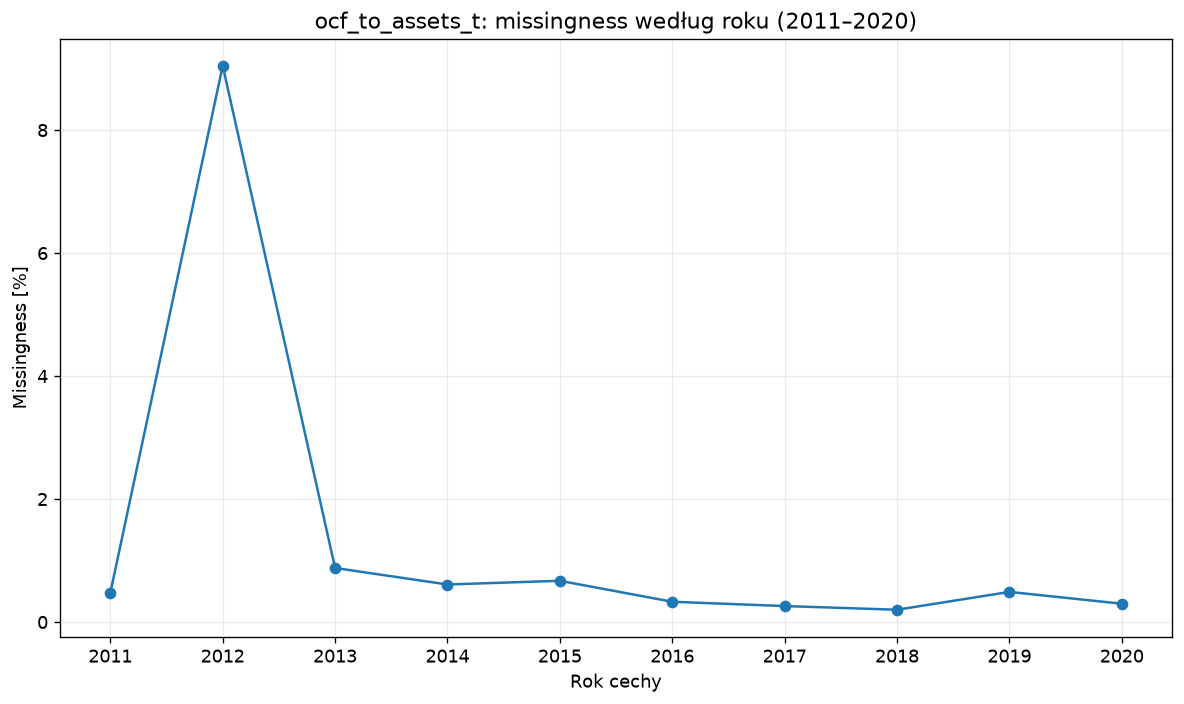

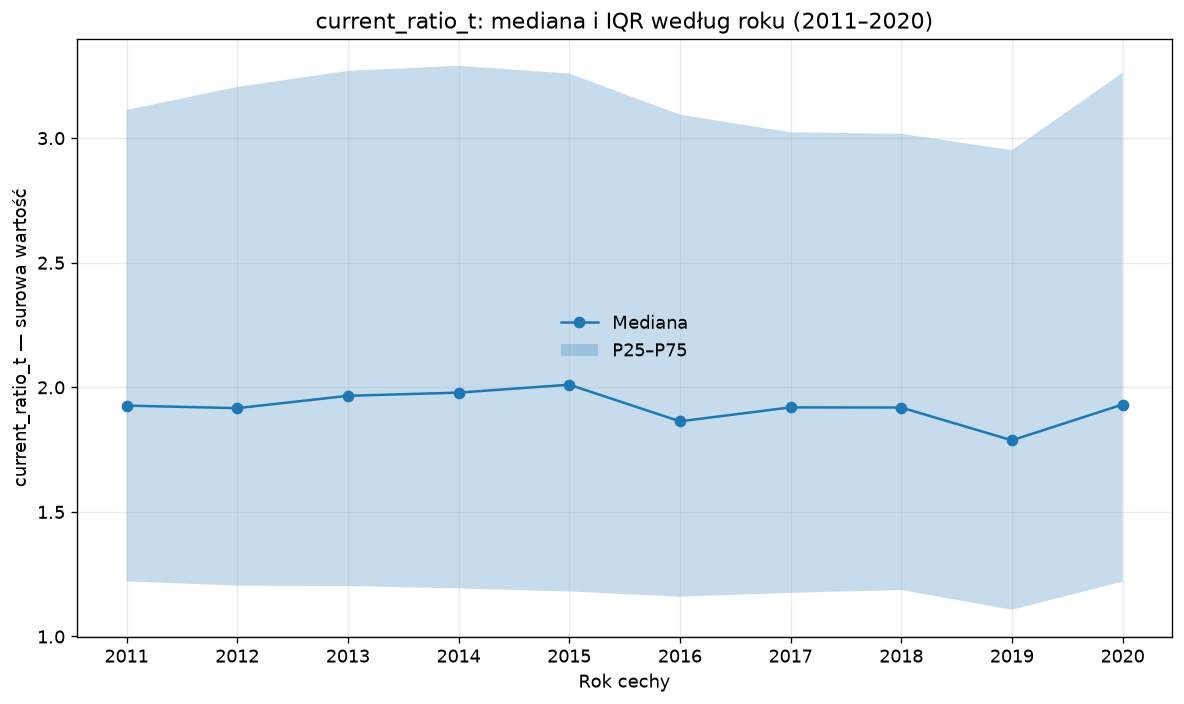

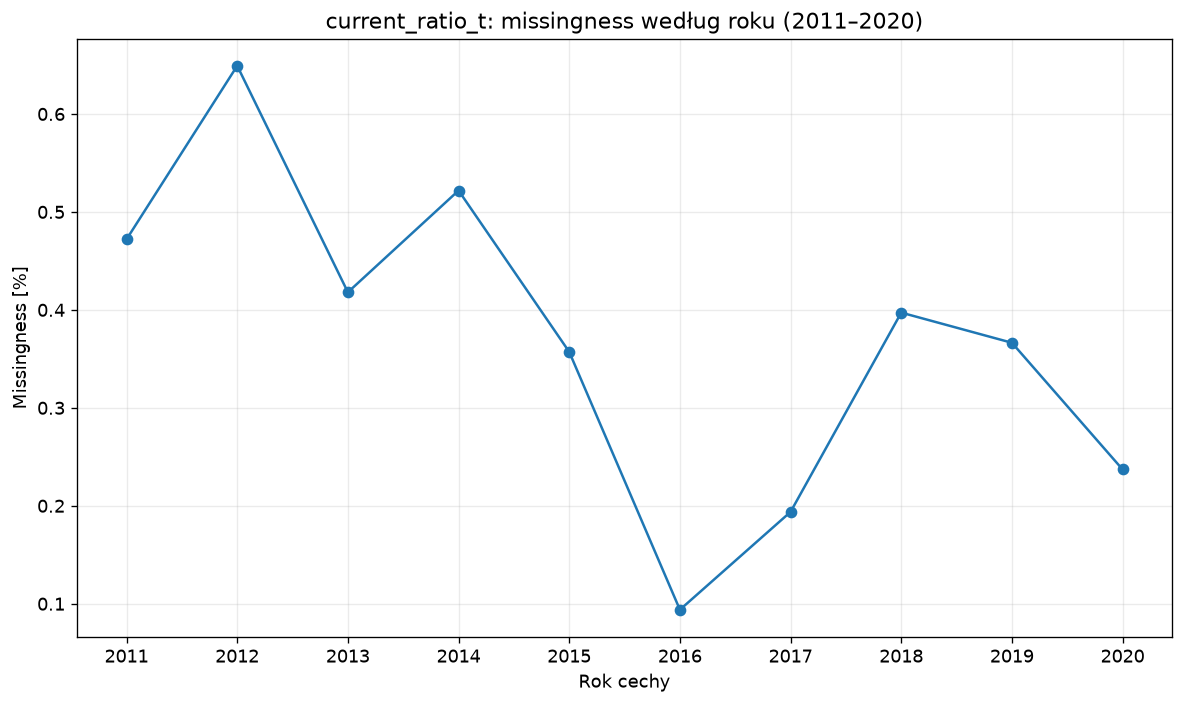

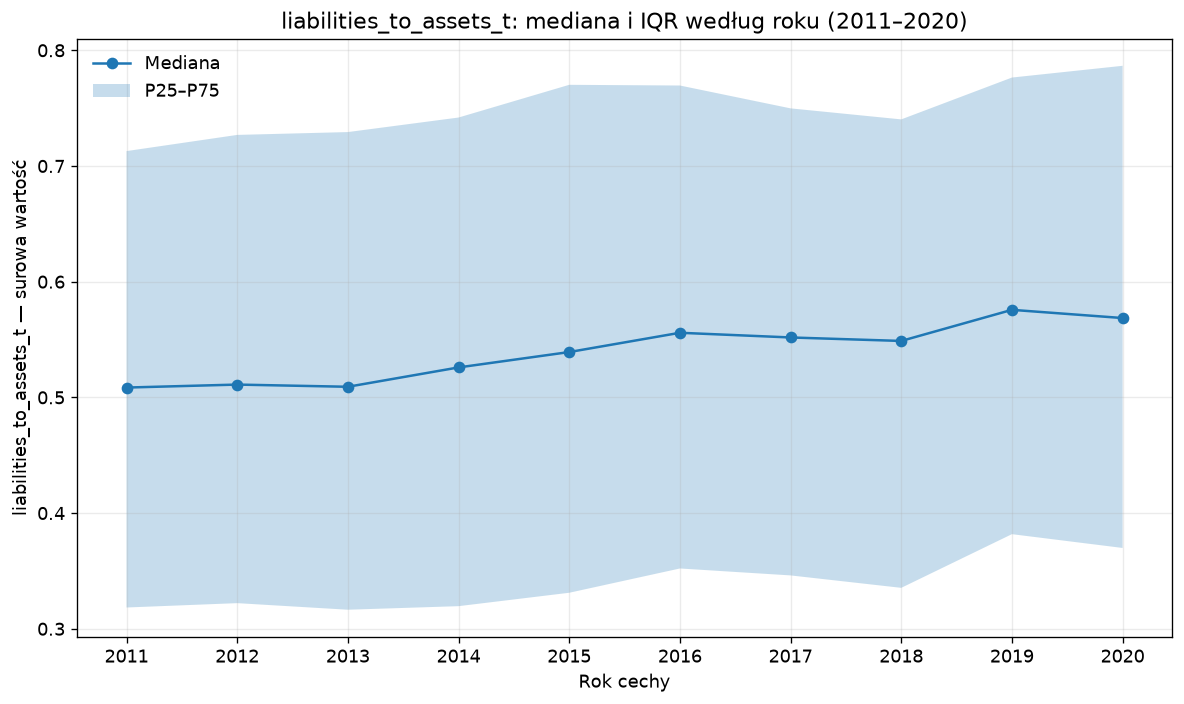

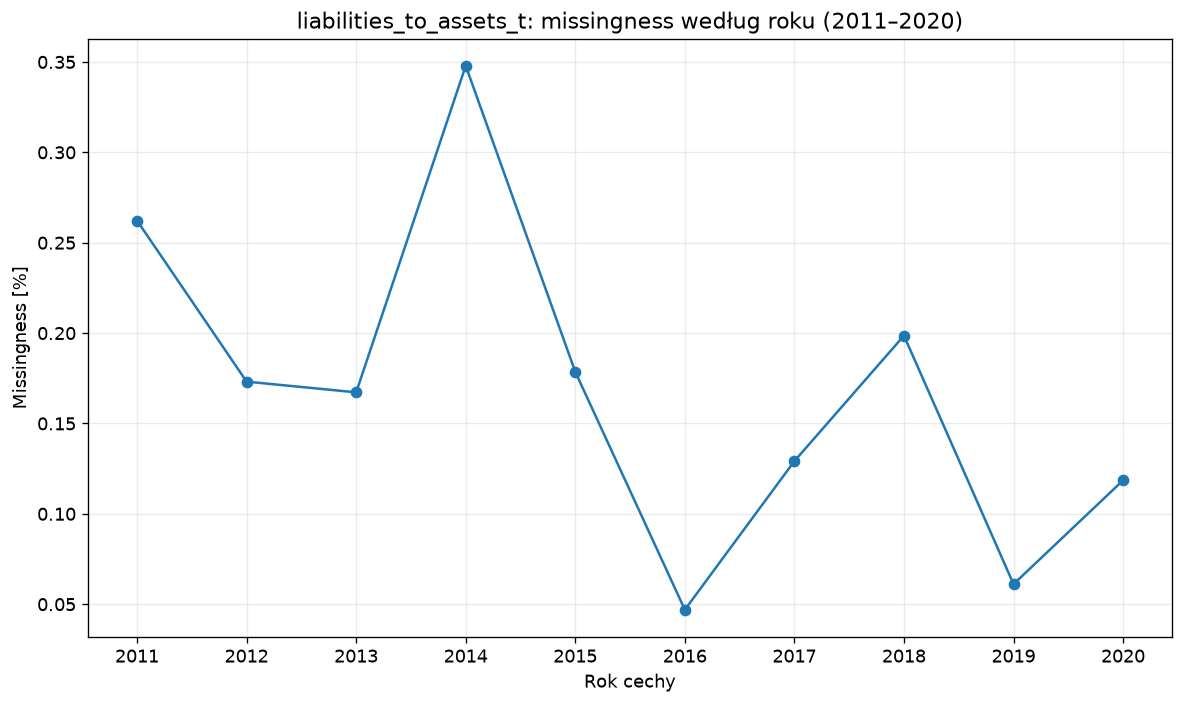

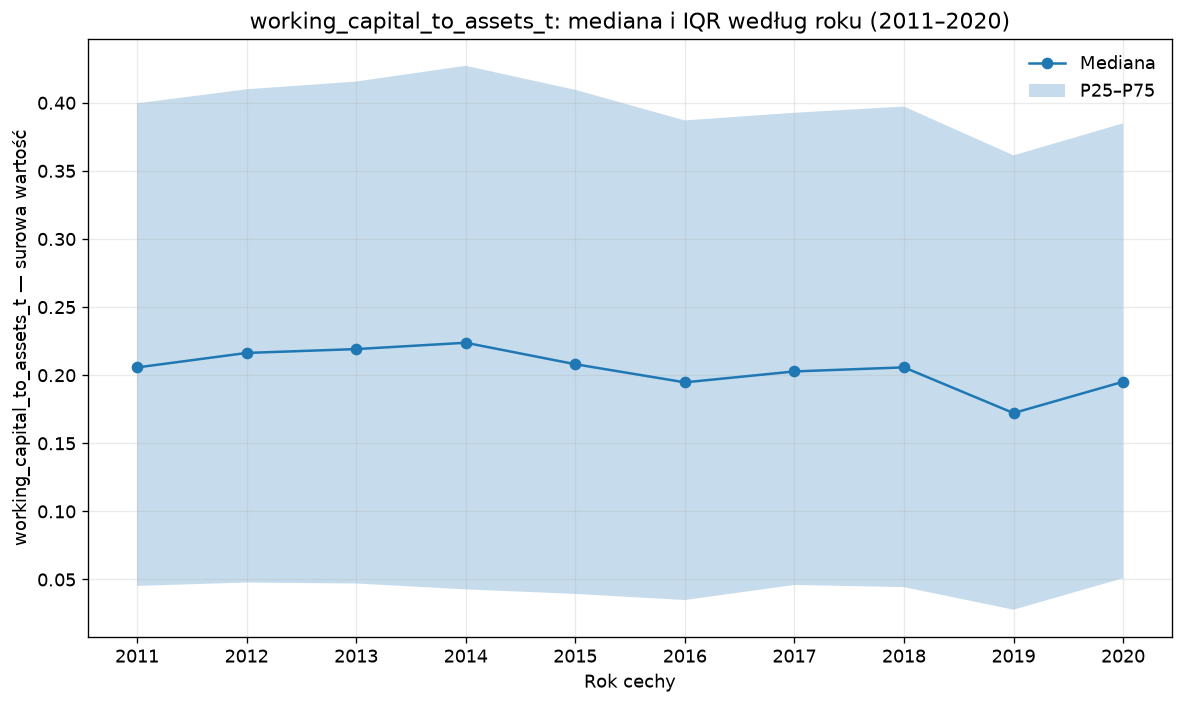

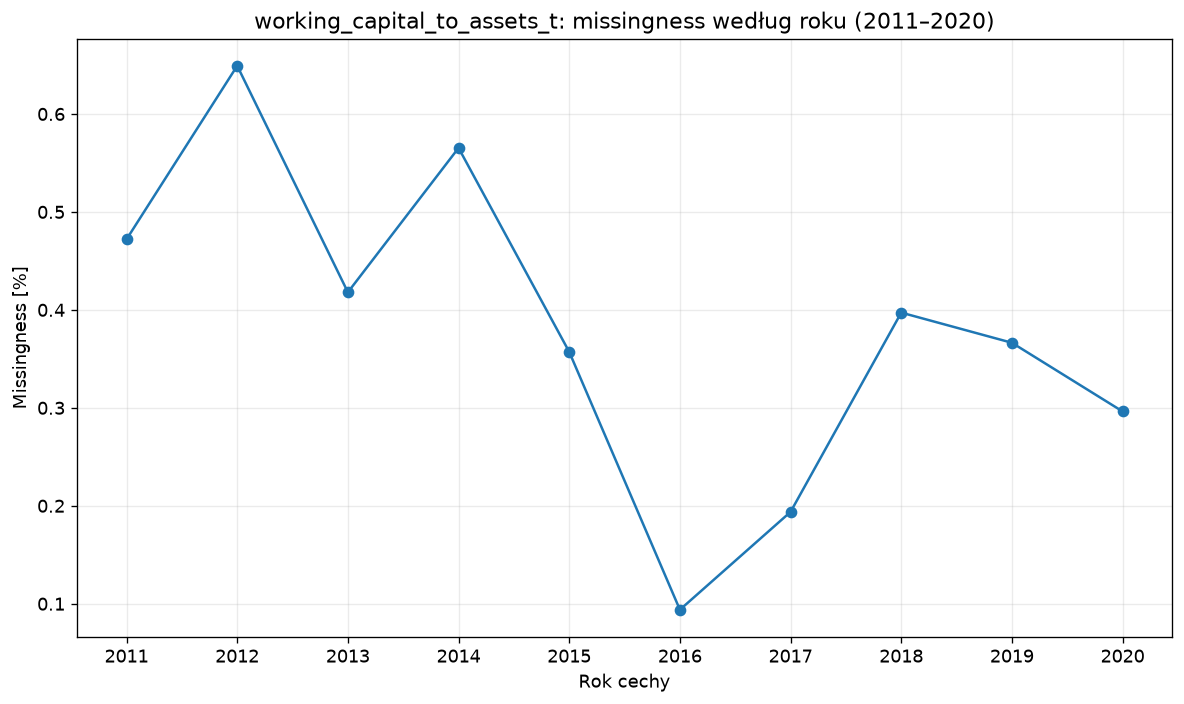

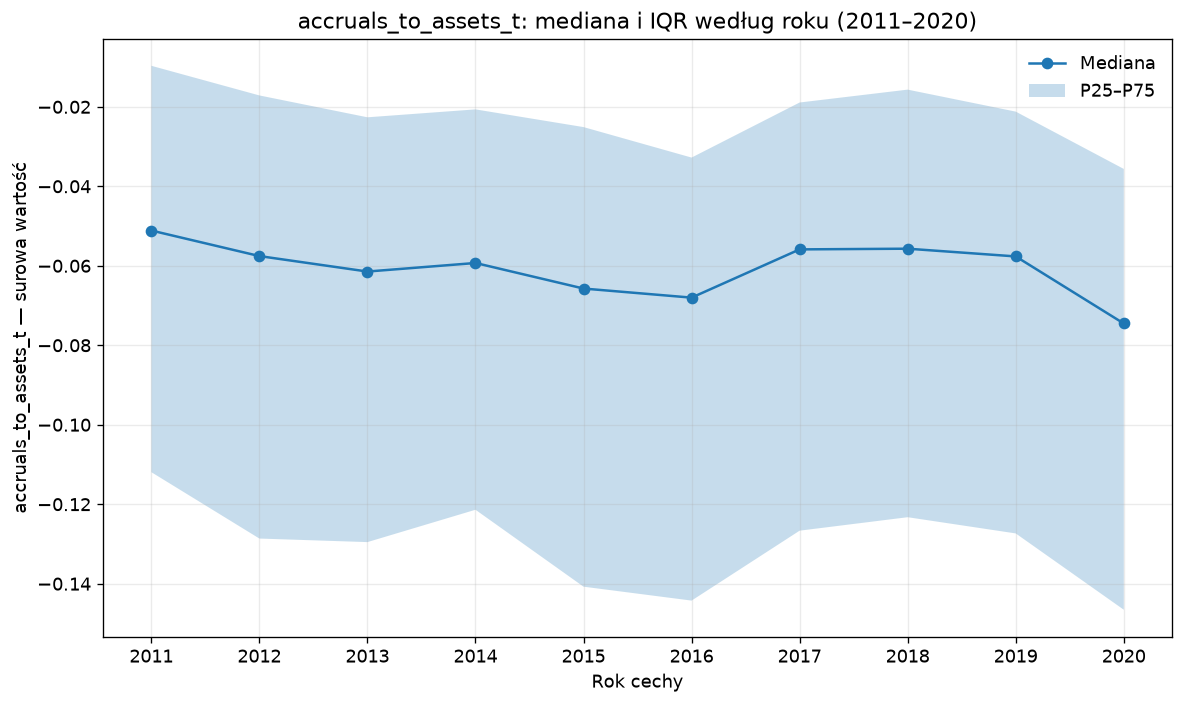

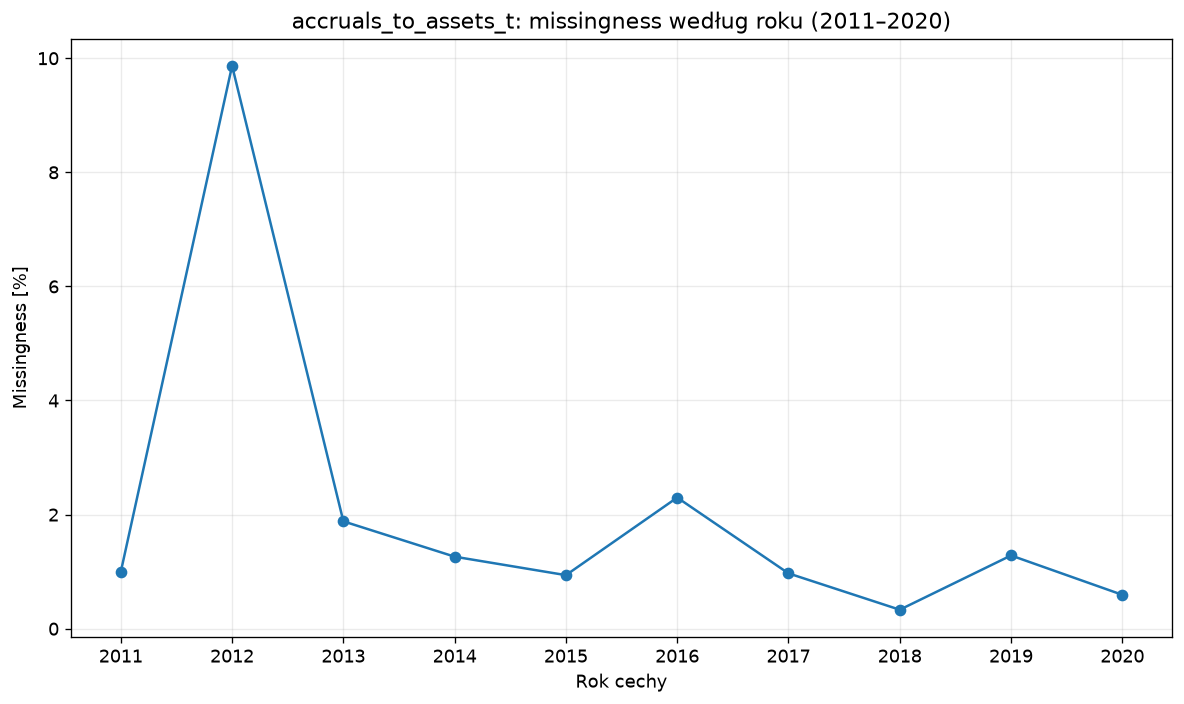

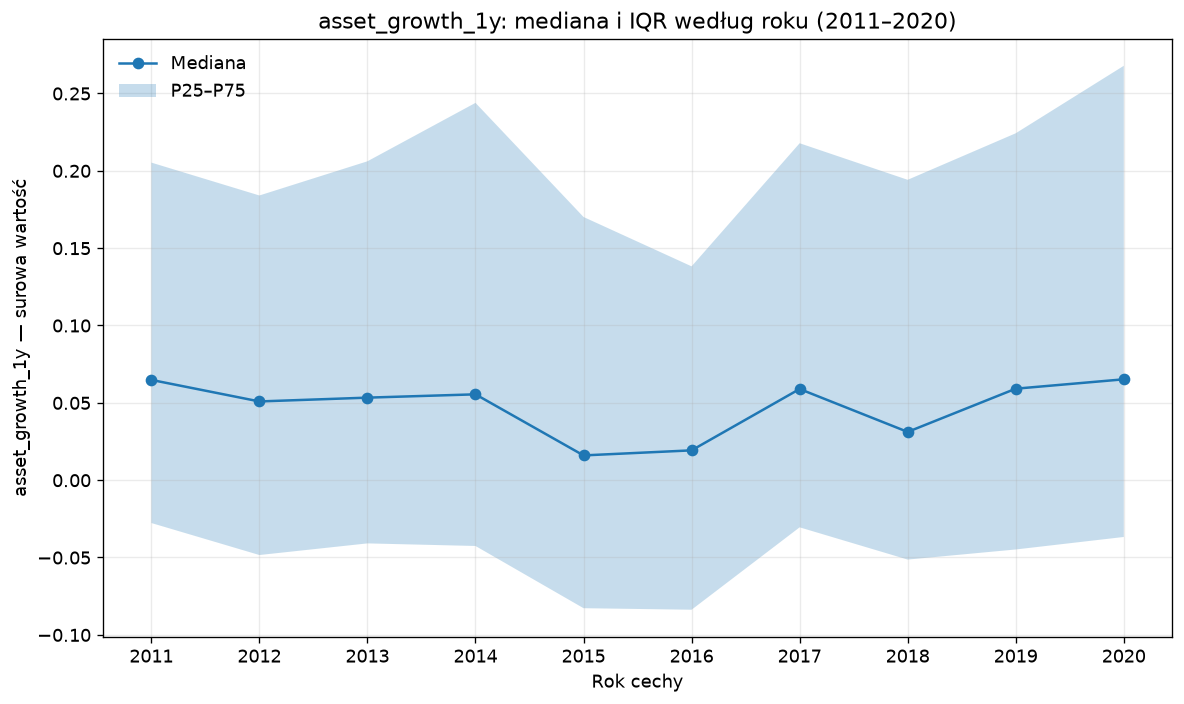

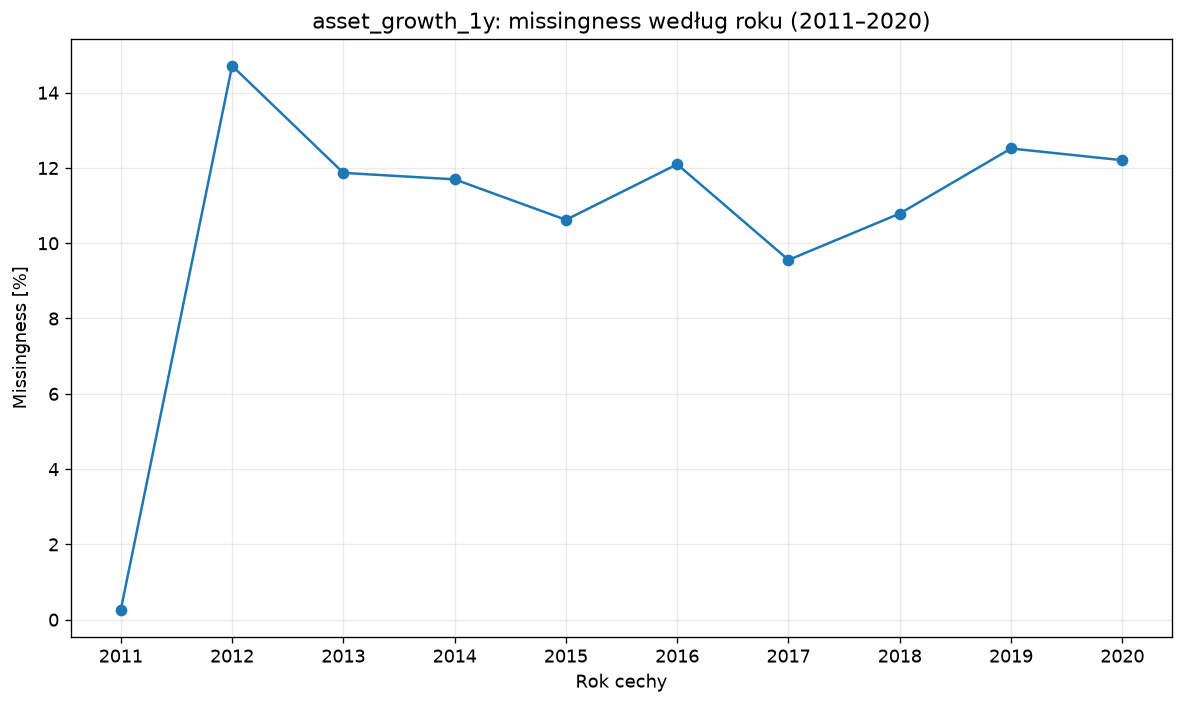

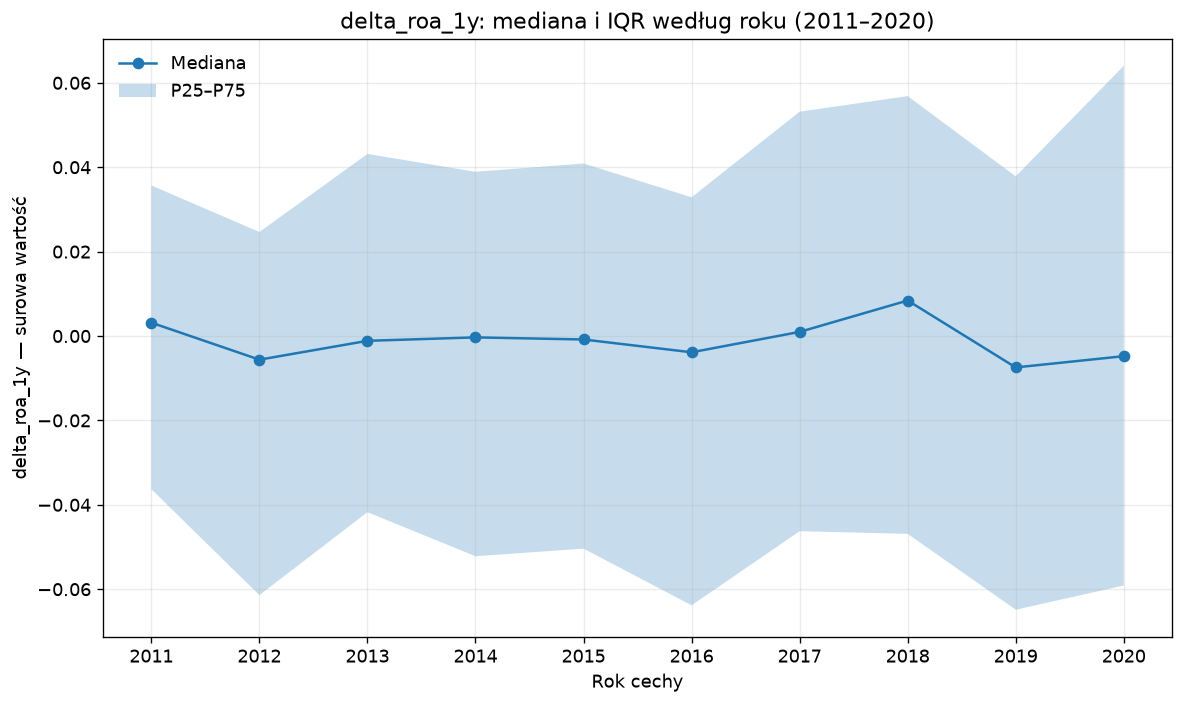

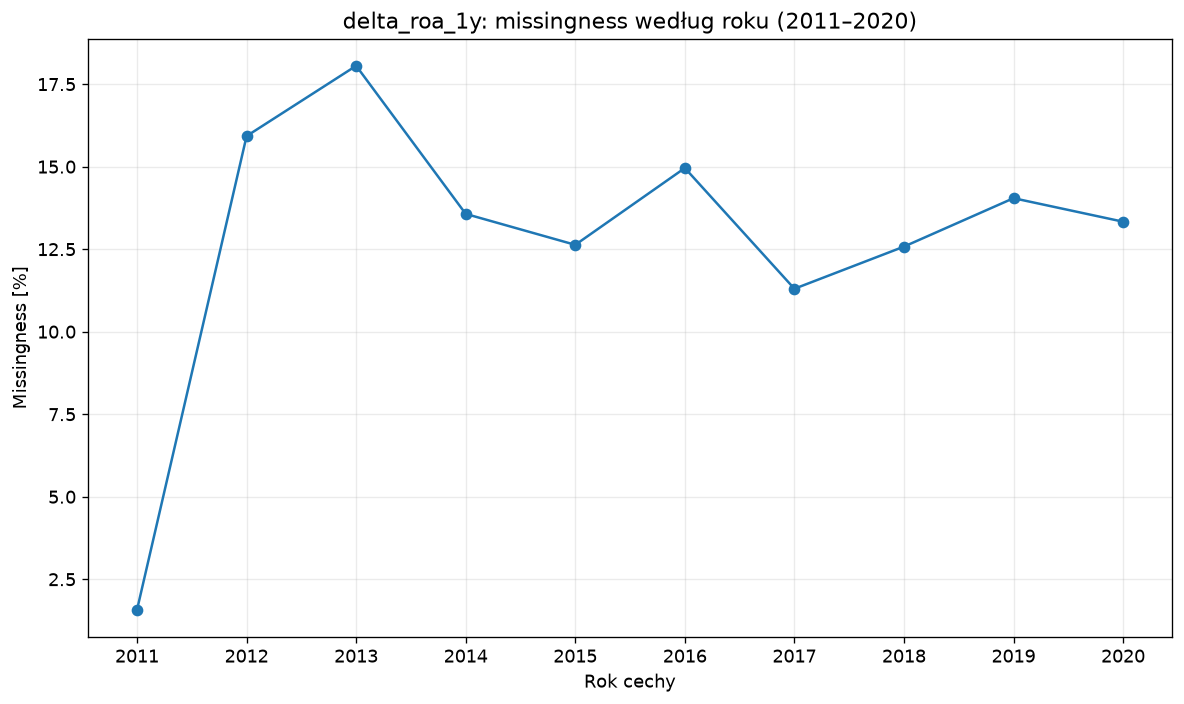

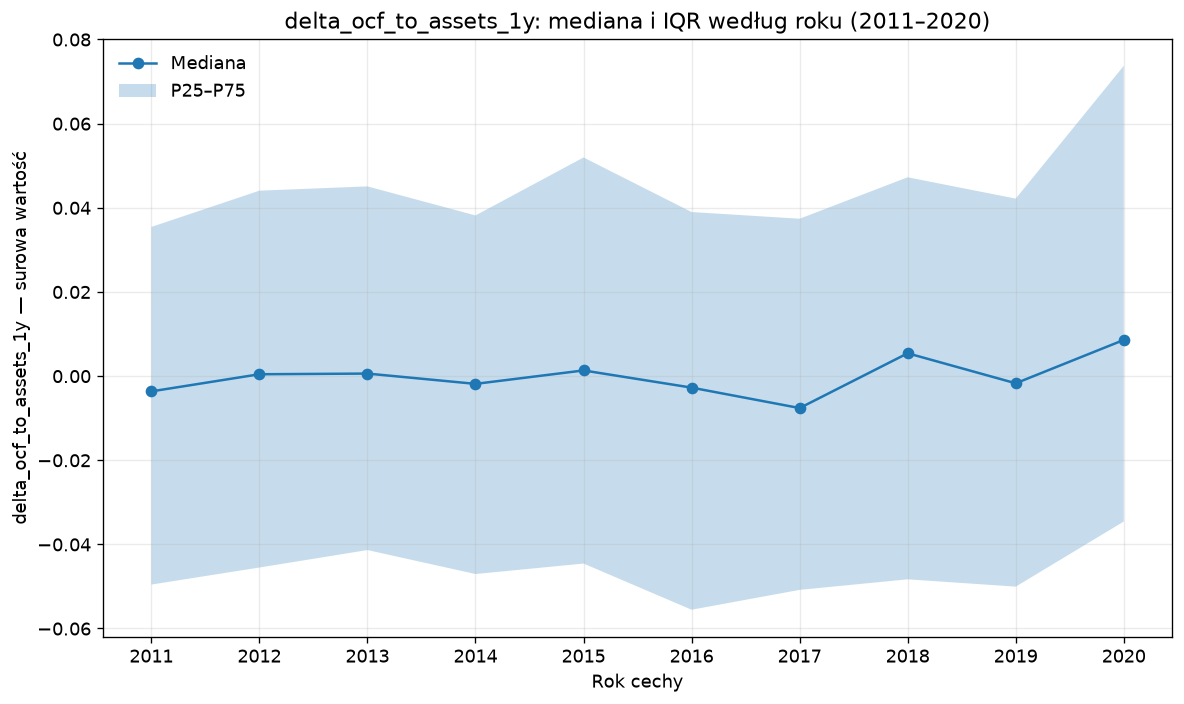

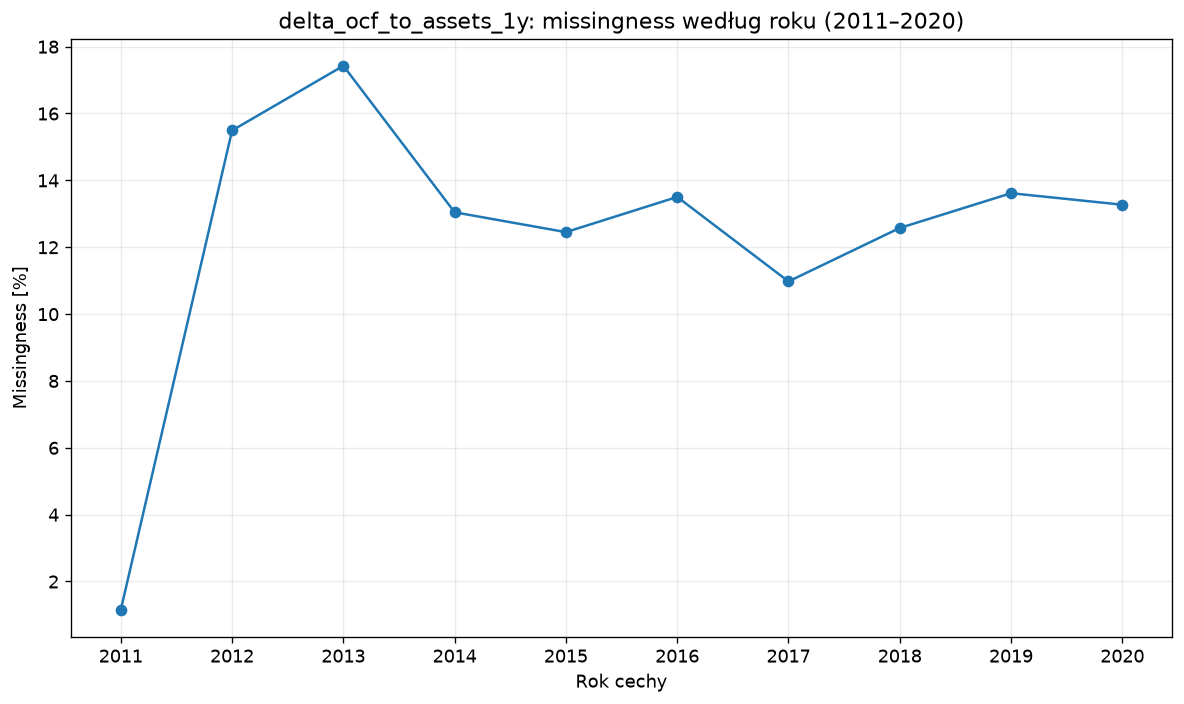

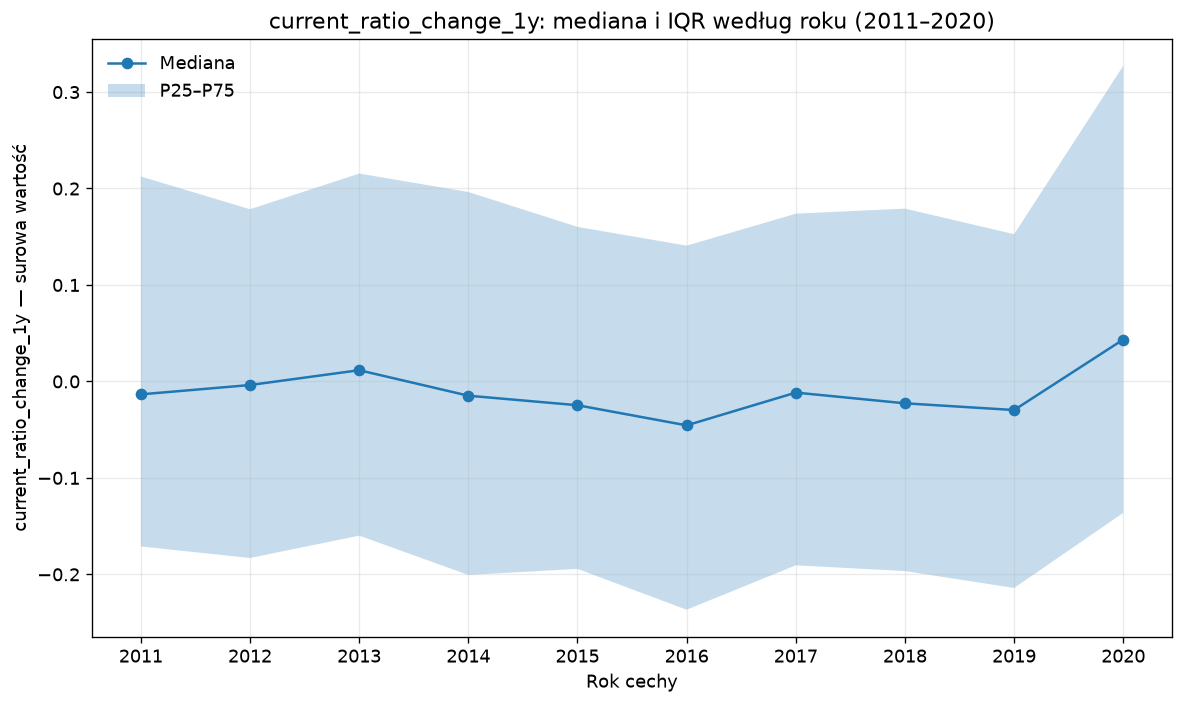

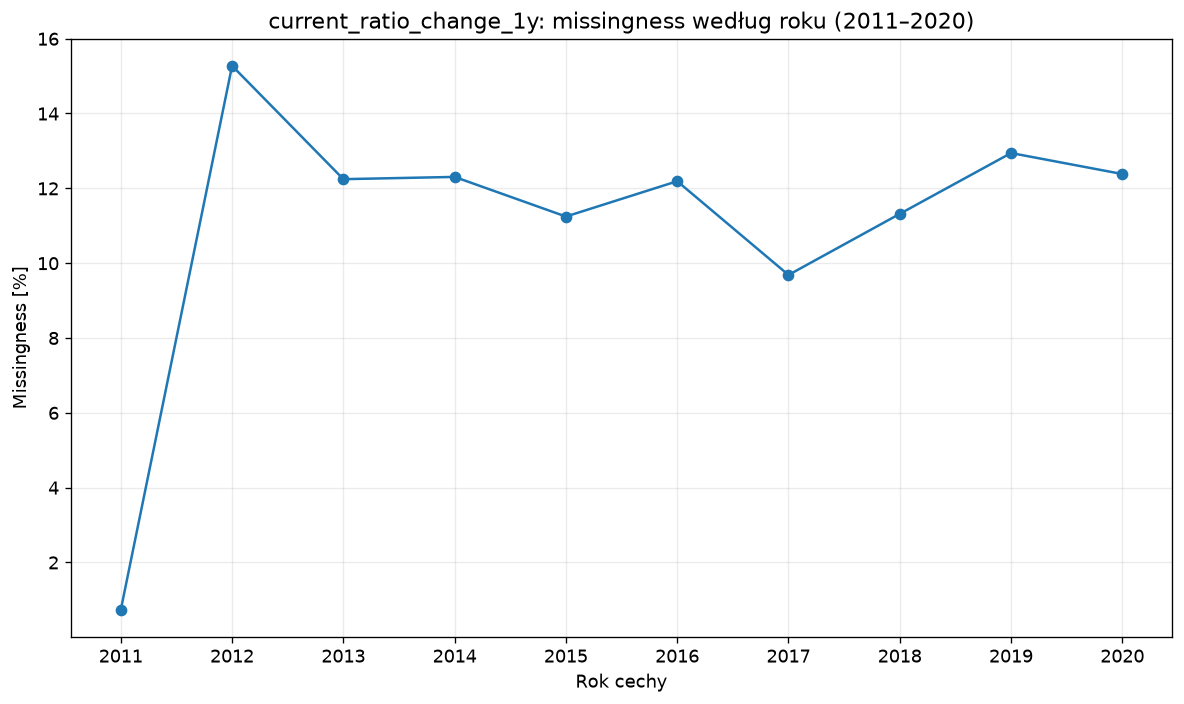

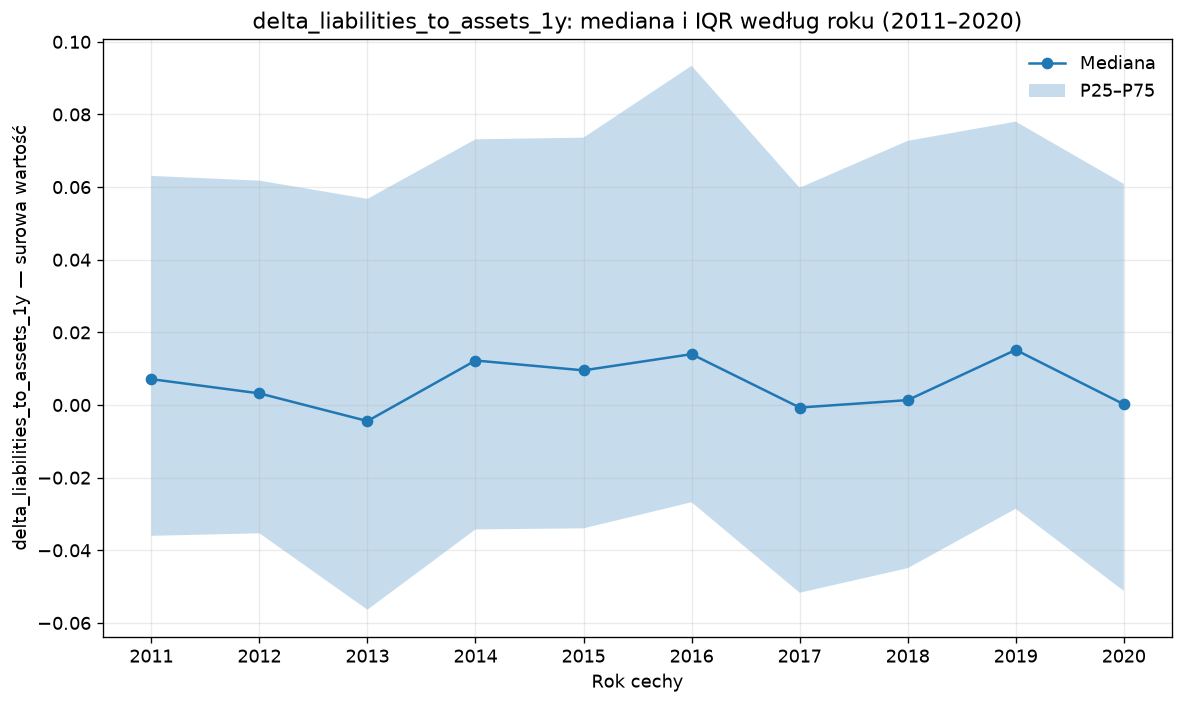

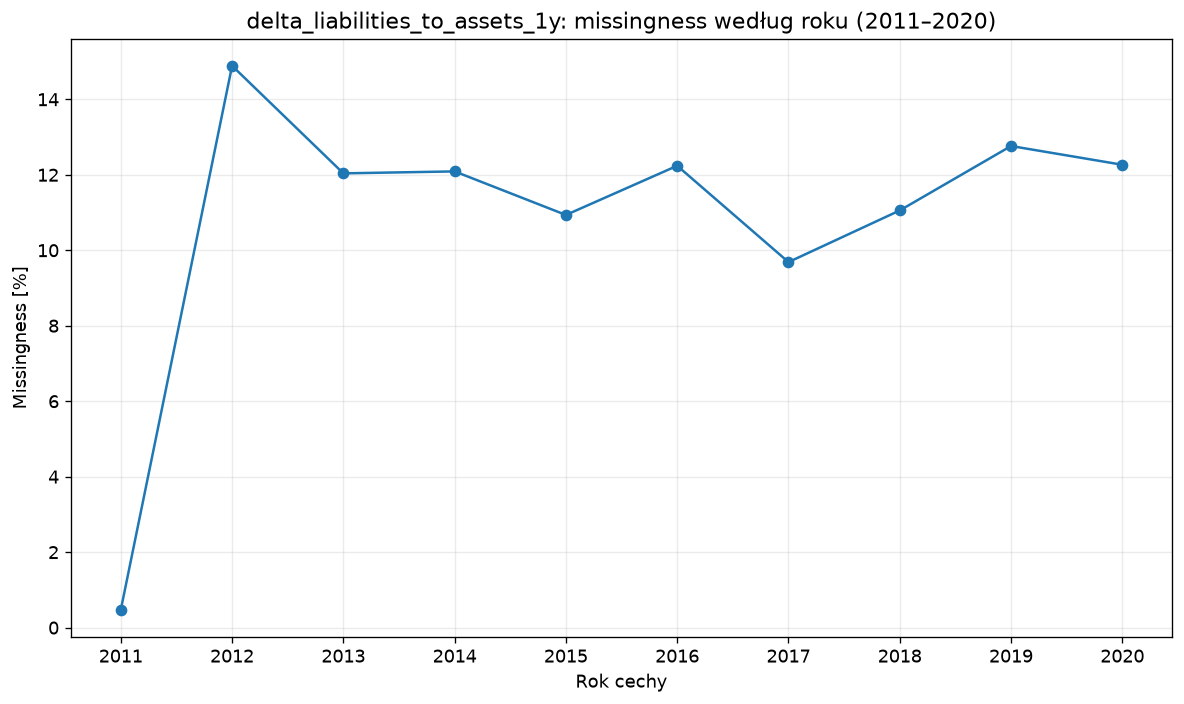

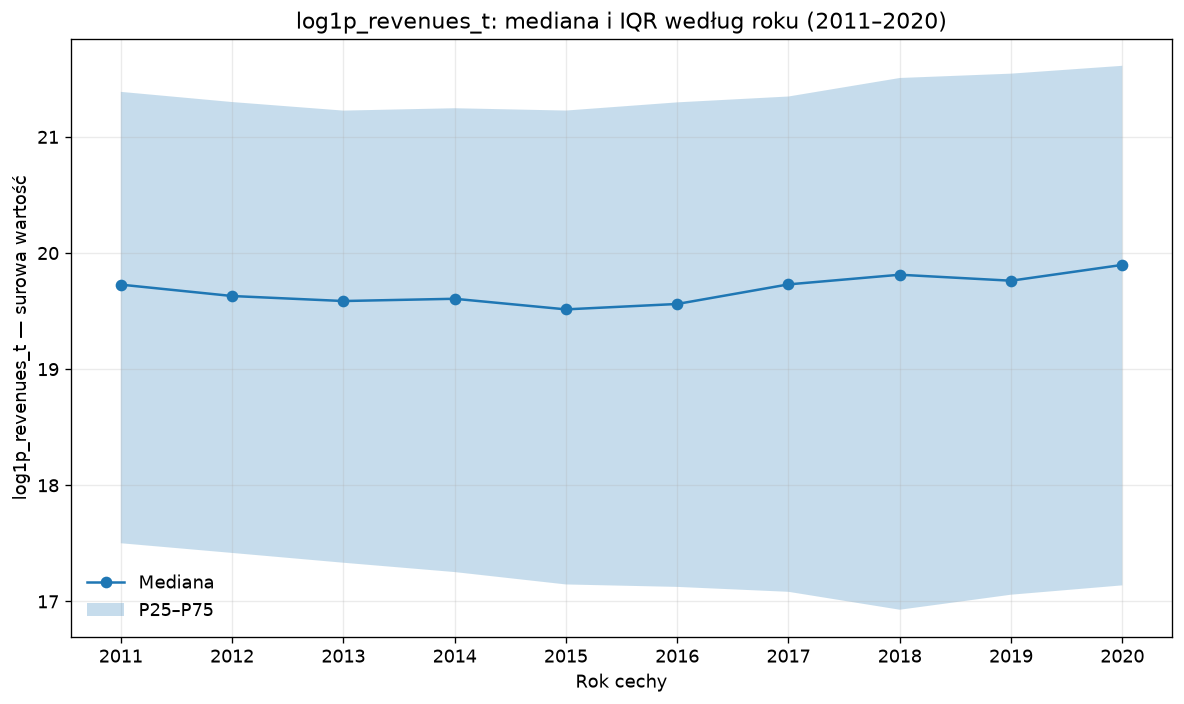

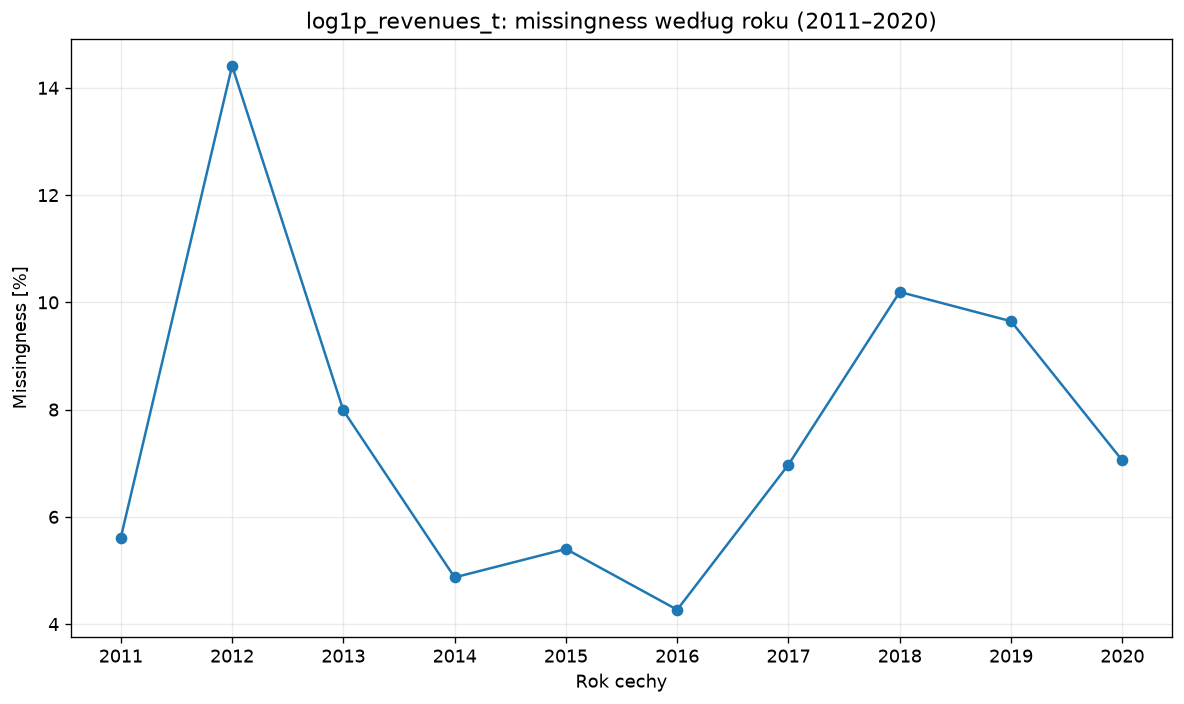

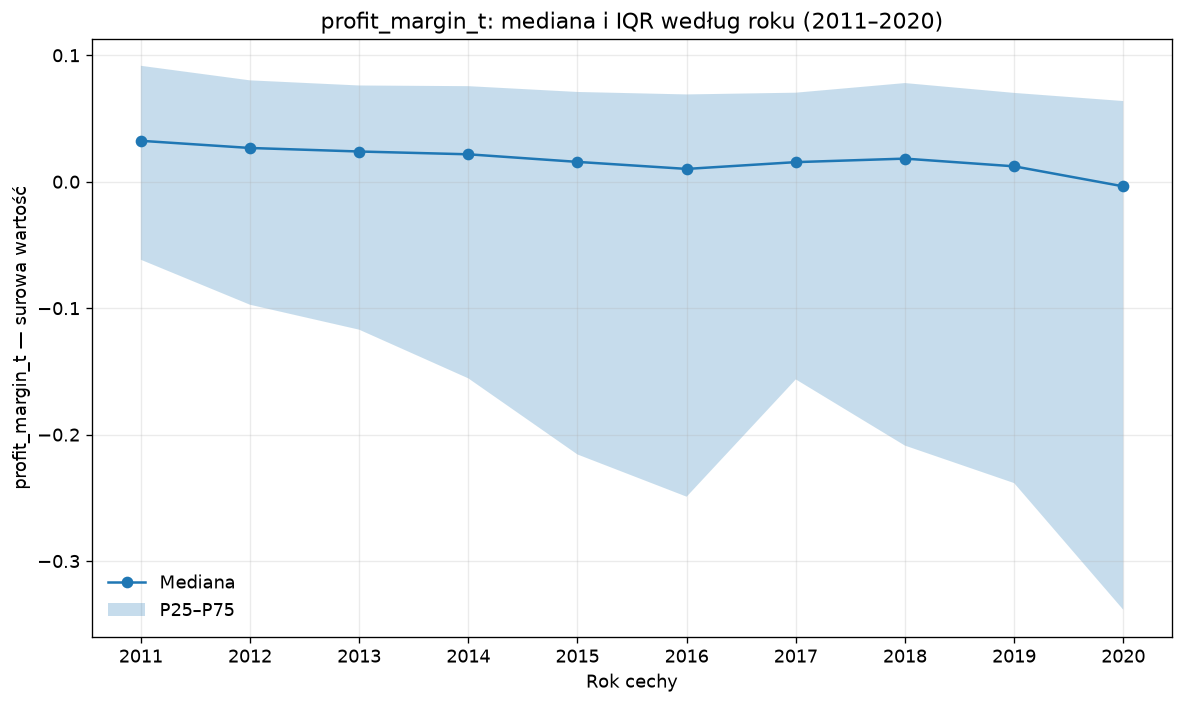

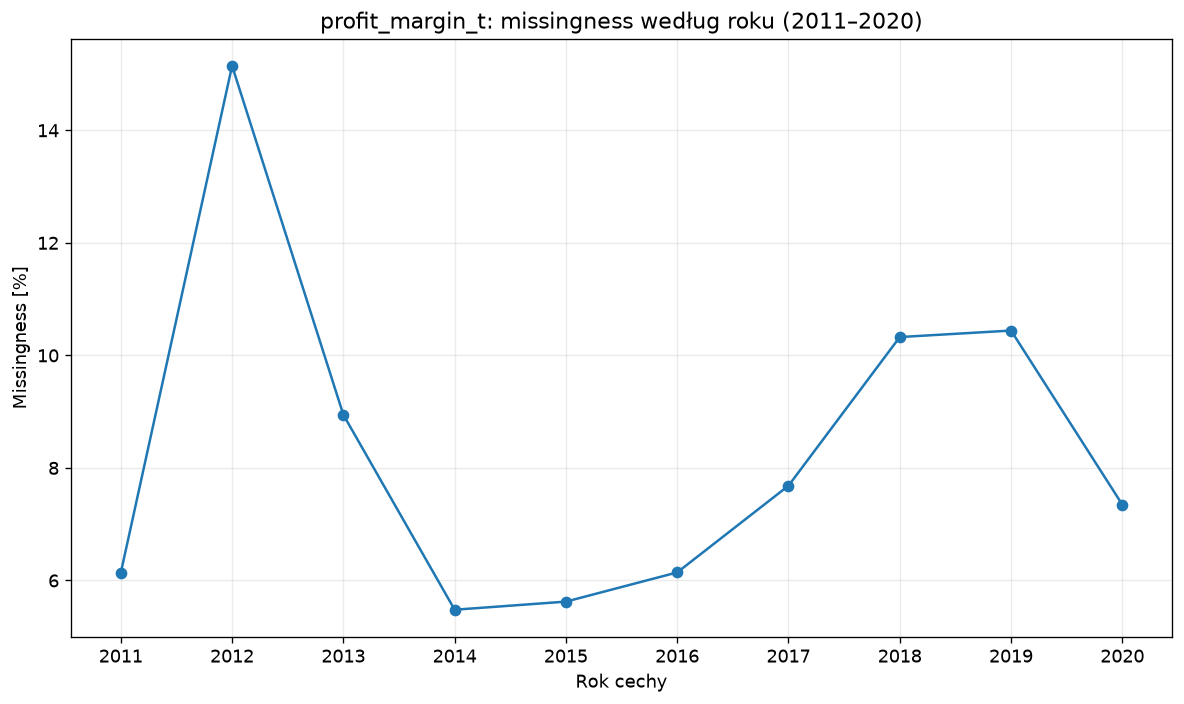

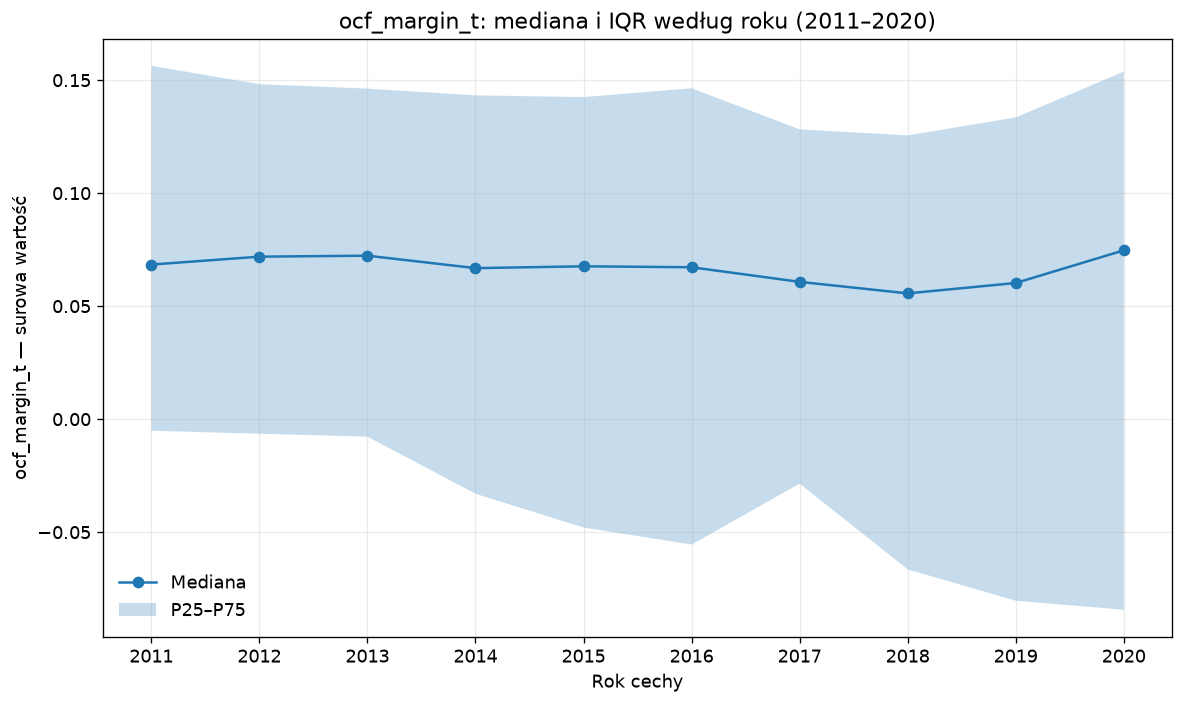

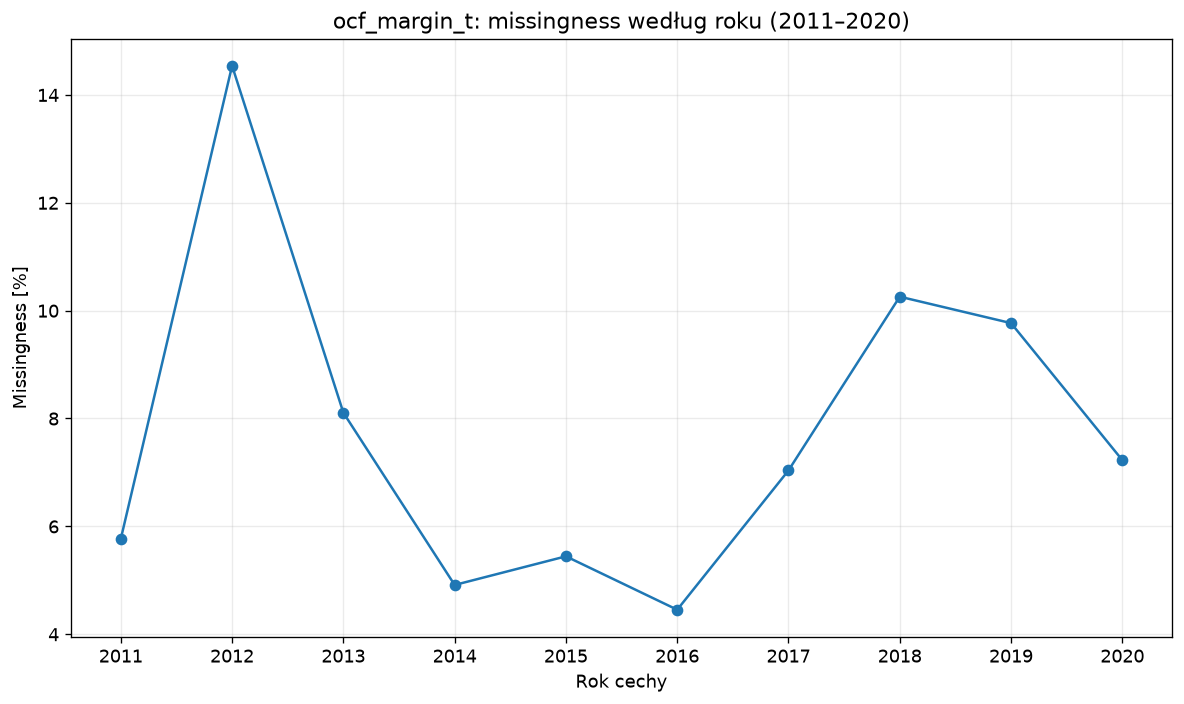

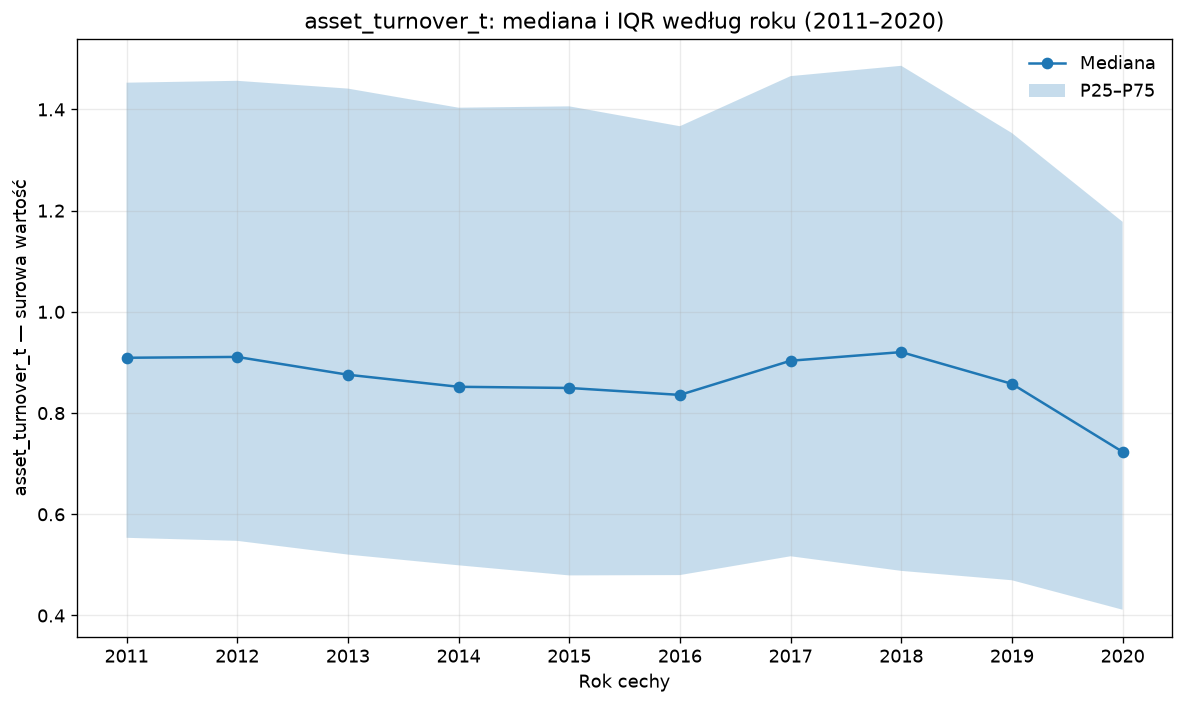

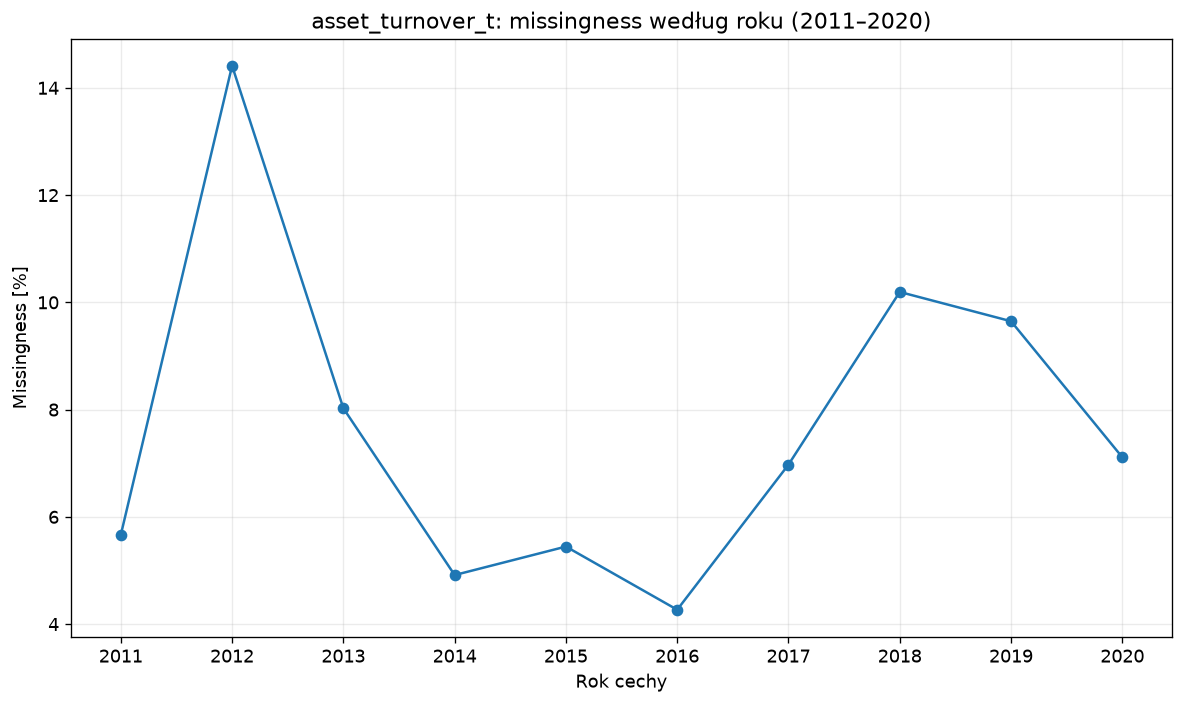

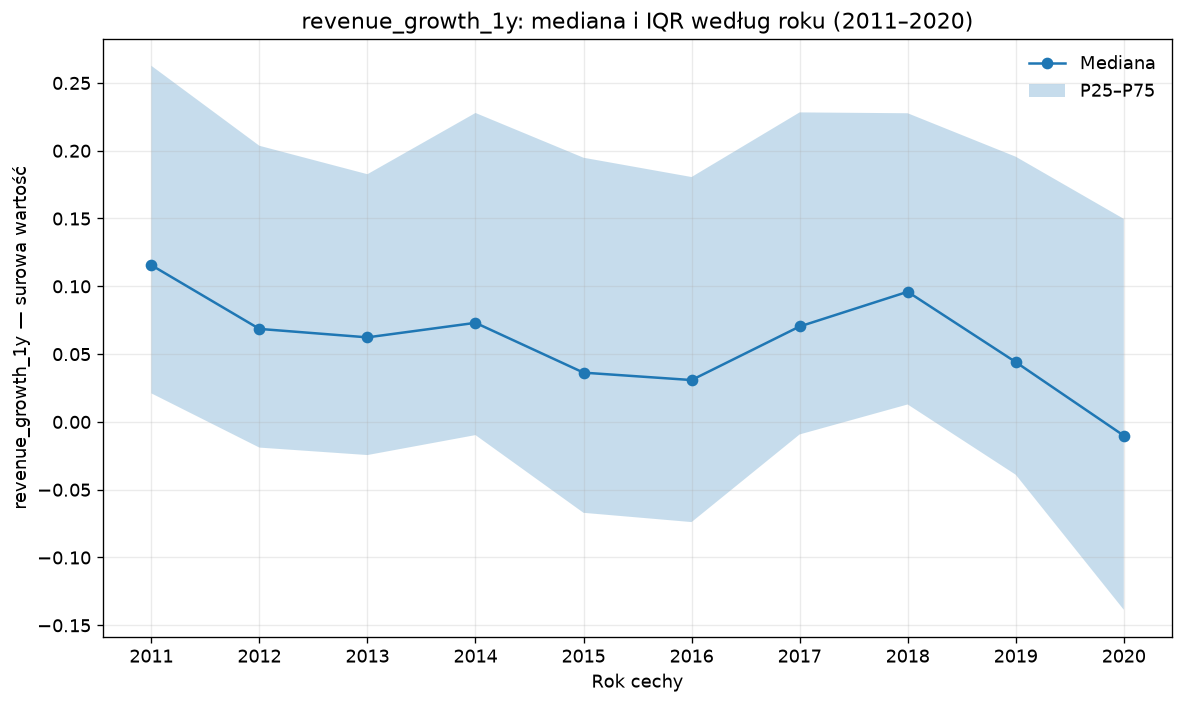

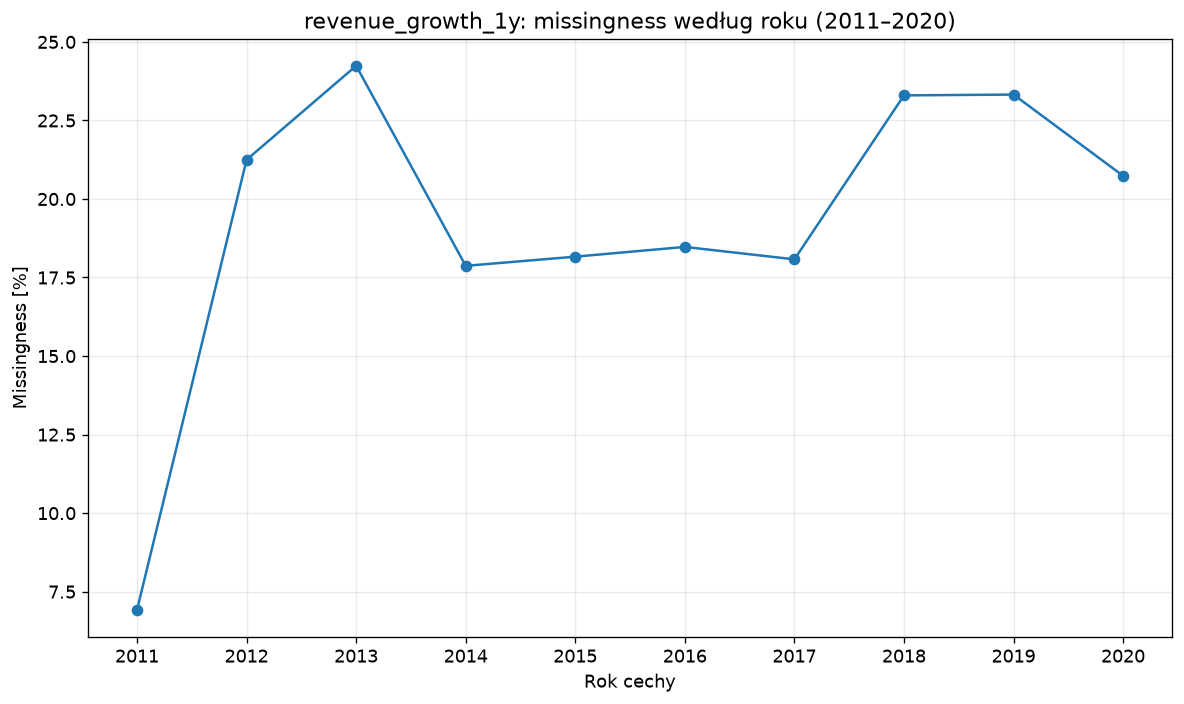

In [16]:
for feature in FEATURES:
    yearly = temporal_stats.loc[temporal_stats["cecha"].eq(feature)].sort_values(
        "feature_year"
    )
    years = yearly["feature_year"].to_numpy(dtype=int)

    fig, ax = plt.subplots()
    ax.plot(years, yearly["median"], marker="o", label="Mediana")
    ax.fill_between(
        years,
        yearly["P25"].to_numpy(dtype=float),
        yearly["P75"].to_numpy(dtype=float),
        alpha=0.25,
        label="P25–P75",
    )
    ax.set_title(f"{feature}: mediana i IQR według roku (2011–2020)")
    ax.set_xlabel("Rok cechy")
    ax.set_ylabel(f"{feature} — surowa wartość")
    ax.set_xticks(years)
    ax.legend()
    finalize_figure(fig, f"temporal_median_iqr_{slugify(feature)}.png")

    fig, ax = plt.subplots()
    ax.plot(years, yearly["missingness_pct"], marker="o")
    ax.set_title(f"{feature}: missingness według roku (2011–2020)")
    ax.set_xlabel("Rok cechy")
    ax.set_ylabel("Missingness [%]")
    ax.set_xticks(years)
    finalize_figure(fig, f"temporal_missingness_{slugify(feature)}.png")


## 3.7. Obserwacje skrajne i anomalie

Silna asymetria jest pomocniczo definiowana jako `|skewness| ≥ 2`. Ekstremalne obserwacje są liczone według reguły `1.5 × IQR`. Zera, wartości ujemne i nieskończone są raportowane bez założenia, że są błędami — ich interpretacja zależy od ekonomicznego znaczenia konkretnej cechy. EDA nie usuwa i nie winsoryzuje obserwacji.


In [17]:
def years_with_most_true(frame: pd.DataFrame, mask: pd.Series) -> tuple[str, int]:
    counts = frame.loc[mask].groupby("feature_year").size()
    if counts.empty:
        return "—", 0
    maximum = int(counts.max())
    years = ", ".join(str(int(year)) for year in counts.index[counts.eq(maximum)])
    return years, maximum


def year_with_highest_abs_skew(frame: pd.DataFrame, feature: str) -> tuple[str, float]:
    rows = []
    for year, subset in frame.groupby("feature_year", sort=True):
        finite = finite_series(subset, feature)
        if len(finite) >= 3:
            rows.append((int(year), float(finite.skew())))
    if not rows:
        return "—", np.nan
    year, value = max(rows, key=lambda item: abs(item[1]))
    return str(year), value


anomaly_summary_rows = []
anomaly_issue_rows = []
for feature in FEATURES:
    raw = pd.to_numeric(analysis_frame[feature], errors="raise")
    values = raw.to_numpy(dtype=float)
    finite_mask = pd.Series(np.isfinite(values), index=analysis_frame.index)
    finite = raw.loc[finite_mask]
    q25 = float(finite.quantile(0.25)) if len(finite) else np.nan
    q75 = float(finite.quantile(0.75)) if len(finite) else np.nan
    iqr = q75 - q25 if len(finite) else np.nan
    outlier_mask = (
        finite_mask
        & (raw.lt(q25 - 1.5 * iqr) | raw.gt(q75 + 1.5 * iqr))
        if len(finite)
        else pd.Series(False, index=analysis_frame.index)
    )
    zero_mask = finite_mask & raw.eq(0.0)
    negative_mask = finite_mask & raw.lt(0.0)
    pos_inf_mask = pd.Series(np.isposinf(values), index=analysis_frame.index)
    neg_inf_mask = pd.Series(np.isneginf(values), index=analysis_frame.index)
    skewness = float(finite.skew()) if len(finite) >= 3 else np.nan
    strong_skew = bool(np.isfinite(skewness) and abs(skewness) >= 2.0)

    issue_masks = {
        "obserwacje poza 1.5 × IQR": outlier_mask,
        "zera": zero_mask,
        "wartości ujemne": negative_mask,
        "+inf": pos_inf_mask,
        "-inf": neg_inf_mask,
    }
    issue_years = {}
    for issue, mask in issue_masks.items():
        years, max_in_year = years_with_most_true(analysis_frame, mask)
        issue_years[issue] = years
        count = int(mask.sum())
        if count > 0:
            anomaly_issue_rows.append(
                {
                    "cecha": feature,
                    "problem": issue,
                    "liczba_obserwacji": count,
                    "udzial_pct": 100.0 * count / len(analysis_frame),
                    "metryka_dodatkowa": np.nan,
                    "lata_z_najwieksza_liczba": years,
                    "maksimum_w_jednym_roku": max_in_year,
                }
            )
    skew_year, skew_year_value = year_with_highest_abs_skew(analysis_frame, feature)
    if strong_skew:
        anomaly_issue_rows.append(
            {
                "cecha": feature,
                "problem": "silna asymetria |skewness| ≥ 2",
                "liczba_obserwacji": len(finite),
                "udzial_pct": 100.0 * len(finite) / len(analysis_frame),
                "metryka_dodatkowa": skewness,
                "lata_z_najwieksza_liczba": skew_year,
                "maksimum_w_jednym_roku": skew_year_value,
            }
        )

    anomaly_summary_rows.append(
        {
            "cecha": feature,
            "blok": FEATURE_TO_BLOCK[feature],
            "n_finite": len(finite),
            "skewness": skewness,
            "strong_skew_flag": strong_skew,
            "n_outside_1_5_IQR": int(outlier_mask.sum()),
            "outside_1_5_IQR_pct": 100.0 * outlier_mask.mean(),
            "outlier_peak_years": issue_years["obserwacje poza 1.5 × IQR"],
            "n_zero": int(zero_mask.sum()),
            "zero_pct": 100.0 * zero_mask.mean(),
            "zero_peak_years": issue_years["zera"],
            "n_negative": int(negative_mask.sum()),
            "negative_pct": 100.0 * negative_mask.mean(),
            "negative_peak_years": issue_years["wartości ujemne"],
            "n_pos_inf": int(pos_inf_mask.sum()),
            "n_neg_inf": int(neg_inf_mask.sum()),
        }
    )

anomaly_summary = pd.DataFrame(anomaly_summary_rows).set_index("cecha").loc[FEATURES]
anomaly_issues = pd.DataFrame(anomaly_issue_rows)
if not anomaly_issues.empty:
    anomaly_issues = anomaly_issues.sort_values(
        ["problem", "udzial_pct", "cecha"], ascending=[True, False, True]
    ).reset_index(drop=True)

save_table(anomaly_summary, "44_anomaly_summary_by_feature.csv")
save_table(anomaly_issues, "45_anomaly_issues_long.csv", index=False)

show_table("Zbiorcza diagnostyka asymetrii, ekstremów, zer i wartości ujemnych", anomaly_summary)
show_table("Lista potencjalnych problemów wraz z liczebnością i latami koncentracji", anomaly_issues)
display(
    Markdown(
        "**Decyzja EDA:** żadna obserwacja nie została usunięta ani winsoryzowana "
        "na podstawie powyższych wyników."
    )
)


#### Zbiorcza diagnostyka asymetrii, ekstremów, zer i wartości ujemnych

,blok,n_finite,skewness,strong_skew_flag,n_outside_1_5_IQR,outside_1_5_IQR_pct,outlier_peak_years,n_zero,zero_pct,zero_peak_years,n_negative,negative_pct,negative_peak_years,n_pos_inf,n_neg_inf
cecha,,,,,,,,,,,,,,,
log_assets_t,L,19666,-0.6301,False,275,1.3980,2014,0,0.0000,—,0,0.0000,—,0,0
roa_t,L,19261,-123.6704,True,2918,14.8340,2015,2,0.0102,"2011, 2012",8346,42.4279,2015,0,0
ocf_to_assets_t,L,19376,-89.7573,True,2785,14.1579,2016,1,0.0051,2014,5775,29.3579,2014,0,0
current_ratio_t,L,19596,26.2943,True,1624,8.2558,2015,0,0.0000,—,0,0.0000,—,0,0
liabilities_to_assets_t,L,19637,131.4818,True,1588,8.0728,2015,1,0.0051,2011,0,0.0000,—,0,0
working_capital_to_assets_t,L,19594,-131.7812,True,1420,7.2187,2015,1,0.0051,2014,3759,19.1093,2013,0,0
accruals_to_assets_t,L,19229,-124.3482,True,2867,14.5748,2015,3,0.0153,2013,16218,82.4462,2013,0,0
asset_growth_1y,D,17555,75.0741,True,2656,13.5021,2014,2,0.0102,"2018, 2020",6487,32.9775,2015,0,0
delta_roa_1y,D,17107,67.3547,True,4084,20.7615,2013,2,0.0102,"2011, 2012",8790,44.6851,2012,0,0


#### Lista potencjalnych problemów wraz z liczebnością i latami koncentracji

,cecha,problem,liczba_obserwacji,udzial_pct,metryka_dodatkowa,lata_z_najwieksza_liczba,maksimum_w_jednym_roku
0,delta_roa_1y,obserwacje poza 1.5 × IQR,4084,20.7615,NaN,2013,484.0000
1,ocf_margin_t,obserwacje poza 1.5 × IQR,3351,17.0352,NaN,2015,425.0000
2,delta_liabilities_to_assets_1y,obserwacje poza 1.5 × IQR,3270,16.6235,NaN,2014,405.0000
3,profit_margin_t,obserwacje poza 1.5 × IQR,3232,16.4303,NaN,2015,432.0000
4,delta_ocf_to_assets_1y,obserwacje poza 1.5 × IQR,3126,15.8914,NaN,2014,374.0000
5,roa_t,obserwacje poza 1.5 × IQR,2918,14.8340,NaN,2015,355.0000
6,accruals_to_assets_t,obserwacje poza 1.5 × IQR,2867,14.5748,NaN,2015,353.0000
7,ocf_to_assets_t,obserwacje poza 1.5 × IQR,2785,14.1579,NaN,2016,349.0000
8,asset_growth_1y,obserwacje poza 1.5 × IQR,2656,13.5021,NaN,2014,359.0000
9,revenue_growth_1y,obserwacje poza 1.5 × IQR,2206,11.2145,NaN,2015,290.0000


**Decyzja EDA:** żadna obserwacja nie została usunięta ani winsoryzowana na podstawie powyższych wyników.

## 3.8. Podsumowanie EDA

Poniższy tekst jest generowany automatycznie z tabel obliczonych wyłącznie na próbie 2011–2020. Jego celem jest dostarczenie zwartego, ostrożnego opisu możliwego do wykorzystania po redakcji w pracy magisterskiej.


In [18]:
def format_feature_values(table: pd.DataFrame, value_column: str, n: int = 3) -> str:
    if table.empty:
        return "brak"
    selected = table.nlargest(n, value_column)
    return ", ".join(
        f"{feature} ({row[value_column]:.1f})" for feature, row in selected.iterrows()
    )


def correlation_sentence() -> str:
    if top_10_spearman.empty or pd.isna(top_10_spearman.iloc[0]["r"]):
        return "Nie można było wyznaczyć korelacji dla żadnej pary cech."
    strongest = top_10_spearman.iloc[0]
    return (
        f"Najsilniejsza para Spearmana to `{strongest['cecha_1']}` i "
        f"`{strongest['cecha_2']}` (rho={strongest['r']:.3f}, "
        f"n={int(strongest['n_wspolnych_obserwacji']):,}). "
        f"Liczba par z |rho|>0,8 wyniosła {len(spearman_over_08)}, "
        f"a z |rho|>0,9: {len(spearman_over_09)}."
    )


def vif_sentence() -> str:
    finite_vif = vif_table.loc[np.isfinite(vif_table["VIF"]), "VIF"].dropna()
    infinite_features = vif_table.index[np.isinf(vif_table["VIF"].to_numpy(dtype=float))].tolist()
    parts = []
    if not finite_vif.empty:
        feature = finite_vif.idxmax()
        parts.append(f"najwyższy skończony VIF: `{feature}` = {finite_vif.max():.2f}")
    if infinite_features:
        parts.append("VIF nieskończony: " + ", ".join(f"`{f}`" for f in infinite_features))
    return "; ".join(parts) if parts else "VIF nie był dostępny."


def quoted_features(features: list[str]) -> str:
    return ", ".join(f"`{feature}`" for feature in features) if features else "brak"


positive_rate = 100.0 * analysis_frame["target"].mean()
top_missing_text = format_feature_values(feature_missingness, "missingness_pct", n=3)
strong_skew_features = anomaly_summary.index[anomaly_summary["strong_skew_flag"]].tolist()
flagged_distribution = temporal_diagnostics.index[
    temporal_diagnostics["silna_zmiana_rozkladu_flag"]
].tolist()
flagged_availability = temporal_diagnostics.index[
    temporal_diagnostics["silna_zmiana_dostepnosci_flag"]
].tolist()
inf_total = int(feature_quality["n_pos_inf"].sum() + feature_quality["n_neg_inf"].sum())
near_zero_features = variance_check.index[variance_check["near_zero_variance"]].tolist()
size_missing_n = int(analysis_frame["size_quartile"].eq("Brak lub niedodatnie aktywa").sum())

summary_markdown = f"""
### Podsumowanie klasycznego EDA — train 2011–2020

1. **Najważniejsze cechy próby.** Analiza obejmuje **{len(analysis_frame):,}** obserwacji company-year z lat **{analysis_frame['feature_year'].min()}–{analysis_frame['feature_year'].max()}**, dotyczących **{analysis_frame['company_id'].nunique():,}** unikalnych spółek (CIK) i **{analysis_frame['economic_group_id'].nunique(dropna=True):,}** grup ekonomicznych. Mediana liczby obserwacji na spółkę wynosi {company_panel['observations'].median():.1f}. Dla {size_missing_n:,} obserwacji nie można było przypisać kwartyla wielkości z powodu braku lub niedodatniej wartości aktywów; wiersze te pozostały w próbie.

2. **Niezbalansowanie targetu.** Klasa pozytywna obejmuje **{int(analysis_frame['target'].sum()):,}** obserwacji, czyli **{positive_rate:.2f}%** próby, wobec **{int(analysis_frame['target'].eq(0).sum()):,}** obserwacji klasy negatywnej. Rozkład należy uwzględnić przy interpretacji późniejszych metryk modelowych, lecz EDA nie zmienia polityki próby ani strategii modelowania.

3. **Missingness.** Najwyższy udział braków odnotowano dla: {top_missing_text} — wartości w nawiasach oznaczają procent braków. Rozkład liczby dostępnych cech oraz przekroje roczne, sektorowe, wielkościowe, targetowe i XBRL zostały zapisane w tabelach 20–29. Podstawowe statystyki nie wykorzystują imputacji.

4. **Rozkłady cech.** Cechy z pomocniczą flagą silnej asymetrii `|skewness|≥2` to: {quoted_features(strong_skew_features)}. Obserwacje poza `1.5×IQR`, zera i wartości ujemne zostały policzone dla każdej cechy, bez automatycznego uznawania ich za błędne i bez usuwania lub winsoryzacji.

5. **Najsilniejsze korelacje.** {correlation_sentence()} Korelacje mają charakter opisowy i nie są interpretowane przyczynowo.

6. **Potencjalna współliniowość.** {vif_sentence()}. Cechy stałe lub near-zero variance według jawnej diagnostyki: {quoted_features(near_zero_features)}. VIF wykorzystuje wyłącznie techniczną, lokalną imputację medianą i nie zmienia właściwego preprocessingu.

7. **Zmiany w czasie.** Pomocniczą flagę silnej zmiany rocznych median otrzymały: {quoted_features(flagged_distribution)}. Flagę zmiany dostępności danych otrzymały: {quoted_features(flagged_availability)}. Diagnostyka opisuje temporal drift w latach 2011–2020 i nie prowadzi do modyfikacji zestawu cech.

8. **Jakość danych.** W finalnej próbie wykryto {int(canonical_duplicate_mask.sum())} wierszy ze zduplikowanym kluczem kanonicznym, {int(cik_year_duplicate_mask.sum())} wierszy ze zduplikowanym kluczem `CIK×year` oraz łącznie {inf_total} wartości `+inf/-inf` w 17 cechach. Wszystkie pominięcia wymagane przez konkretne statystyki zostały ujawnione w tabelach.

9. **Ograniczenia interpretacyjne.** EDA jest analizą opisową próby warunkowej względem dostępnego targetu i zaakceptowanego statusu `X_t`. Dane mają strukturę panelową, rozkłady mogą być silnie skośne, a braki mogą nie być losowe. Wyniki nie dowodzą zależności przyczynowych, nie uzasadniają selekcji cech i nie zawierają żadnej informacji z lat 2021–2024.
""".strip()

summary_path = OUTPUT_ROOT / "eda_summary.md"
if SAVE_OUTPUTS:
    summary_path.write_text(summary_markdown + "\n", encoding="utf-8")

reproducibility = pd.DataFrame(
    {
        "wartosc": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            scipy.__version__,
            current_config["supervised_ml_pipeline"]["version"],
            str(PATHS["x_t"].relative_to(ROOT)),
            fingerprints["x_t"]["sha256"],
            str(PATHS["target_application"].relative_to(ROOT)),
            fingerprints["target_application"]["sha256"],
            RANDOM_SEED,
            YEAR_MIN,
            YEAR_MAX,
            len(FEATURES),
        ]
    },
    index=[
        "Python",
        "pandas",
        "numpy",
        "scipy",
        "pipeline overlay",
        "X_t artifact",
        "X_t SHA-256",
        "target-application artifact",
        "target-application SHA-256",
        "random seed",
        "minimalny rok EDA",
        "maksymalny rok EDA",
        "liczba cech",
    ],
)
save_table(reproducibility, "46_reproducibility.csv")

display(Markdown(summary_markdown))
show_table("Informacje reprodukowalności", reproducibility)

if SAVE_OUTPUTS:
    table_count = len(list(TABLE_DIR.glob("*.csv")))
    figure_count = len(list(FIGURE_DIR.glob("*.png")))
    print(
        f"Zapisano {table_count} tabel CSV, {figure_count} wykresów PNG oraz "
        f"podsumowanie Markdown w {OUTPUT_ROOT.relative_to(ROOT)}."
    )


### Podsumowanie klasycznego EDA — train 2011–2020

1. **Najważniejsze cechy próby.** Analiza obejmuje **19,671** obserwacji company-year z lat **2011–2020**, dotyczących **4,426** unikalnych spółek (CIK) i **4,418** grup ekonomicznych. Mediana liczby obserwacji na spółkę wynosi 4.0. Dla 5 obserwacji nie można było przypisać kwartyla wielkości z powodu braku lub niedodatniej wartości aktywów; wiersze te pozostały w próbie.

2. **Niezbalansowanie targetu.** Klasa pozytywna obejmuje **3,623** obserwacji, czyli **18.42%** próby, wobec **16,048** obserwacji klasy negatywnej. Rozkład należy uwzględnić przy interpretacji późniejszych metryk modelowych, lecz EDA nie zmienia polityki próby ani strategii modelowania.

3. **Missingness.** Najwyższy udział braków odnotowano dla: revenue_growth_1y (19.2), delta_roa_1y (13.0), delta_ocf_to_assets_1y (12.6) — wartości w nawiasach oznaczają procent braków. Rozkład liczby dostępnych cech oraz przekroje roczne, sektorowe, wielkościowe, targetowe i XBRL zostały zapisane w tabelach 20–29. Podstawowe statystyki nie wykorzystują imputacji.

4. **Rozkłady cech.** Cechy z pomocniczą flagą silnej asymetrii `|skewness|≥2` to: `roa_t`, `ocf_to_assets_t`, `current_ratio_t`, `liabilities_to_assets_t`, `working_capital_to_assets_t`, `accruals_to_assets_t`, `asset_growth_1y`, `delta_roa_1y`, `delta_ocf_to_assets_1y`, `current_ratio_change_1y`, `delta_liabilities_to_assets_1y`, `profit_margin_t`, `ocf_margin_t`, `asset_turnover_t`, `revenue_growth_1y`. Obserwacje poza `1.5×IQR`, zera i wartości ujemne zostały policzone dla każdej cechy, bez automatycznego uznawania ich za błędne i bez usuwania lub winsoryzacji.

5. **Najsilniejsze korelacje.** Najsilniejsza para Spearmana to `log_assets_t` i `log1p_revenues_t` (rho=0.957, n=18,172). Liczba par z |rho|>0,8 wyniosła 4, a z |rho|>0,9: 3. Korelacje mają charakter opisowy i nie są interpretowane przyczynowo.

6. **Potencjalna współliniowość.** najwyższy skończony VIF: `roa_t` = 839174.35. Cechy stałe lub near-zero variance według jawnej diagnostyki: brak. VIF wykorzystuje wyłącznie techniczną, lokalną imputację medianą i nie zmienia właściwego preprocessingu.

7. **Zmiany w czasie.** Pomocniczą flagę silnej zmiany rocznych median otrzymały: brak. Flagę zmiany dostępności danych otrzymały: `asset_growth_1y`, `delta_roa_1y`, `delta_ocf_to_assets_1y`, `current_ratio_change_1y`, `delta_liabilities_to_assets_1y`, `log1p_revenues_t`, `ocf_margin_t`, `asset_turnover_t`, `revenue_growth_1y`. Diagnostyka opisuje temporal drift w latach 2011–2020 i nie prowadzi do modyfikacji zestawu cech.

8. **Jakość danych.** W finalnej próbie wykryto 0 wierszy ze zduplikowanym kluczem kanonicznym, 0 wierszy ze zduplikowanym kluczem `CIK×year` oraz łącznie 0 wartości `+inf/-inf` w 17 cechach. Wszystkie pominięcia wymagane przez konkretne statystyki zostały ujawnione w tabelach.

9. **Ograniczenia interpretacyjne.** EDA jest analizą opisową próby warunkowej względem dostępnego targetu i zaakceptowanego statusu `X_t`. Dane mają strukturę panelową, rozkłady mogą być silnie skośne, a braki mogą nie być losowe. Wyniki nie dowodzą zależności przyczynowych, nie uzasadniają selekcji cech i nie zawierają żadnej informacji z lat 2021–2024.

#### Informacje reprodukowalności

,wartosc
Python,3.13.13
pandas,3.0.3
numpy,2.4.6
scipy,1.18.0
pipeline overlay,1.3.0
X_t artifact,data/processed/x_t_pit_v1_1_0_train.csv
X_t SHA-256,872cb551a0855d658c52276e5e7594efb05da167718709ab76b386ebfa917d65
target-application artifact,data/processed/research_universe_pit_v1_1_0_target_pit_b_v1_2_0_train.csv
target-application SHA-256,0f5d3bdefe13ed6ea6a1c6cdc94ae2c663f59175a7363dd8bffa26717069dd1b
random seed,20260818


Zapisano 47 tabel CSV, 111 wykresów PNG oraz podsumowanie Markdown w reports/classical_eda_for_thesis.


---

### Zasada końcowa

Notebook dokumentuje problemy ujawnione przez EDA, ale nie zmienia zamrożonych 17 cech, próby, preprocessingu ani modelu. Wysoka korelacja, wysoki VIF, słaba relacja z targetem, missingness, asymetria lub obserwacje skrajne nie stanowią w tym miejscu samodzielnej podstawy do usunięcia cechy lub rekordu.
